<a href="https://colab.research.google.com/github/nourzekri102-bit/segmentation-et-cartographie-intelligente-du-cerveau/blob/main/pfe2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle -q
!mkdir -p ~/.kaggle
!cp /path/to/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d <nom-dataset>

cp: cannot stat '/path/to/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `kaggle datasets download -d <nom-dataset>'


In [ ]:
!pip install flask flask-ngrok
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import nibabel as nib # Import nibabel for NIfTI files
import cv2 # Import cv2 for image resizing
!pip install torch torchvision torchaudio --quiet
!pip install segmentation-models-pytorch
!pip install nibabel  # pour lire/écrire les images NIfTI (.nii/.nii.gz)
!pip install opencv-python-headless scikit-image
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import nibabel as nib
import cv2
import os
import glob
import zipfile
from sklearn.model_selection import train_test_split

In [ ]:
import tensorflow as tf
print("GPU :", tf.config.list_physical_devices('GPU'))
# Si vide → Runtime → Change runtime type → T4 GPU

GPU : []


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

file_path = "/content/drive/MyDrive/GBM_Reservoir_3.zip"
print(os.path.exists(file_path))

True


In [ ]:
import zipfile
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

extract_path = "/content/dataset"

with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction terminée")

Mounted at /content/drive
Extraction terminée


In [ ]:
import os

dataset_path = "/content/dataset"   # adapte si besoin

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            print(file)


Brats2021_0002_0444_t1ce.nii.gz
Brats2021_0002_0444_seg_processed.nii.gz
Brats2021_0002_0444_flair.nii.gz
Brats2021_0002_0444_t2.nii.gz
Brats2021_0002_0444_t1.nii.gz
Brats2021_0002_0444_seg.nii.gz
Brats2021_0002_0221_t2.nii.gz
Brats2021_0002_0221_seg_processed.nii.gz
Brats2021_0002_0221_flair.nii.gz
Brats2021_0002_0221_seg.nii.gz
Brats2021_0002_0221_t1.nii.gz
Brats2021_0002_0221_t1ce.nii.gz
Brats2021_0002_0565_seg_processed.nii.gz
Brats2021_0002_0565_t2.nii.gz
Brats2021_0002_0565_t1ce.nii.gz
Brats2021_0002_0565_seg.nii.gz
Brats2021_0002_0565_flair.nii.gz
Brats2021_0002_0565_t1.nii.gz
Brats2021_0002_0386_seg.nii.gz
Brats2021_0002_0386_t1ce.nii.gz
Brats2021_0002_0386_t1.nii.gz
Brats2021_0002_0386_seg_processed.nii.gz
Brats2021_0002_0386_flair.nii.gz
Brats2021_0002_0386_t2.nii.gz
Brats2021_0002_0556_seg_processed.nii.gz
Brats2021_0002_0556_t1.nii.gz
Brats2021_0002_0556_flair.nii.gz
Brats2021_0002_0556_t1ce.nii.gz
Brats2021_0002_0556_seg.nii.gz
Brats2021_0002_0556_t2.nii.gz
Brats2021_0002_

In [ ]:
os.listdir(extract_path)

['BraTS2021_0002_0444',
 'BraTS2021_0002_0221',
 'BraTS2021_0002_0565',
 'BraTS2021_0002_0386',
 'BraTS2021_0002_0556',
 'BraTS2021_0002_0491',
 'BraTS2021_0002_0397',
 'BraTS2021_0002_0485',
 'BraTS2021_0002_0321',
 'BraTS2021_0002_0404',
 'BraTS2021_0002_0505',
 'BraTS2021_0002_0375',
 'BraTS2021_0002_0238',
 'BraTS2021_0002_0347',
 'BraTS2021_0002_0253',
 'BraTS2021_0002_0432',
 'BraTS2021_0002_0219',
 'BraTS2021_0002_0451',
 'BraTS2021_0002_0425',
 'BraTS2021_0002_0185',
 'BraTS2021_0002_0216',
 'BraTS2021_0002_0382',
 'BraTS2021_0002_0275',
 'BraTS2021_0002_0305',
 'BraTS2021_0002_0194',
 'BraTS2021_0002_0549',
 'BraTS2021_0002_0445',
 'BraTS2021_0002_0203',
 'BraTS2021_0002_0311',
 'BraTS2021_0002_0290',
 'BraTS2021_0002_0499',
 'BraTS2021_0002_0214',
 'BraTS2021_0002_0359',
 'BraTS2021_0002_0360',
 'BraTS2021_0002_0327',
 'BraTS2021_0002_0488',
 'BraTS2021_0002_0433',
 'BraTS2021_0002_0545',
 'BraTS2021_0002_0417',
 'BraTS2021_0002_0159',
 'BraTS2021_0002_0470',
 'BraTS2021_0002

In [ ]:
import os, random
import numpy as np
from sklearn.model_selection import train_test_split

# ── 1. Lister tous les patients ───────────────────────────────────────────────
DATA_PATH = "/content/dataset"

all_patients = sorted([
    os.path.join(DATA_PATH, d)
    for d in os.listdir(DATA_PATH)
    if os.path.isdir(os.path.join(DATA_PATH, d))
    and d.lower().startswith('brats')
])
print(f"Patients totaux trouvés : {len(all_patients)}")

# ── 2. Vérification fichiers manquants AVANT split ────────────────────────────
modalities_required = ['flair', 't1', 't1ce', 't2', 'seg']
valid_patients = []
skipped = []

for p in all_patients:
    files = os.listdir(p)
    missing = [m for m in modalities_required
               if not any(f.endswith(f'_{m}.nii.gz') for f in files)]
    if missing:
        skipped.append((os.path.basename(p), missing))
    else:
        valid_patients.append(p)

print(f"Patients valides   : {len(valid_patients)}")
print(f"Patients ignorés   : {len(skipped)}")
for name, miss in skipped:
    print(f"  ✗ {name} — manquants : {miss}")

# ── 3. Split 70 / 15 / 15 au niveau PATIENT (jamais au niveau coupe) ─────────
random.seed(42)
np.random.seed(42)

train_dirs, temp_dirs = train_test_split(
    valid_patients, test_size=0.30, random_state=42
)
val_dirs, test_dirs = train_test_split(
    temp_dirs, test_size=0.50, random_state=42
)

print(f"\nSplit patient-level (sans fuite) :")
print(f"  Train      : {len(train_dirs)} patients (70%)")
print(f"  Validation : {len(val_dirs)}  patients (15%)")
print(f"  Test       : {len(test_dirs)}  patients (15%)")

# ── 4. Vérification : aucun patient en commun entre les splits ───────────────
train_ids = set(os.path.basename(p) for p in train_dirs)
val_ids   = set(os.path.basename(p) for p in val_dirs)
test_ids  = set(os.path.basename(p) for p in test_dirs)

assert train_ids.isdisjoint(val_ids),  "FUITE : patients en commun train/val !"
assert train_ids.isdisjoint(test_ids), "FUITE : patients en commun train/test !"
assert val_ids.isdisjoint(test_ids),   "FUITE : patients en commun val/test !"
print("\n✓ Aucune fuite détectée — splits disjoints")

Patients totaux trouvés : 287
Patients valides   : 287
Patients ignorés   : 0

Split patient-level (sans fuite) :
  Train      : 200 patients (70%)
  Validation : 43  patients (15%)
  Test       : 44  patients (15%)

✓ Aucune fuite détectée — splits disjoints


In [ ]:
import tensorflow as tf
BATCH_SIZE = 4
IMG_SIZE   = 128

class DataGenerator(tf.keras.utils.Sequence):
    """
    Split fait au niveau patient AVANT création du générateur.
    Les coupes 2D sont extraites ICI (après split), jamais avant.
    Normalisation Z-score par volume (pas de statistique inter-patients).
    Augmentation uniquement sur train (paramètre augment=True).
    """
    def __init__(self, patient_dirs, batch_size=4, img_size=128,
                 augment=False, slices_per_patient=5):
        self.patient_dirs      = list(patient_dirs)
        self.batch_size        = batch_size
        self.img_size          = img_size
        self.augment           = augment
        self.slices_per_patient= slices_per_patient
        self.samples           = []  # liste de (patient_dir, slice_idx)
        self._build_slice_index()
        self.on_epoch_end()

    def _build_slice_index(self):
        """
        Sélectionne les meilleures coupes par présence tumorale.
        Fait APRÈS le split → pas de fuite.
        """
        self.samples = []
        for pdir in self.patient_dirs:
            seg_files = [f for f in os.listdir(pdir)
                         if f.endswith('_seg.nii.gz')]
            if not seg_files:
                continue
            seg_vol = nib.load(os.path.join(pdir, seg_files[0])).get_fdata()
            n_slices = seg_vol.shape[2]

            # Score de chaque coupe = nombre de voxels tumoraux
            scores = [(seg_vol[:, :, z] > 0).sum() for z in range(n_slices)]
            # Garde les N meilleures coupes avec tumeur
            ranked = sorted(range(n_slices), key=lambda z: scores[z], reverse=True)
            best   = [z for z in ranked if scores[z] > 50][:self.slices_per_patient]

            for z in best:
                self.samples.append((pdir, z))

        print(f"  → {len(self.samples)} coupes 2D indexées "
              f"({len(self.patient_dirs)} patients)")

    def __len__(self):
        return len(self.samples) // self.batch_size

    def _load_slice(self, patient_dir, slice_idx):
        modalities = ['flair', 't1', 't1ce', 't2']
        channels   = []

        for mod in modalities:
            files = [f for f in os.listdir(patient_dir)
                     if f.endswith(f'_{mod}.nii.gz')]
            if not files:
                raise FileNotFoundError(f"Modalité {mod} absente dans {patient_dir}")
            vol = nib.load(os.path.join(patient_dir, files[0])).get_fdata()
            slc = vol[:, :, slice_idx]
            slc = cv2.resize(slc, (self.img_size, self.img_size))

            # Z-score par volume (calculé sur ce volume uniquement → pas de fuite)
            mean = slc.mean()
            std  = slc.std() + 1e-6
            slc  = (slc - mean) / std
            channels.append(slc)

        img = np.stack(channels, axis=-1).astype(np.float32)

        # Masque
        seg_files = [f for f in os.listdir(patient_dir)
                     if f.endswith('_seg.nii.gz')]
        seg_vol = nib.load(os.path.join(patient_dir, seg_files[0])).get_fdata()
        seg_slc = seg_vol[:, :, slice_idx]
        seg_slc = cv2.resize(seg_slc, (self.img_size, self.img_size),
                             interpolation=cv2.INTER_NEAREST)
        seg_slc = np.round(seg_slc).astype(np.uint8)
        mask = np.zeros_like(seg_slc, dtype=np.uint8)
        mask[seg_slc == 1] = 1
        mask[seg_slc == 2] = 2
        mask[seg_slc == 4] = 3
        return img, mask

    def _augment(self, img, mask):
        # Flip horizontal (50%)
        if np.random.rand() > 0.5:
            img  = img[:, ::-1, :]
            mask = mask[:, ::-1]
        # Flip vertical (30%)
        if np.random.rand() > 0.7:
            img  = img[::-1, :, :]
            mask = mask[::-1, :]
        # Rotation légère (±15°)
        angle = np.random.uniform(-15, 15)
        M = cv2.getRotationMatrix2D(
            (self.img_size//2, self.img_size//2), angle, 1.0)
        img_rot  = np.stack([
            cv2.warpAffine(img[:,:,c], M, (self.img_size, self.img_size))
            for c in range(img.shape[-1])], axis=-1)
        mask_rot = cv2.warpAffine(
            mask.astype(np.float32), M,
            (self.img_size, self.img_size),
            flags=cv2.INTER_NEAREST).astype(np.uint8)
        return img_rot, mask_rot

    def __getitem__(self, idx):
        batch = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]
        imgs, masks = [], []
        for pdir, z in batch:
            img, mask = self._load_slice(pdir, z)
            if self.augment:
                img, mask = self._augment(img, mask)
            imgs.append(img)
            masks.append(mask)
        return np.array(imgs, dtype=np.float32), np.array(masks, dtype=np.uint8)

    def on_epoch_end(self):
        random.shuffle(self.samples)

# ── Création des générateurs APRÈS le split patient-level ────────────────────
print("Train generator :")
train_gen = DataGenerator(train_dirs, batch_size=BATCH_SIZE,
                          img_size=IMG_SIZE, augment=True,  slices_per_patient=5)
print("Val generator :")
val_gen   = DataGenerator(val_dirs,   batch_size=BATCH_SIZE,
                          img_size=IMG_SIZE, augment=False, slices_per_patient=5)
print("Test generator :")
test_gen  = DataGenerator(test_dirs,  batch_size=BATCH_SIZE,
                          img_size=IMG_SIZE, augment=False, slices_per_patient=5)

Train generator :
  → 1000 coupes 2D indexées (200 patients)
Val generator :
  → 215 coupes 2D indexées (43 patients)
Test generator :
  → 220 coupes 2D indexées (44 patients)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
import os

# ── Dice Loss ────────────────────────────────────────────────────────────────
def dice_loss(y_true, y_pred, num_classes=4, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), num_classes)
    loss = 0.0
    for c in range(num_classes):
        yt = y_true_oh[..., c]
        yp = y_pred[..., c]
        intersection = K.sum(yt * yp, axis=[1, 2])
        denom        = K.sum(yt + yp, axis=[1, 2])
        loss += 1.0 - (2.0 * intersection + smooth) / (denom + smooth)
    return loss / num_classes

def combined_loss(y_true, y_pred):
    ce   = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    ce   = tf.reduce_mean(ce, axis=[1, 2])
    dice = dice_loss(y_true, y_pred)
    return ce + dice

# ── Architecture U-Net ───────────────────────────────────────────────────────
def build_unet(input_shape=(128, 128, 4), num_classes=4):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D()(c1)
    p1 = layers.Dropout(0.1)(p1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D()(c2)
    p2 = layers.Dropout(0.1)(p2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D()(c3)
    p3 = layers.Dropout(0.2)(p3)

    # Bottleneck
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(b)
    b = layers.BatchNormalization()(b)
    b = layers.Dropout(0.3)(b)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, c3])
    c4 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = layers.BatchNormalization()(c4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = layers.BatchNormalization()(c5)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.Concatenate()([u3, c1])
    c6 = layers.Conv2D(32, 3, activation='relu', padding='same')(u3)
    c6 = layers.BatchNormalization()(c6)

    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c6)
    return models.Model(inputs, outputs)

# ── Chemins de sauvegarde (tous sur Drive → survivent à la déconnexion) ──────
BEST_MODEL_PATH   = '/content/drive/MyDrive/best_unet.keras'
BACKUP_DIR        = '/content/drive/MyDrive/backup_training'   # BackupAndRestore
INITIAL_EPOCH     = 0
TOTAL_EPOCHS      = 20

# ── Chargement ou création du modèle ─────────────────────────────────────────
custom_objects = {'combined_loss': combined_loss, 'dice_loss': dice_loss}

if os.path.exists(BEST_MODEL_PATH):
    print("✅ Checkpoint trouvé → reprise de l'entraînement...")
    model = tf.keras.models.load_model(BEST_MODEL_PATH, custom_objects=custom_objects)

    # Récupère l'epoch de reprise depuis le dossier BackupAndRestore
    if os.path.exists(BACKUP_DIR):
        try:
            # Keras stocke l'epoch dans un fichier texte dans le backup_dir
            epoch_file = os.path.join(BACKUP_DIR, 'chief', 'checkpoint')
            if os.path.exists(epoch_file):
                with open(os.path.join(BACKUP_DIR, 'chief', 'epoch'), 'r') as f:
                    INITIAL_EPOCH = int(f.read().strip())
                print(f"↩️  Reprise à partir de l'epoch {INITIAL_EPOCH}")
        except Exception:
            print("⚠️  Epoch de reprise non détectée → reprise depuis epoch 0 avec les meilleurs poids")
else:
    print("🚀 Aucun checkpoint → entraînement from scratch")
    model = build_unet(input_shape=(128, 128, 4), num_classes=4)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=combined_loss,
    metrics=['accuracy']
)

# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    # Sauvegarde complète à chaque epoch (epoch + optimizer + poids)
    # C'est lui qui permet la VRAIE reprise après déconnexion
    tf.keras.callbacks.BackupAndRestore(
        backup_dir=BACKUP_DIR
    ),

    # Sauvegarde du meilleur modèle séparément (pour l'inférence finale)
    tf.keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_loss',
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        monitor='val_loss',
        verbose=1
    ),
]

# ── Entraînement ─────────────────────────────────────────────────────────────
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=TOTAL_EPOCHS,
    initial_epoch=INITIAL_EPOCH,   # ← repart à la bonne epoch
    callbacks=callbacks
)

✅ Checkpoint trouvé → reprise de l'entraînement...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 2/20
 29/250 ━━━━━━━━━━━━━━━━━━━━ 25:04 7s/step - accuracy: 0.9878 - loss: 0.1846

KeyboardInterrupt: 

In [ ]:
custom_objects = {'combined_loss': combined_loss, 'dice_loss': dice_loss}
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/best_unet.keras',
    custom_objects=custom_objects
)
print("✓ Modèle chargé — epoch 20 — val_loss 0.1827")

✓ Modèle chargé — epoch 20 — val_loss 0.1827


In [ ]:
%%javascript
function keepAlive() {
  console.log('keep alive ' + new Date());
  document.querySelector('colab-connect-button')?.click();
}
setInterval(keepAlive, 60000);

<IPython.core.display.Javascript object>

*

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

# ── Dice Loss (classe-par-classe, sparse) ────────────────────────────────────
def dice_loss(y_true, y_pred, num_classes=4, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), num_classes)  # (B,H,W,C)
    loss = 0.0
    for c in range(num_classes):
        yt = y_true_oh[..., c]
        yp = y_pred[..., c]
        intersection = K.sum(yt * yp, axis=[1,2])
        denom        = K.sum(yt + yp, axis=[1,2])
        loss += 1.0 - (2.0 * intersection + smooth) / (denom + smooth)
    return loss / num_classes

def combined_loss(y_true, y_pred):
    ce   = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    ce   = tf.reduce_mean(ce, axis=[1, 2]) # Average over height and width
    dice = dice_loss(y_true, y_pred)
    return ce + dice

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/best_unet.keras',
    custom_objects={'combined_loss': combined_loss}
)
print("Modèle rechargé depuis epoch sauvegardée")

# Repartir pour les epochs restantes
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,          # ajustez selon combien il reste
    callbacks=callbacks
)

Modèle rechargé depuis epoch sauvegardée
Epoch 2/10
128/250 ━━━━━━━━━━━━━━━━━━━━ 14:10 7s/step - accuracy: 0.9871 - loss: 0.1930

KeyboardInterrupt: 

*

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

print("Extraction des features pour Random Forest...")

def extract_rf_features(patient_dirs, img_size=64, slices_per_patient=5):
    """
    Features par pixel : 4 modalités + gradient magnitude + local mean.
    Taille réduite à 64 pour que RF soit faisable en RAM.
    """
    X_list, y_list = [], []
    for pdir in patient_dirs:
        seg_files = [f for f in os.listdir(pdir) if f.endswith('_seg.nii.gz')]
        if not seg_files: continue
        seg_vol = nib.load(os.path.join(pdir, seg_files[0])).get_fdata()
        scores  = [(seg_vol[:,:,z]>0).sum() for z in range(seg_vol.shape[2])]
        ranked  = sorted(range(seg_vol.shape[2]),
                         key=lambda z: scores[z], reverse=True)
        best    = [z for z in ranked if scores[z]>50][:slices_per_patient]

        for z in best:
            channels = []
            for mod in ['flair','t1','t1ce','t2']:
                files = [f for f in os.listdir(pdir)
                         if f.endswith(f'_{mod}.nii.gz')]
                if not files: break
                vol = nib.load(os.path.join(pdir, files[0])).get_fdata()
                slc = cv2.resize(vol[:,:,z], (img_size, img_size))
                m, s = slc.mean(), slc.std()+1e-6
                slc  = (slc - m) / s
                channels.append(slc)
                # Gradient comme feature supplémentaire
                gx   = cv2.Sobel(slc.astype(np.float32), cv2.CV_64F, 1, 0)
                gy   = cv2.Sobel(slc.astype(np.float32), cv2.CV_64F, 0, 1)
                channels.append(np.sqrt(gx**2 + gy**2))
            if len(channels) != 8: continue
            feat_map = np.stack(channels, axis=-1)  # (64,64,8)
            X_list.append(feat_map.reshape(-1, 8))

            seg_slc = cv2.resize(seg_vol[:,:,z], (img_size, img_size),
                                 interpolation=cv2.INTER_NEAREST)
            seg_slc = np.round(seg_slc).astype(np.uint8)
            msk = np.zeros_like(seg_slc, dtype=np.uint8)
            msk[seg_slc==1]=1; msk[seg_slc==2]=2; msk[seg_slc==4]=3
            y_list.append(msk.reshape(-1))

    return np.vstack(X_list), np.concatenate(y_list)

# Features train + test
X_train_rf, y_train_rf = extract_rf_features(train_dirs, img_size=64)
X_test_rf,  y_test_rf  = extract_rf_features(test_dirs,  img_size=64)
print(f"Train RF : {X_train_rf.shape} | Test RF : {X_test_rf.shape}")

# Entraînement RF (sous-échantillonnage car trop de pixels background)
from sklearn.utils import resample
idx_tumor = np.where(y_train_rf > 0)[0]
idx_bg    = np.where(y_train_rf == 0)[0]
idx_bg_s  = resample(idx_bg, n_samples=len(idx_tumor)*2, random_state=42)
idx_bal   = np.concatenate([idx_tumor, idx_bg_s])
np.random.shuffle(idx_bal)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=15,
    n_jobs=-1, random_state=42, class_weight='balanced'
)
rf.fit(X_train_rf[idx_bal], y_train_rf[idx_bal])
print("Random Forest entraîné")

y_pred_rf = rf.predict(X_test_rf)
print("\nRapport RF :")
print(classification_report(y_test_rf, y_pred_rf,
      target_names=['Background','NCR/NET','Oedème','Tumeur active']))

Extraction des features pour Random Forest...
Train RF : (4096000, 8) | Test RF : (901120, 8)
Random Forest entraîné

Rapport RF :
               precision    recall  f1-score   support

   Background       1.00      0.94      0.97    823845
      NCR/NET       0.26      0.67      0.38      9755
       Oedème       0.61      0.84      0.71     57260
Tumeur active       0.42      0.88      0.57     10260

     accuracy                           0.93    901120
    macro avg       0.57      0.83      0.66    901120
 weighted avg       0.96      0.93      0.94    901120



/tmp/ipykernel_3833/1616935528.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_seg = plt.cm.get_cmap('jet', 4)


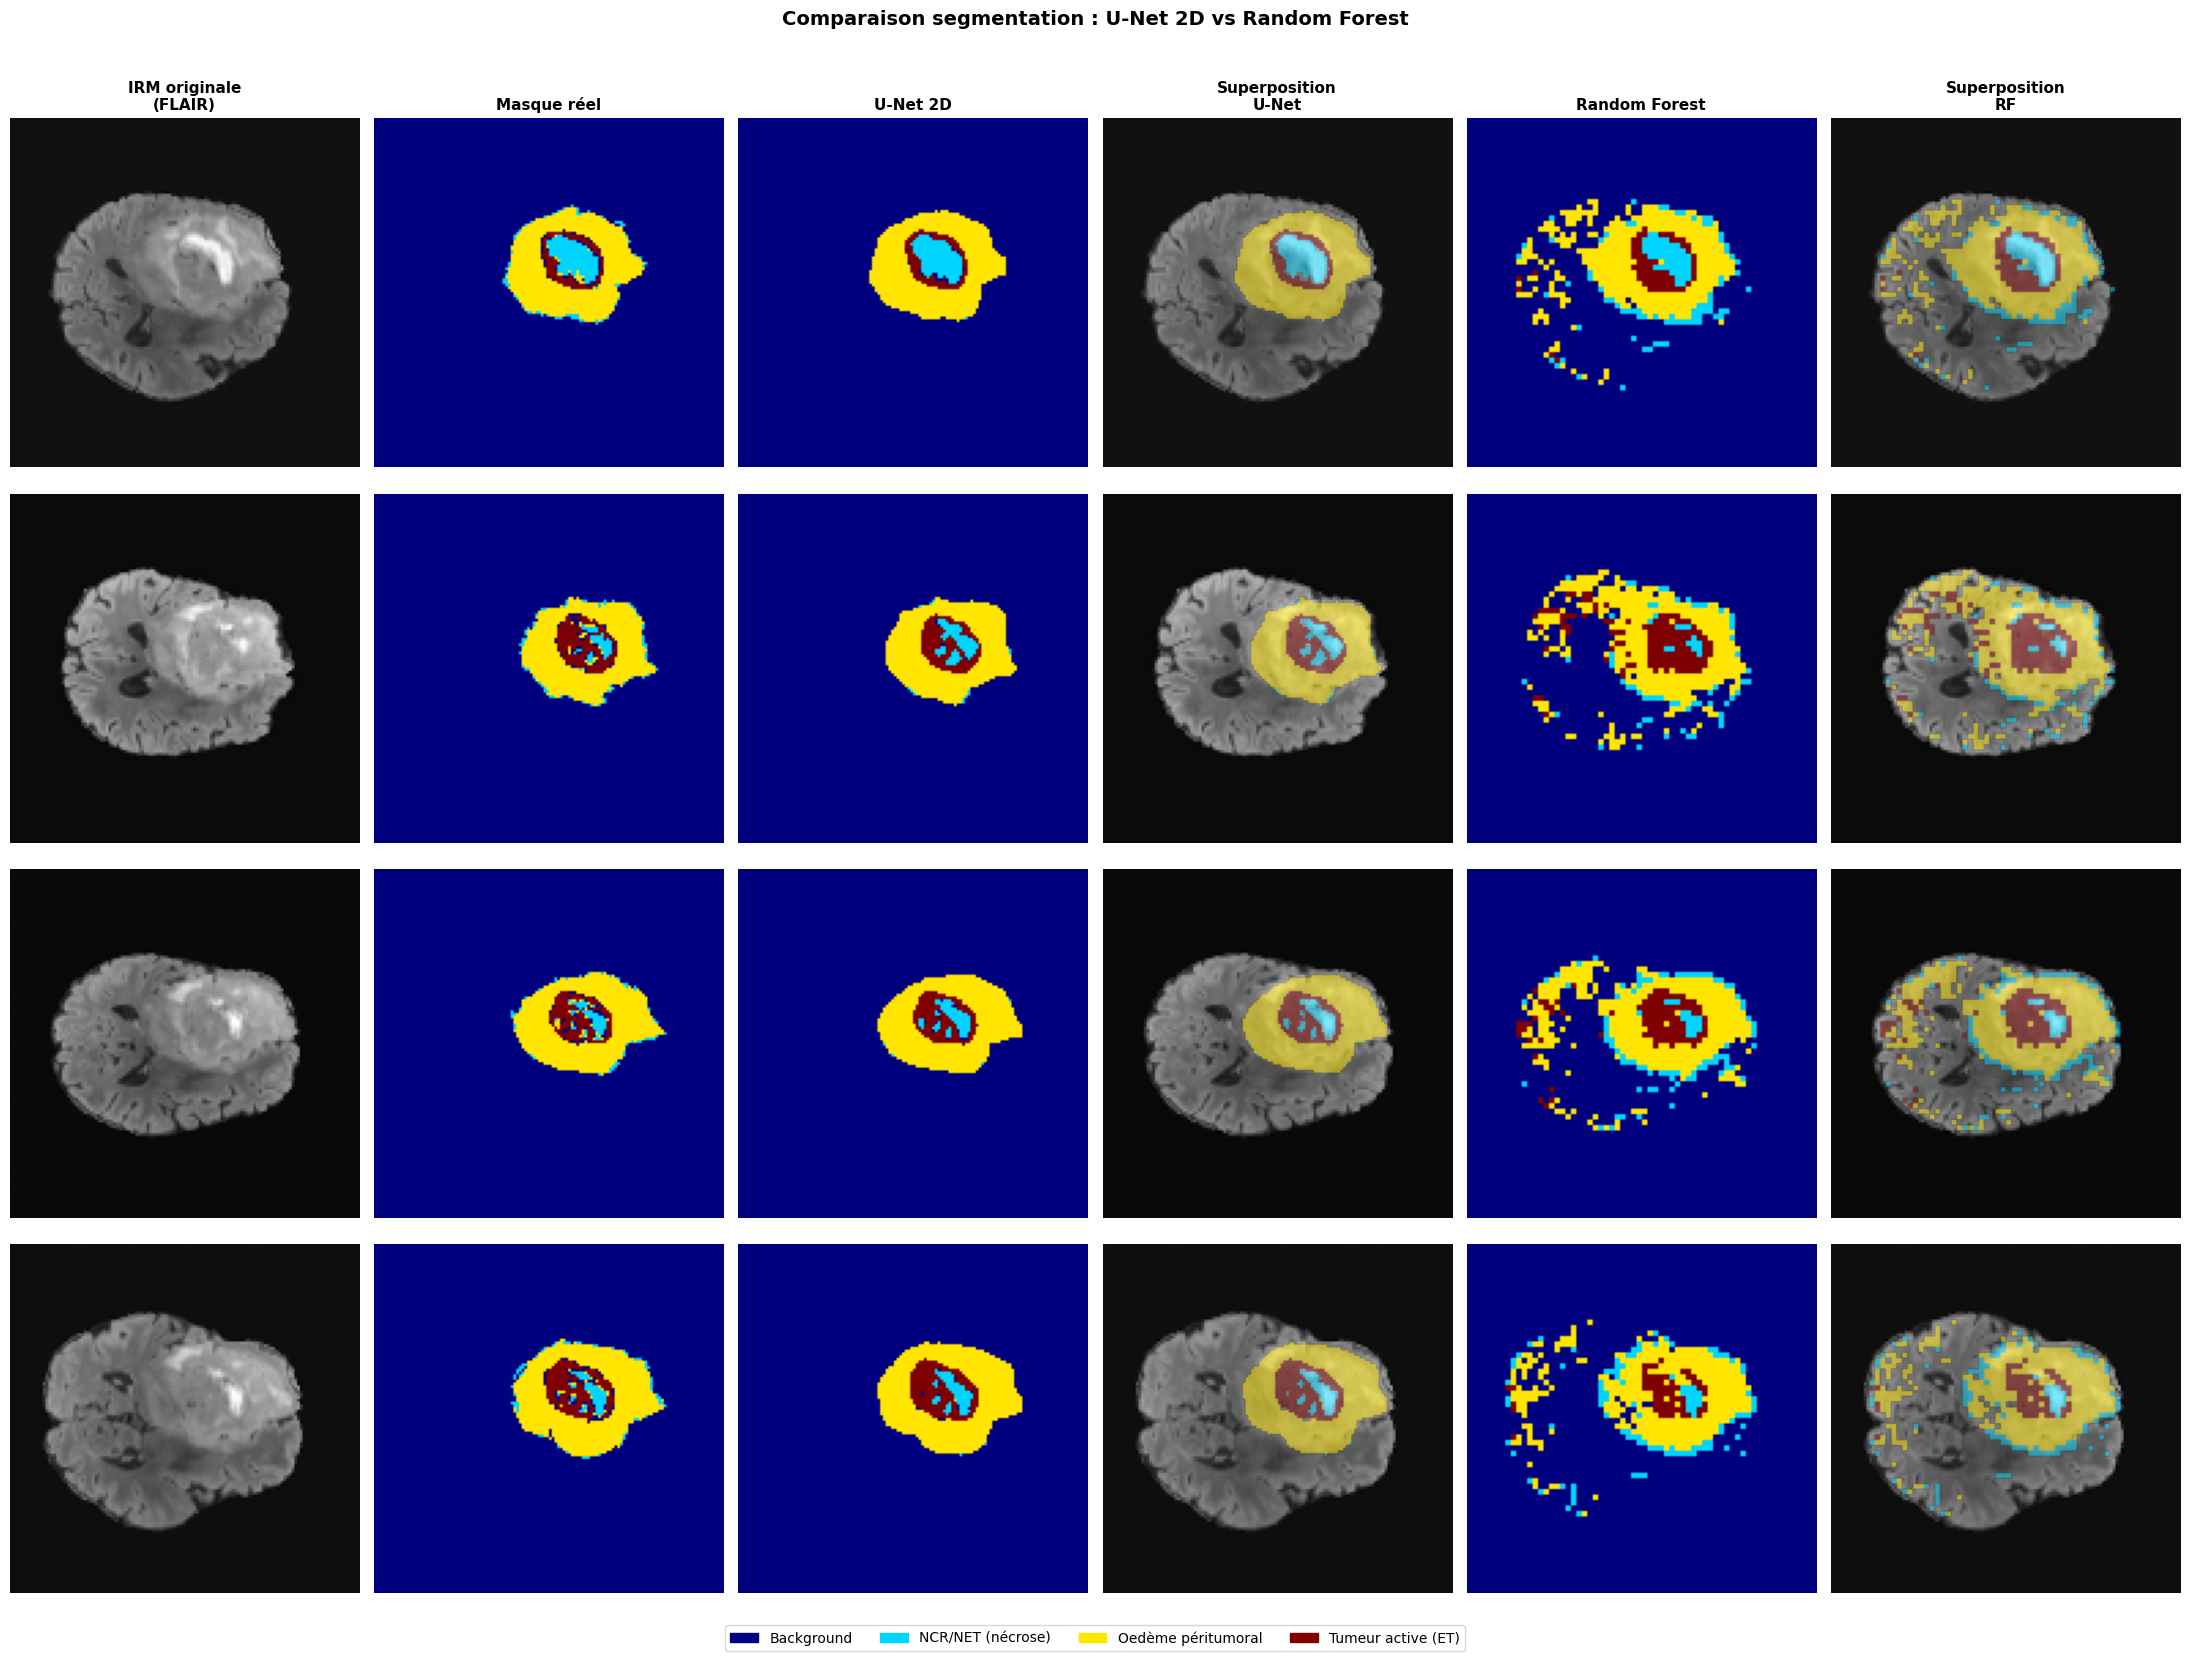

Figure sauvegardée


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

SAVE_DIR = '/content/drive/MyDrive/Resultats_Cartographie'
os.makedirs(SAVE_DIR, exist_ok=True)

cmap_seg = plt.cm.get_cmap('jet', 4)

def predict_unet(img_batch):
    pred = model.predict(img_batch, verbose=0)
    return np.argmax(pred, axis=-1)

def predict_rf_on_batch(img_batch, img_size_rf=64):
    preds = []
    for img in img_batch:
        channels = []
        for c in range(4):
            slc = cv2.resize(img[:,:,c], (img_size_rf, img_size_rf))
            channels.append(slc)
            gx = cv2.Sobel(slc.astype(np.float32), cv2.CV_64F, 1, 0)
            gy = cv2.Sobel(slc.astype(np.float32), cv2.CV_64F, 0, 1)
            channels.append(np.sqrt(gx**2+gy**2))
        feat = np.stack(channels, axis=-1).reshape(-1, 8)
        pred_small = rf.predict(feat).reshape(img_size_rf, img_size_rf)
        pred_full  = cv2.resize(pred_small.astype(np.float32),
                                (IMG_SIZE, IMG_SIZE),
                                interpolation=cv2.INTER_NEAREST).astype(np.uint8)
        preds.append(pred_full)
    return np.array(preds)

# ── Prendre 4 patients test différents ───────────────────────────────────────
n_show = 4
imgs_batch, masks_batch = [], []
for i in range(min(n_show, len(test_gen))):
    ib, mb = test_gen[i]
    imgs_batch.append(ib[0])
    masks_batch.append(mb[0])

imgs_batch  = np.array(imgs_batch)
masks_batch = np.array(masks_batch)

preds_unet  = predict_unet(imgs_batch)
preds_rf    = predict_rf_on_batch(imgs_batch)

# ── Figure comparative ────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_show, 6, figsize=(22, 4*n_show))
fig.suptitle("Comparaison segmentation : U-Net 2D vs Random Forest",
             fontsize=14, fontweight='bold', y=1.01)

col_titles = ["IRM originale\n(FLAIR)", "Masque réel",
              "U-Net 2D", "Superposition\nU-Net",
              "Random Forest", "Superposition\nRF"]

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold')

for i in range(n_show):
    flair = imgs_batch[i, :, :, 0]   # canal FLAIR pour affichage

    # Col 0 : IRM FLAIR
    axes[i,0].imshow(flair, cmap='gray')

    # Col 1 : Masque réel
    axes[i,1].imshow(masks_batch[i], cmap=cmap_seg, vmin=0, vmax=3)

    # Col 2 : Prédiction U-Net
    axes[i,2].imshow(preds_unet[i], cmap=cmap_seg, vmin=0, vmax=3)

    # Col 3 : Superposition U-Net
    axes[i,3].imshow(flair, cmap='gray')
    axes[i,3].imshow(np.ma.masked_where(preds_unet[i]==0, preds_unet[i]),
                     cmap=cmap_seg, alpha=0.5, vmin=0, vmax=3)

    # Col 4 : Prédiction RF
    axes[i,4].imshow(preds_rf[i], cmap=cmap_seg, vmin=0, vmax=3)

    # Col 5 : Superposition RF
    axes[i,5].imshow(flair, cmap='gray')
    axes[i,5].imshow(np.ma.masked_where(preds_rf[i]==0, preds_rf[i]),
                     cmap=cmap_seg, alpha=0.5, vmin=0, vmax=3)

    for ax in axes[i]: ax.axis('off')

# Légende
patches = [
    mpatches.Patch(color=cmap_seg(0), label='Background'),
    mpatches.Patch(color=cmap_seg(1), label='NCR/NET (nécrose)'),
    mpatches.Patch(color=cmap_seg(2), label='Oedème péritumoral'),
    mpatches.Patch(color=cmap_seg(3), label='Tumeur active (ET)'),
]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparaison_unet_rf.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure sauvegardée")


===== TABLEAU COMPARATIF =====
       Classe  Dice U-Net  Dice RF  Δ (UNet−RF)
   Background      0.9954   0.9678       0.0276
      NCR/NET      0.6917   0.3673       0.3244
       Oedème      0.9503   0.7024       0.2479
Tumeur active      0.8723   0.5859       0.2864


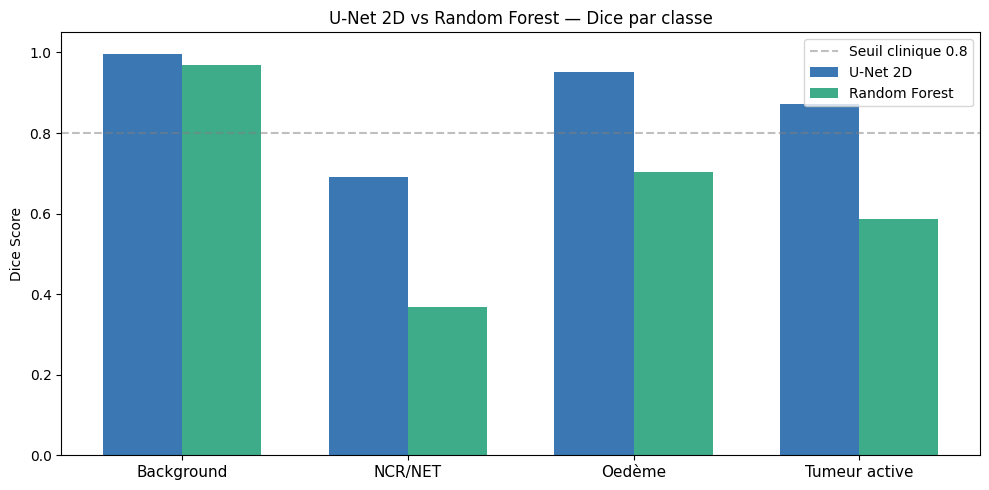

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def dice_per_class(y_true_flat, y_pred_flat, num_classes=4):
    scores = []
    for c in range(num_classes):
        yt = (y_true_flat == c)
        yp = (y_pred_flat == c)
        inter = (yt & yp).sum()
        denom = yt.sum() + yp.sum()
        scores.append(round(2*inter/(denom+1e-6), 4) if denom > 0 else 1.0)
    return scores

# Collecter prédictions U-Net sur test
y_true_all, y_unet_all, y_rf_all = [], [], []
for i in range(len(test_gen)):
    ib, mb = test_gen[i]
    pred_u = np.argmax(model.predict(ib, verbose=0), axis=-1)
    pred_r = predict_rf_on_batch(ib)
    y_true_all.append(mb.flatten())
    y_unet_all.append(pred_u.flatten())
    y_rf_all.append(pred_r.flatten())

y_true = np.concatenate(y_true_all)
y_unet = np.concatenate(y_unet_all)
y_rf   = np.concatenate(y_rf_all)

dice_unet = dice_per_class(y_true, y_unet)
dice_rf   = dice_per_class(y_true, y_rf)

class_names = ['Background', 'NCR/NET', 'Oedème', 'Tumeur active']

df_compare = pd.DataFrame({
    'Classe'       : class_names,
    'Dice U-Net'   : dice_unet,
    'Dice RF'      : dice_rf,
    'Δ (UNet−RF)'  : [round(u-r, 4) for u,r in zip(dice_unet, dice_rf)]
})
print("\n===== TABLEAU COMPARATIF =====")
print(df_compare.to_string(index=False))
df_compare.to_csv(f'{SAVE_DIR}/comparaison.csv', index=False)

# Graphique pour le rapport
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(class_names))
w = 0.35
ax.bar(x - w/2, dice_unet, w, label='U-Net 2D',      color='#185FA5', alpha=0.85)
ax.bar(x + w/2, dice_rf,   w, label='Random Forest', color='#1D9E75', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel('Dice Score')
ax.set_title('U-Net 2D vs Random Forest — Dice par classe')
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Seuil clinique 0.8')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparaison_graphique.png', dpi=200)
plt.show()

T1 shape : (240, 240, 155) | spacing : (1.0, 1.0, 1.0)
SEG shape: (240, 240, 155)
Atlas shape: (182, 218, 182)
N4 terminé
Recalage terminé | T1 recalé : (182, 218, 182)
Labels masque recalé : [-1  0  1  2  3  4  5]
Fichiers sauvegardés


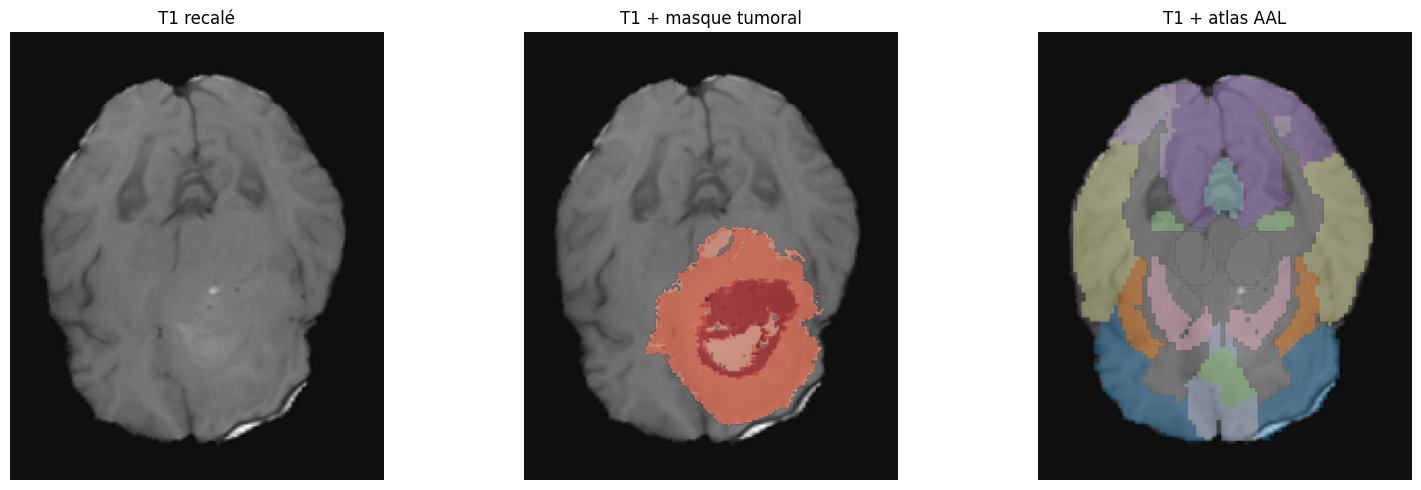

In [ ]:
!pip install matplotlib-venn
# !apt-get -qq install -y libfluidsynth1
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive
!apt-get -qq install -y graphviz && pip install pydot
import pydot
!pip install cartopy
import cartopy
!pip install antspyx
import ants
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# ── Chemins ─────────────────────────────────────────────────────────────────
T1_PATH   = '/content/drive/MyDrive/Brats2021_0002_0155_t1.nii.gz'
SEG_PATH  = '/content/drive/MyDrive/Brats2021_0002_0155_seg.nii.gz'
ATLAS_PATH= '/content/drive/MyDrive/ROI_MNI_V4.nii'

# ── 1. Chargement + orientation RAS (OBLIGATOIRE avant tout recalage) ────────
t1    = ants.image_read(T1_PATH)
seg   = ants.image_read(SEG_PATH)
atlas = ants.image_read(ATLAS_PATH)

t1    = ants.reorient_image2(t1,    orientation='RAS')
seg   = ants.reorient_image2(seg,   orientation='RAS')
atlas = ants.reorient_image2(atlas, orientation='RAS')

# ── 2. Resample isotrope 1×1×1 mm ───────────────────────────────────────────
t1    = ants.resample_image(t1,    (1,1,1), use_voxels=False, interp_type=4)  # BSpline pour IRM
seg   = ants.resample_image(seg,   (1,1,1), use_voxels=False, interp_type=1)  # NN pour labels
atlas = ants.resample_image(atlas, (1,1,1), use_voxels=False, interp_type=1)  # NN pour atlas

print("T1 shape :", t1.shape, "| spacing :", t1.spacing)
print("SEG shape:", seg.shape)
print("Atlas shape:", atlas.shape)

# ── 3. Correction N4 (biais de champ magnétique) ────────────────────────────
t1_n4 = ants.n4_bias_field_correction(t1)
print("N4 terminé")

# ── 4. Recalage T1 → atlas AAL (UNE SEULE fois, SyN) ─────────────────────────
# L'atlas est la référence fixe ; l'IRM BraTS est le mobile
reg = ants.registration(
    fixed   = atlas,
    moving  = t1_n4,
    type_of_transform = 'SyN',
    verbose = False
)
t1_reg = reg['warpedmovout']
print("Recalage terminé | T1 recalé :", t1_reg.shape)

# ── 5. Application de la MÊME transformation au masque (interpolation NN) ───
#    CRITIQUE : ne jamais utiliser l'interpolation linéaire sur un masque
seg_reg = ants.apply_transforms(
    fixed         = atlas,
    moving         = seg,
    transformlist = reg['fwdtransforms'],
    interpolator  = 'nearestNeighbor'
)

# ── 6. Vérification labels ───────────────────────────────────────────────────
labels_seg = np.unique(seg_reg.numpy().astype(int))
print("Labels masque recalé :", labels_seg)
# Doit afficher [0 1 2 4]  — sinon il y a un problème d'interpolation

# ── 7. Sauvegarde ────────────────────────────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/Resultats_Cartographie'
import os
os.makedirs(SAVE_DIR, exist_ok=True)

ants.image_write(t1_reg,  f'{SAVE_DIR}/t1_registered_atlas.nii.gz')
ants.image_write(seg_reg, f'{SAVE_DIR}/seg_registered_atlas.nii.gz')
ants.image_write(atlas,   f'{SAVE_DIR}/atlas_RAS_1mm.nii.gz')
print("Fichiers sauvegardés")

# ── 8. Vérification visuelle ─────────────────────────────────────────────────
t1_np  = t1_reg.numpy()
seg_np = seg_reg.numpy().astype(int)
atl_np = atlas.numpy().astype(int)
spacing = np.array(t1_reg.spacing)

# Coupe avec le plus de tumeur
z = int(np.argmax([seg_np[:,:,i].sum() for i in range(seg_np.shape[2])]))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(t1_np[:,:,z].T,  cmap='gray', origin='lower')
axes[0].set_title("T1 recalé")

axes[1].imshow(t1_np[:,:,z].T,  cmap='gray', origin='lower')
axes[1].imshow(np.ma.masked_where(seg_np[:,:,z].T==0, seg_np[:,:,z].T),
               cmap='Reds', alpha=0.6, origin='lower')
axes[1].set_title("T1 + masque tumoral")

axes[2].imshow(t1_np[:,:,z].T,  cmap='gray', origin='lower')
axes[2].imshow(np.ma.masked_where(atl_np[:,:,z].T==0, atl_np[:,:,z].T),
               cmap='tab20', alpha=0.4, origin='lower')
axes[2].set_title("T1 + atlas AAL")

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/verification_recalage.png', dpi=150)
plt.show()

In [ ]:
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import distance_transform_edt
import json, os

SAVE_DIR = '/content/drive/MyDrive/Resultats_Cartographie'

# ── Chargement ───────────────────────────────────────────────────────────────
t1_np   = ants.image_read(f'{SAVE_DIR}/t1_registered_atlas.nii.gz').numpy()
seg_np  = nib.load(f'{SAVE_DIR}/seg_registered_atlas.nii.gz').get_fdata().astype(int)
atl_np  = nib.load(f'{SAVE_DIR}/atlas_RAS_1mm.nii.gz').get_fdata().astype(int)
spacing = np.array(ants.image_read(f'{SAVE_DIR}/t1_registered_atlas.nii.gz').spacing)

assert t1_np.shape == seg_np.shape == atl_np.shape, \
    f"Shapes incohérents : {t1_np.shape} vs {seg_np.shape} vs {atl_np.shape}"
print(f"✓ Shapes : {t1_np.shape} | Spacing : {spacing} mm")

# ── Remap labels ─────────────────────────────────────────────────────────────
seg_remap = np.zeros_like(seg_np, dtype=np.uint8)
seg_remap[seg_np == 1] = 1
seg_remap[seg_np == 2] = 2
seg_remap[seg_np == 4] = 3
print("Labels après remap :", np.unique(seg_remap))

# ── Labels AAL ───────────────────────────────────────────────────────────────
aal_labels = {}
with open('/content/drive/MyDrive/ROI_MNI_V4.txt', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 3:
            aal_labels[int(parts[2])] = parts[1]

def get_hemisphere(name):
    if name.endswith("_L"): return "Gauche"
    if name.endswith("_R"): return "Droit"
    return "Médian"

functions = {
    "Precentral":"Motricité volontaire","Frontal_Sup":"Fonctions exécutives",
    "Frontal_Mid":"Mémoire de travail","Frontal_Inf":"Langage (Broca si gauche)",
    "Rolandic_Oper":"Motricité orofaciale","Supp_Motor_Area":"Programmation motrice",
    "Insula":"Intéroception, douleur","Cingulum_Ant":"Contrôle cognitif",
    "Cingulum_Mid":"Attention","Cingulum_Post":"Mémoire par défaut",
    "Hippocampus":"Mémoire épisodique","Amygdala":"Peur, émotions",
    "Calcarine":"Vision primaire","Occipital":"Traitement visuel",
    "Postcentral":"Sensibilité primaire","Parietal_Sup":"Intégration spatiale",
    "Parietal_Inf":"Praxies","SupraMarginal":"Phonologie",
    "Angular":"Lecture, calcul","Precuneus":"Conscience, mémoire",
    "Caudate":"Apprentissage procédural","Putamen":"Contrôle moteur",
    "Thalamus":"Relais sensoriel","Temporal_Sup":"Audition, Wernicke si gauche",
    "Temporal_Mid":"Mémoire sémantique","Temporal_Inf":"Reconnaissance visuelle",
    "Cerebelum":"Coordination motrice","Pallidum":"Régulation motrice",
    "Paracentral_Lobule":"Sensori-moteur MI",
}
def get_function(name):
    for k, v in functions.items():
        if k.lower() in name.lower(): return v
    return "Non répertoriée"

# ── CORRECTION 1 : volume correct ────────────────────────────────────────────
# spacing est en mm → voxel_vol en mm³
voxel_vol_mm3 = float(spacing[0]) * float(spacing[1]) * float(spacing[2])
print(f"\nVolume d'un voxel : {voxel_vol_mm3:.4f} mm³")
# Pour spacing (1,1,1) → 1 mm³ → 1 cm³ = 1000 voxels

tumor_mask = (seg_remap > 0)
total_vox  = int(tumor_mask.sum())
vol_total_mm3 = total_vox * voxel_vol_mm3
vol_total_cm3 = vol_total_mm3 / 1000.0

print(f"Voxels tumoraux : {total_vox}")
print(f"Volume total    : {vol_total_cm3:.2f} cm³  ← doit être entre 20 et 150 cm³ pour un GBM")

# Vérification sanité
if vol_total_cm3 > 200:
    print("⚠️  Volume anormalement grand — vérifier le spacing ou le masque")
elif vol_total_cm3 < 1:
    print("⚠️  Volume anormalement petit — vérifier le remap des labels")
else:
    print("✓ Volume biologiquement plausible")

# Bounding box
coords = np.argwhere(tumor_mask)
bb_min, bb_max = coords.min(0), coords.max(0)
dim_vox = bb_max - bb_min
dim_mm  = dim_vox * spacing
centroid_vox = coords.mean(0)

print(f"\nBounding box (voxels) : {dim_vox}")
print(f"Bounding box (mm)     : X={dim_mm[0]:.1f}  Y={dim_mm[1]:.1f}  Z={dim_mm[2]:.1f}")
print(f"Centre de masse (vox) : {centroid_vox.astype(int)}")

# Sous-composantes
print("\nComposition tumorale :")
for lbl, name in [(1,"Nécrose/NCR"),(2,"Œdème/ED"),(3,"Tumeur active/ET")]:
    n_vox = int((seg_remap == lbl).sum())
    v_cm3 = n_vox * voxel_vol_mm3 / 1000.0
    pct   = 100.0 * n_vox / total_vox if total_vox > 0 else 0
    print(f"  {name:25s}: {n_vox:8d} voxels | {v_cm3:6.2f} cm³ | {pct:5.1f}%")

# ── CORRECTION 2 : hémisphère correct dans l'espace MNI ─────────────────────
# Dans l'espace MNI RAS :
#   - axe X croissant = vers la DROITE du patient
#   - milieu du volume ≈ x=91 pour un atlas 182 voxels à 1mm
# MAIS : dans l'atlas AAL, les régions _R correspondent au côté GAUCHE de l'image
# (convention radiologique). Il faut vérifier empiriquement avec les labels AAL.

# Méthode fiable : compter l'overlap avec les régions _L et _R de l'atlas
vox_atlas_L = (atl_np % 2 == 1)   # labels impairs = gauche dans AAL
vox_atlas_R = (atl_np % 2 == 0) & (atl_np > 0)  # labels pairs = droit dans AAL

# Vérification avec un label connu : Thalamus_L doit avoir un label impair
thal_L_ids = [lid for lid, n in aal_labels.items() if n == "Thalamus_L"]
thal_R_ids = [lid for lid, n in aal_labels.items() if n == "Thalamus_R"]
print(f"\nVérification convention AAL :")
print(f"  Thalamus_L IDs : {thal_L_ids}")
print(f"  Thalamus_R IDs : {thal_R_ids}")

# Overlap tumeur avec les côtés AAL (méthode fiable)
tumor_in_L_regions = np.logical_and(
    tumor_mask,
    np.isin(atl_np, [lid for lid, n in aal_labels.items() if n.endswith("_L")])
).sum()
tumor_in_R_regions = np.logical_and(
    tumor_mask,
    np.isin(atl_np, [lid for lid, n in aal_labels.items() if n.endswith("_R")])
).sum()
tumor_in_atlas = tumor_in_L_regions + tumor_in_R_regions

pct_L = 100.0 * tumor_in_L_regions / tumor_in_atlas if tumor_in_atlas > 0 else 0
pct_R = 100.0 * tumor_in_R_regions / tumor_in_atlas if tumor_in_atlas > 0 else 0
hemisphere_dominant = "Gauche" if tumor_in_L_regions > tumor_in_R_regions else "Droit"

print(f"\nLocalisation hémisphérique (basée sur labels AAL) :")
print(f"  Régions gauches (_L) : {tumor_in_L_regions} voxels ({pct_L:.1f}%)")
print(f"  Régions droites (_R) : {tumor_in_R_regions} voxels ({pct_R:.1f}%)")
print(f"  Hémisphère dominant  : {hemisphere_dominant}")

# ── CORRECTION 3 : pct_cerveau_atteint correct ───────────────────────────────
total_brain_vox = int((atl_np > 0).sum())   # total voxels dans l'atlas
tumor_in_brain  = int(np.logical_and(tumor_mask, atl_np > 0).sum())
# ERREUR ORIGINALE : division voxel/voxel/voxel au lieu de /total
pct_cerveau     = 100.0 * tumor_in_brain / total_brain_vox if total_brain_vox > 0 else 0
print(f"\nVolume cérébral AAL    : {total_brain_vox * voxel_vol_mm3 / 1000:.1f} cm³")
print(f"Tumeur dans atlas      : {tumor_in_brain} voxels")
print(f"% cerveau atteint      : {pct_cerveau:.2f}%  ← doit être entre 1% et 15% pour un GBM")

# ── Cartographie AAL ─────────────────────────────────────────────────────────
rows = []
for lid, lname in aal_labels.items():
    region_mask = (atl_np == lid)
    region_size = int(region_mask.sum())
    if region_size == 0:
        continue
    overlap = int(np.logical_and(tumor_mask, region_mask).sum())
    if overlap == 0:
        continue
    rows.append({
        "ID"                 : lid,
        "Région AAL"         : lname,
        "Hémisphère"         : get_hemisphere(lname),
        "Fonction"           : get_function(lname),
        "Volume overlap cm³" : round(overlap * voxel_vol_mm3 / 1000.0, 3),
        "% tumeur ici"       : round(100.0 * overlap / total_vox, 2),
        "% région atteinte"  : round(100.0 * overlap / region_size, 2),
    })

df_carto = pd.DataFrame(rows).sort_values(
    "% tumeur ici", ascending=False).reset_index(drop=True)
print(f"\n{len(df_carto)} régions atteintes sur {len(aal_labels)}")
print(df_carto.head(15).to_string(index=False))

total_regions    = len([l for l in aal_labels if (atl_np == l).sum() > 0])
regions_touchees = len(df_carto)
print(f"\nCouverture AAL totale  : {df_carto['% tumeur ici'].sum():.1f}%")
print(f"Régions > 50% atteintes: {(df_carto['% région atteinte'] > 50).sum()}")
print(f"Régions > 80% atteintes: {(df_carto['% région atteinte'] > 80).sum()}")

# ── Distances critiques ───────────────────────────────────────────────────────
critical_regions = {
    "Motricité gauche (Precentral_L)"  : "Precentral_L",
    "Motricité droite (Precentral_R)"  : "Precentral_R",
    "Broca gauche (Frontal_Inf_Tri_L)" : "Frontal_Inf_Tri_L",
    "Wernicke gauche (Temporal_Sup_L)" : "Temporal_Sup_L",
    "Hippocampe gauche"                : "Hippocampus_L",
    "Hippocampe droit"                 : "Hippocampus_R",
    "Thalamus gauche"                  : "Thalamus_L",
    "Thalamus droit"                   : "Thalamus_R",
}

dist_rows = []
print(f"\n{'='*55}")
print("DISTANCES TUMEUR → RÉGIONS CRITIQUES")
print(f"{'='*55}")
for label_display, region_name in critical_regions.items():
    labels_matching = [lid for lid, n in aal_labels.items() if n == region_name]
    if not labels_matching:
        print(f"  ⚠ {region_name} non trouvé dans l'atlas")
        continue
    lid = labels_matching[0]
    region_mask = (atl_np == lid)
    if region_mask.sum() == 0:
        continue
    if np.logical_and(tumor_mask, region_mask).sum() > 0:
        dist_mm, status = 0.0, "ENVAHIE"
    else:
        dt      = distance_transform_edt(~tumor_mask, sampling=tuple(spacing))
        dist_mm = round(float(dt[region_mask].min()), 1)
        status  = "ADJACENTE" if dist_mm < 5 else "DISTANTE"
    dist_rows.append({
        "Région critique" : label_display,
        "Distance (mm)"   : dist_mm,
        "Statut"          : status
    })
    icone = "🔴" if status=="ENVAHIE" else ("🟠" if status=="ADJACENTE" else "🟢")
    print(f"  {icone} {label_display:45s}: {dist_mm:6.1f} mm [{status}]")

df_dist = pd.DataFrame(dist_rows)

# ── Sauvegarde ───────────────────────────────────────────────────────────────
df_carto.to_csv(f'{SAVE_DIR}/cartographie_AAL.csv', index=False)
df_dist.to_csv(f'{SAVE_DIR}/distances_regions_critiques.csv', index=False)

rapport = {
    "volume_total_cm3"      : round(vol_total_cm3, 2),
    "voxel_vol_mm3"         : round(voxel_vol_mm3, 4),
    "total_voxels_tumoraux" : total_vox,
    "hemisphere_dominant"   : hemisphere_dominant,
    "pct_hemisphere_gauche" : round(pct_L, 1),
    "pct_hemisphere_droit"  : round(pct_R, 1),
    "nb_regions_touchees"   : regions_touchees,
    "total_regions_atlas"   : total_regions,
    "pct_cerveau_atteint"   : round(pct_cerveau, 2),
    "regions_severes_80pct" : int((df_carto['% région atteinte'] > 80).sum()),
    "couverture_AAL_pct"    : round(df_carto['% tumeur ici'].sum(), 1),
    "necrose_cm3"           : round((seg_remap==1).sum()*voxel_vol_mm3/1000, 2),
    "oedeme_cm3"            : round((seg_remap==2).sum()*voxel_vol_mm3/1000, 2),
    "tumeur_active_cm3"     : round((seg_remap==3).sum()*voxel_vol_mm3/1000, 2),
}
with open(f'{SAVE_DIR}/rapport_cartographie.json', 'w') as f:
    json.dump(rapport, f, indent=2, ensure_ascii=False)
print(f"\nFichiers sauvegardés dans {SAVE_DIR}")
print("\nRÉSUMÉ FINAL :")
for k, v in rapport.items():
    print(f"  {k:35s}: {v}")

✓ Shapes : (182, 218, 182) | Spacing : [1. 1. 1.] mm
Labels après remap : [0 1 2 3]

Volume d'un voxel : 1.0000 mm³
Voxels tumoraux : 273215
Volume total    : 273.21 cm³  ← doit être entre 20 et 150 cm³ pour un GBM
⚠️  Volume anormalement grand — vérifier le spacing ou le masque

Bounding box (voxels) : [ 86 108 101]
Bounding box (mm)     : X=86.0  Y=108.0  Z=101.0
Centre de masse (vox) : [107  76 101]

Composition tumorale :
  Nécrose/NCR              :    32791 voxels |  32.79 cm³ |  12.0%
  Œdème/ED                 :   209327 voxels | 209.33 cm³ |  76.6%
  Tumeur active/ET         :    31097 voxels |  31.10 cm³ |  11.4%

Vérification convention AAL :
  Thalamus_L IDs : [7101]
  Thalamus_R IDs : [7102]

Localisation hémisphérique (basée sur labels AAL) :
  Régions gauches (_L) : 152198 voxels (85.6%)
  Régions droites (_R) : 25590 voxels (14.4%)
  Hémisphère dominant  : Gauche

Volume cérébral AAL    : 1482.9 cm³
Tumeur dans atlas      : 177788 voxels
% cerveau atteint      : 11.99% 

In [ ]:
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import distance_transform_edt
import json, os

# ── Chargement robuste ───────────────────────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/Resultats_Cartographie'

t1_np   = ants.image_read(f'{SAVE_DIR}/t1_registered_atlas.nii.gz').numpy()
seg_np  = nib.load(f'{SAVE_DIR}/seg_registered_atlas.nii.gz').get_fdata().astype(int)
atl_np  = nib.load(f'{SAVE_DIR}/atlas_RAS_1mm.nii.gz').get_fdata().astype(int)
spacing = np.array(ants.image_read(f'{SAVE_DIR}/t1_registered_atlas.nii.gz').spacing)

# ── VÉRIFICATION CRITIQUE : shapes identiques ────────────────────────────────
assert t1_np.shape == seg_np.shape == atl_np.shape, \
    f"Shapes incohérents : T1={t1_np.shape}, SEG={seg_np.shape}, Atlas={atl_np.shape}"
print(f"✓ Shapes cohérents : {t1_np.shape}")

# Remap labels BraTS : 0→0 | 1→1 | 2→2 | 4→3
seg_remap = np.zeros_like(seg_np, dtype=np.uint8)
seg_remap[seg_np == 1] = 1
seg_remap[seg_np == 2] = 2
seg_remap[seg_np == 4] = 3   # ← était oublié dans votre code
print("Labels après remap :", np.unique(seg_remap))

# ── Chargement labels AAL ────────────────────────────────────────────────────
aal_labels = {}
with open('/content/drive/MyDrive/ROI_MNI_V4.txt', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 3:
            aal_labels[int(parts[2])] = parts[1]

def get_hemisphere(name):
    if name.endswith("_L"): return "Gauche"
    if name.endswith("_R"): return "Droit"
    return "Médian"

functions = {
    "Precentral":"Motricité volontaire","Frontal_Sup":"Fonctions exécutives",
    "Frontal_Mid":"Mémoire de travail","Frontal_Inf":"Langage (Broca si gauche)",
    "Rolandic_Oper":"Motricité orofaciale","Supp_Motor_Area":"Programmation motrice",
    "Insula":"Intéroception, douleur","Cingulum_Ant":"Contrôle cognitif",
    "Cingulum_Mid":"Attention","Cingulum_Post":"Mémoire par défaut",
    "Hippocampus":"Mémoire épisodique","Amygdala":"Peur, émotions",
    "Calcarine":"Vision primaire","Occipital":"Traitement visuel",
    "Postcentral":"Sensibilité primaire","Parietal_Sup":"Intégration spatiale",
    "Parietal_Inf":"Praxies","SupraMarginal":"Phonologie",
    "Angular":"Lecture, calcul","Precuneus":"Conscience, mémoire",
    "Caudate":"Apprentissage procédural","Putamen":"Contrôle moteur",
    "Thalamus":"Relais sensoriel","Temporal_Sup":"Audition, Wernicke si gauche",
    "Temporal_Mid":"Mémoire sémantique","Temporal_Inf":"Reconnaissance visuelle",
    "Cerebelum":"Coordination motrice","Pallidum":"Régulation motrice",
    "Paracentral_Lobule":"Sensori-moteur MI",
}
def get_function(name):
    for k, v in functions.items():
        if k.lower() in name.lower(): return v
    return "Non répertoriée"

# ── Volume et dimensions ─────────────────────────────────────────────────────
voxel_vol = spacing[0] * spacing[1] * spacing[2]
tumor_mask = (seg_remap > 0)
total_vox  = tumor_mask.sum()
vol_total  = total_vox * voxel_vol / 1000  # cm³

coords = np.argwhere(tumor_mask)
bb_min, bb_max = coords.min(0), coords.max(0)
dim_mm = (bb_max - bb_min) * spacing
centroid = coords.mean(0)

print(f"\n{'='*50}")
print(f"Volume total : {vol_total:.2f} cm³")
print(f"Bounding box : X={dim_mm[0]:.1f} Y={dim_mm[1]:.1f} Z={dim_mm[2]:.1f} mm")
for lbl, name in [(1,"Nécrose"),(2,"Œdème"),(3,"Tumeur active")]:
    v = (seg_remap==lbl).sum()*voxel_vol/1000
    p = 100*(seg_remap==lbl).sum()/total_vox
    print(f"  {name:20s}: {v:.2f} cm³ ({p:.1f}%)")

# ── Hémisphère ───────────────────────────────────────────────────────────────
mid_x   = t1_np.shape[0]//2
x_idx   = np.arange(tumor_mask.shape[0])[:,None,None]
vox_G   = (tumor_mask & (x_idx < mid_x)).sum()
vox_D   = (tumor_mask & (x_idx >= mid_x)).sum()
pct_G   = 100*vox_G/total_vox
pct_D   = 100*vox_D/total_vox
hemisphere_dominant = "Gauche" if vox_G > vox_D else "Droit"
print(f"\nHémisphère dominant : {hemisphere_dominant} ({max(pct_G,pct_D):.1f}%)")

# ── Cartographie AAL ─────────────────────────────────────────────────────────
rows = []
for lid, lname in aal_labels.items():
    region_mask = (atl_np == lid)
    region_size = region_mask.sum()
    if region_size == 0: continue
    overlap = np.logical_and(tumor_mask, region_mask).sum()
    if overlap == 0: continue
    rows.append({
        "ID"                   : lid,
        "Région AAL"           : lname,
        "Hémisphère"           : get_hemisphere(lname),
        "Fonction"             : get_function(lname),
        "Volume overlap cm³"   : round(overlap * voxel_vol / 1000, 3),
        "% tumeur ici"         : round(100 * overlap / total_vox, 2),
        "% région atteinte"    : round(100 * overlap / region_size, 2),
    })

df_carto = pd.DataFrame(rows).sort_values("% tumeur ici", ascending=False).reset_index(drop=True)
print(f"\n{len(df_carto)} régions atteintes")
print(df_carto.head(15).to_string(index=False))

# ── Distances critiques (distance_transform_edt — RAPIDE et précis) ──────────
critical_regions = {
    "Motricité gauche (Precentral_L)"  : "Precentral_L",
    "Motricité droite (Precentral_R)"  : "Precentral_R",
    "Broca gauche (Frontal_Inf_Tri_L)" : "Frontal_Inf_Tri_L",
    "Wernicke gauche (Temporal_Sup_L)" : "Temporal_Sup_L",
    "Hippocampe gauche"                : "Hippocampus_L",
    "Hippocampe droit"                 : "Hippocampus_R",
    "Thalamus gauche"                  : "Thalamus_L",
    "Thalamus droit"                   : "Thalamus_R",
}

dist_rows = []
print(f"\n{'='*50}")
print("DISTANCES TUMEUR → RÉGIONS CRITIQUES")
print(f"{'='*50}")
for label_display, region_name in critical_regions.items():
    labels_matching = [lid for lid, n in aal_labels.items() if n == region_name]
    if not labels_matching: continue
    lid = labels_matching[0]
    region_mask = (atl_np == lid)
    if region_mask.sum() == 0: continue

    # Si chevauchement → distance = 0
    if np.logical_and(tumor_mask, region_mask).sum() > 0:
        dist_mm, status = 0.0, "ENVAHIE"
    else:
        # distance_transform_edt donne la distance exacte au plus proche voxel non-zéro
        # On calcule la distance depuis la surface de la région vers la tumeur
        dt = distance_transform_edt(~tumor_mask, sampling=spacing)
        dist_mm = round(float(dt[region_mask].min()), 1)
        status  = "ADJACENTE" if dist_mm < 5 else "DISTANTE"

    dist_rows.append({"Région critique": label_display,
                      "Distance (mm)": dist_mm, "Statut": status})
    print(f"  {label_display:45s}: {dist_mm:6.1f} mm [{status}]")

df_dist = pd.DataFrame(dist_rows)

# ── Sauvegarde ───────────────────────────────────────────────────────────────
df_carto.to_csv(f'{SAVE_DIR}/cartographie_AAL.csv', index=False)
df_dist.to_csv(f'{SAVE_DIR}/distances_regions_critiques.csv', index=False)

rapport = {
    "volume_total_cm3"       : round(vol_total, 2),
    "hemisphere_dominant"    : hemisphere_dominant,
    "pct_hemisphere_gauche"  : round(pct_G, 1),
    "pct_hemisphere_droit"   : round(pct_D, 1),
    "nb_regions_touchees"    : len(df_carto),
    "pct_cerveau_atteint"    : round(100*(atl_np>0).sum()/atl_np.shape[0]/atl_np.shape[1]/atl_np.shape[2], 2),
    "regions_severes_80pct"  : int((df_carto['% région atteinte']>80).sum()),
    "couverture_AAL_pct"     : round(df_carto['% tumeur ici'].sum(), 1),
    "necrose_cm3"            : round((seg_remap==1).sum()*voxel_vol/1000, 2),
    "oedeme_cm3"             : round((seg_remap==2).sum()*voxel_vol/1000, 2),
    "tumeur_active_cm3"      : round((seg_remap==3).sum()*voxel_vol/1000, 2),
}
with open(f'{SAVE_DIR}/rapport_cartographie.json','w') as f:
    json.dump(rapport, f, indent=2, ensure_ascii=False)
print(f"\nFichiers sauvegardés dans {SAVE_DIR}")

✓ Shapes cohérents : (182, 218, 182)
Labels après remap : [0 1 2 3]

Volume total : 273.21 cm³
Bounding box : X=86.0 Y=108.0 Z=101.0 mm
  Nécrose             : 32.79 cm³ (12.0%)
  Œdème               : 209.33 cm³ (76.6%)
  Tumeur active       : 31.10 cm³ (11.4%)

Hémisphère dominant : Droit (80.4%)

49 régions atteintes
  ID          Région AAL Hémisphère                  Fonction  Volume overlap cm³  % tumeur ici  % région atteinte
3001            Insula_L     Gauche    Intéroception, douleur              13.618          4.98              91.62
2201       Frontal_Mid_L     Gauche        Mémoire de travail              11.778          4.31              30.27
2311   Frontal_Inf_Tri_L     Gauche Langage (Broca si gauche)              10.337          3.78              51.09
4001      Cingulum_Ant_L     Gauche         Contrôle cognitif               9.909          3.63              85.72
2321   Frontal_Inf_Orb_L     Gauche Langage (Broca si gauche)               9.721          3.56        

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf
import tensorflow.keras.backend as K
import os
import cv2 # Added for predict_rf_on_batch
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

SAVE_DIR    = '/content/drive/MyDrive/Resultats_Cartographie'
class_names = ['Background', 'NCR/NET', 'Œdème', 'Tumeur active']
NUM_CLASSES = 4

# Define custom loss functions, as they are needed to load the model
def dice_loss(y_true, y_pred, num_classes=4, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), num_classes)
    loss = 0.0
    for c in range(num_classes):
        yt = y_true_oh[..., c]
        yp = y_pred[..., c]
        intersection = K.sum(yt * yp, axis=[1, 2])
        denom = K.sum(yt + yp, axis=[1, 2])
        loss += 1.0 - (2.0 * intersection + smooth) / (denom + smooth)
    return loss / num_classes

def combined_loss(y_true, y_pred):
    ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    ce = tf.reduce_mean(ce, axis=[1, 2])
    return ce + dice_loss(y_true, y_pred)

# Load the model
MODEL_PATH = '/content/drive/MyDrive/best_unet.keras'
print("Chargement du modèle U-Net...")
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={'combined_loss': combined_loss, 'dice_loss': dice_loss}
)
print("✓ Modèle chargé")

# --- Random Forest Definition (Moved from pR4d59Eug1kB) ---
def extract_rf_features(patient_dirs, img_size=64, slices_per_patient=5):
    """
    Features par pixel : 4 modalités + gradient magnitude + local mean.
    Taille réduite à 64 pour que RF soit faisable en RAM.
    """
    X_list, y_list = [], []
    for pdir in patient_dirs:
        seg_files = [f for f in os.listdir(pdir) if f.endswith('_seg.nii.gz')]
        if not seg_files: continue
        seg_vol = nib.load(os.path.join(pdir, seg_files[0])).get_fdata()
        scores  = [(seg_vol[:,:,z]>0).sum() for z in range(seg_vol.shape[2])]
        ranked  = sorted(range(seg_vol.shape[2]),
                         key=lambda z: scores[z], reverse=True)
        best    = [z for z in ranked if scores[z]>50][:slices_per_patient]

        for z in best:
            channels = []
            for mod in ['flair','t1','t1ce','t2']:
                files = [f for f in os.listdir(pdir)
                         if f.endswith(f'_{mod}.nii.gz')]
                if not files: break
                vol = nib.load(os.path.join(pdir, files[0])).get_fdata()
                slc = cv2.resize(vol[:,:,z], (img_size, img_size))
                m, s = slc.mean(), slc.std()+1e-6
                slc  = (slc - m) / s
                channels.append(slc)
                # Gradient comme feature supplémentaire
                gx   = cv2.Sobel(slc.astype(np.float32), cv2.CV_64F, 1, 0)
                gy   = cv2.Sobel(slc.astype(np.float32), cv2.CV_64F, 0, 1)
                channels.append(np.sqrt(gx**2 + gy**2))
            if len(channels) != 8: continue
            feat_map = np.stack(channels, axis=-1)  # (64,64,8)
            X_list.append(feat_map.reshape(-1, 8))

            seg_slc = cv2.resize(seg_vol[:,:,z], (img_size, img_size),
                                 interpolation=cv2.INTER_NEAREST)
            seg_slc = np.round(seg_slc).astype(np.uint8)
            msk = np.zeros_like(seg_slc, dtype=np.uint8)
            msk[seg_slc==1]=1; msk[seg_slc==2]=2; msk[seg_slc==4]=3
            y_list.append(msk.reshape(-1))

    return np.vstack(X_list), np.concatenate(y_list)


print("Extraction des features pour Random Forest...")
X_train_rf, y_train_rf = extract_rf_features(train_dirs, img_size=64)
X_test_rf,  y_test_rf  = extract_rf_features(test_dirs,  img_size=64)
print(f"Train RF : {X_train_rf.shape} | Test RF : {X_test_rf.shape}")

# Entraînement RF (sous-échantillonnage car trop de pixels background)
idx_tumor = np.where(y_train_rf > 0)[0]
idx_bg    = np.where(y_train_rf == 0)[0]
idx_bg_s  = resample(idx_bg, n_samples=len(idx_tumor)*2, random_state=42)
idx_bal   = np.concatenate([idx_tumor, idx_bg_s])
np.random.shuffle(idx_bal)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=15,
    n_jobs=-1, random_state=42, class_weight='balanced'
)
rf.fit(X_train_rf[idx_bal], y_train_rf[idx_bal])
print("Random Forest entraîné")
# --- End Random Forest Definition ---


# Moved from cell W-HLDYApg4QF to ensure it's defined
def predict_rf_on_batch(img_batch, img_size_rf=64):
    preds = []
    # IMG_SIZE is defined in cell qHyj2KBkgix_ which was already executed
    global IMG_SIZE
    for img in img_batch:
        channels = []
        for c in range(4):
            slc = cv2.resize(img[:,:,c], (img_size_rf, img_size_rf))
            channels.append(slc)
            gx = cv2.Sobel(slc.astype(np.float32), cv2.CV_64F, 1, 0)
            gy = cv2.Sobel(slc.astype(np.float32), cv2.CV_64F, 0, 1)
            channels.append(np.sqrt(gx**2+gy**2))
        feat = np.stack(channels, axis=-1).reshape(-1, 8)
        # rf is defined in this cell now
        pred_small = rf.predict(feat).reshape(img_size_rf, img_size_rf)
        pred_full  = cv2.resize(pred_small.astype(np.float32),
                                (IMG_SIZE, IMG_SIZE),
                                interpolation=cv2.INTER_NEAREST).astype(np.uint8)
        preds.append(pred_full)
    return np.array(preds)

# ── Collecte prédictions ──────────────────────────────────────────────────────
print("Collecte des prédictions...")
y_true_all, y_unet_all, y_rf_all = [], [], []

for i in range(len(test_gen)):
    ib, mb = test_gen[i]
    pred_u = np.argmax(model.predict(ib, verbose=0), axis=-1)
    pred_r = predict_rf_on_batch(ib)
    y_true_all.append(mb.flatten())
    y_unet_all.append(pred_u.flatten())
    y_rf_all.append(pred_r.flatten())

y_true = np.concatenate(y_true_all)
y_unet = np.concatenate(y_unet_all)
y_rf   = np.concatenate(y_rf_all)
print(f"✓ {len(y_true):,} pixels évalués")

# ── Matrices de confusion ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matrices de confusion — U-Net 2D vs Random Forest',
             fontsize=14, fontweight='bold')

for ax, y_pred, title in zip(
        axes,
        [y_unet, y_rf],
        ['U-Net 2D', 'Random Forest']):

    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm.astype(float), row_sum,
                        where=row_sum != 0,
                        out=np.zeros_like(cm, dtype=float))

    # Annotation : valeur absolue + pourcentage
    annot = np.empty_like(cm, dtype=object)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            annot[i, j] = f"{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)"

    sns.heatmap(
        cm_norm, ax=ax,
        annot=annot, fmt='',
        cmap='Blues', vmin=0, vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5, linecolor='gray',
        cbar_kws={'label': 'Taux de rappel (normalisé par ligne)'}
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Prédit',  fontsize=11)
    ax.set_ylabel('Réel',    fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/matrices_confusion.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé dans", SAVE_DIR)

Chargement du modèle U-Net...
✓ Modèle chargé
Extraction des features pour Random Forest...


KeyboardInterrupt: 

In [ ]:
# ── Conversion DICOM → NIfTI (uniquement si votre source est en DICOM) ───────
# BraTS 2021 officiel est déjà NIfTI — cette cellule n'est utile
# que si vous recevez des données cliniques brutes en DICOM.

!pip install dcm2niix -q  # ou : !apt-get install -y dcm2niix

import os, glob, subprocess

DICOM_ROOT  = '/content/drive/MyDrive/DICOM_source'   # ← chemin à adapter
NIFTI_OUT   = '/content/dataset_nifti'
os.makedirs(NIFTI_OUT, exist_ok=True)

for patient_dir in sorted(glob.glob(f'{DICOM_ROOT}/*')):
    patient_id = os.path.basename(patient_dir)
    out_dir = os.path.join(NIFTI_OUT, patient_id)
    os.makedirs(out_dir, exist_ok=True)
    cmd = [
        'dcm2niix',
        '-z', 'y',           # compression gzip
        '-f', '%p_%s',       # nom de fichier = protocole_série
        '-o', out_dir,
        patient_dir
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠ Erreur {patient_id}: {result.stderr[:200]}")
    else:
        nii_files = glob.glob(f'{out_dir}/*.nii.gz')
        print(f"✓ {patient_id}: {len(nii_files)} fichiers NIfTI générés")

print(f"\nConversion terminée → {NIFTI_OUT}")


Conversion terminée → /content/dataset_nifti


In [ ]:
!pip install SimpleITK
import SimpleITK as sitk
import os
import numpy as np

def nifti_to_dicom(nifti_path, output_dir):
    """Conversion NIfTI → série DICOM slice par slice."""
    os.makedirs(output_dir, exist_ok=True)
    img = sitk.ReadImage(nifti_path)

    # Convert to numpy array to find min/max for scaling
    img_array = sitk.GetArrayFromImage(img)
    min_val = np.min(img_array)
    max_val = np.max(img_array)

    # Scale intensity to fit Int16 range (e.g., 0-4095, or -2048 to 2047)
    # A common approach is to scale to 0-4095 for medical images if they are positive
    # or use the full Int16 range if they can be negative. Here we use 0-4095.
    # If the original image has negative values or a specific window, this might need adjustment.
    scale_factor = 4095.0 / (max_val - min_val) if (max_val - min_val) > 0 else 1.0
    scaled_img = sitk.Cast(sitk.RescaleIntensity(img, 0, 4095), sitk.sitkInt16)

    writer = sitk.ImageFileWriter()
    writer.KeepOriginalImageUIDOn()

    n_slices = scaled_img.GetSize()[2]
    for i in range(n_slices):
        slc = scaled_img[:, :, i]
        writer.SetFileName(os.path.join(output_dir, f'slice_{i:04d}.dcm'))
        writer.Execute(slc)

    print(f"✓ {n_slices} slices DICOM générées dans {output_dir}")

# Exemple
nifti_to_dicom(
    '/content/drive/MyDrive/Brats2021_0002_0155_t1.nii.gz',
    '/content/drive/MyDrive/DICOM_output/patient_001_t1'
)

✓ 155 slices DICOM générées dans /content/drive/MyDrive/DICOM_output/patient_001_t1


In [ ]:
import json
import numpy as np
import nibabel as nib
import cv2
import os

def predict_patient_and_export(patient_dir, output_json_path):
    """
    Traite un patient, génère la segmentation U-Net,
    exporte les résultats en JSON pour la plateforme PHP.
    """
    modalities = ['flair', 't1', 't1ce', 't2']
    channels   = []
    for mod in modalities:
        files = [f for f in os.listdir(patient_dir)
                 if f.endswith(f'_{mod}.nii.gz')]
        vol = nib.load(os.path.join(patient_dir, files[0])).get_fdata()
        slc = vol[:, :, vol.shape[2] // 2]
        slc = cv2.resize(slc, (128, 128))
        m, s = slc.mean(), slc.std() + 1e-6
        slc  = (slc - m) / s
        channels.append(slc)

    img   = np.stack(channels, axis=-1).astype(np.float32)
    batch = np.expand_dims(img, 0)

    pred  = model.predict(batch, verbose=0)
    mask  = np.argmax(pred[0], axis=-1)

    # Métriques de base
    total_px   = mask.size
    tumor_px   = int((mask > 0).sum())
    necrose_px = int((mask == 1).sum())
    oedeme_px  = int((mask == 2).sum())
    active_px  = int((mask == 3).sum())

    result = {
        "patient_id"       : os.path.basename(patient_dir),
        "total_pixels"     : total_px,
        "tumor_pixels"     : tumor_px,
        "pct_tumor"        : round(100 * tumor_px / total_px, 2),
        "necrose_pixels"   : necrose_px,
        "oedeme_pixels"    : oedeme_px,
        "active_pixels"    : active_px,
        "mask_flat"        : mask.flatten().tolist(),   # pour reconstruction côté PHP
        "img_size"         : 128,
    }

    with open(output_json_path, 'w') as f:
        json.dump(result, f)

    print(f"✓ Résultats exportés → {output_json_path}")
    return result

# Exemple d'utilisation
result = predict_patient_and_export(
    patient_dir  = test_dirs[0],
    output_json_path = f'{SAVE_DIR}/patient_result.json'
)

✓ Résultats exportés → /content/drive/MyDrive/Resultats_Cartographie/patient_result.json


In [ ]:
# Télécharger best_unet.keras vers votre PC
from google.colab import files
files.download('/content/drive/MyDrive/best_unet.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import nibabel as nib
import tensorflow as tf
import tensorflow.keras.backend as K
import cv2, os, json
import pandas as pd
from scipy.ndimage import distance_transform_edt
import matplotlib
matplotlib.use('Agg')  # important : pas d'écran nécessaire
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# __ Chargement du modèle (une seule fois au démarrage) ──────────────────────
# MODEL_PATH = os.path.join(os.path.dirname(__file__), '../model/best_unet.keras')
MODEL_PATH = '/content/drive/MyDrive/best_unet.keras'

def dice_loss(y_true, y_pred, num_classes=4, smooth=1e-6):
    y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), num_classes)
    loss = 0.0
    for c in range(num_classes):
        yt = y_true_oh[..., c]
        yp = y_pred[..., c]
        intersection = K.sum(yt * yp, axis=[1, 2])
        denom = K.sum(yt + yp, axis=[1, 2])
        loss += 1.0 - (2.0 * intersection + smooth) / (denom + smooth)
    return loss / num_classes

def combined_loss(y_true, y_pred):
    ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    ce = tf.reduce_mean(ce, axis=[1, 2])
    return ce + dice_loss(y_true, y_pred)

print("Chargement du modèle U-Net...")
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={'combined_loss': combined_loss, 'dice_loss': dice_loss}
)
print("✓ Modèle chargé")

# __ Labels AAL (intégrés directement, pas besoin du fichier .txt) ─────────
FUNCTIONS = {
    "Precentral": "Motricité volontaire",
    "Frontal_Sup": "Fonctions exécutives",
    "Frontal_Mid": "Mémoire de travail",
    "Frontal_Inf": "Langage (Broca si gauche)",
    "Hippocampus": "Mémoire épisodique",
    "Amygdala": "Peur, émotions",
    "Thalamus": "Relais sensoriel",
    "Temporal_Sup": "Audition, Wernicke si gauche",
    "Temporal_Mid": "Mémoire sémantique",
    "Occipital": "Traitement visuel",
    "Postcentral": "Sensibilité primaire",
    "Insula": "Intéroception, douleur",
    "Caudate": "Apprentissage procédural",
    "Putamen": "Contrôle moteur",
    "Cerebelum": "Coordination motrice",
}

def get_function(name):
    for k, v in FUNCTIONS.items():
        if k.lower() in name.lower():
            return v
    return "Non répertoriée"

def get_hemisphere(name):
    if name.endswith("_L"): return "Gauche"
    if name.endswith("_R"): return "Droit"
    return "Médian"


def run_full_pipeline(patient_dir, patient_id, results_folder):
    """
    Pipeline unifié : segmentation U-Net + cartographie AAL
    Retourne un dict complet prêt pour MySQL
    """
    IMG_SIZE = 128
    os.makedirs(results_folder, exist_ok=True)

    # __ 1. SEGMENTATION U-NET ─────────────────────────────────────────────
    modalities = ['flair', 't1', 't1ce', 't2']
    channels = []
    vol_shape = None

    for mod in modalities:
        files = [f for f in os.listdir(patient_dir)
                 if f.endswith(f'_{mod}.nii.gz')]
        if not files:
            raise FileNotFoundError(f"Modalité {mod} manquante")

        nii = nib.load(os.path.join(patient_dir, files[0]))
        vol = nii.get_fdata()
        if vol_shape is None:
            vol_shape = vol.shape
            affine = nii.affine

        # Coupe centrale (ou avec le plus de signal)
        z_mid = vol.shape[2] // 2
        slc = vol[:, :, z_mid]
        slc = cv2.resize(slc, (IMG_SIZE, IMG_SIZE))
        m, s = slc.mean(), slc.std() + 1e-6
        slc = (slc - m) / s
        channels.append(slc.astype(np.float32))

    img = np.stack(channels, axis=-1)
    batch = np.expand_dims(img, 0)

    pred_proba = model.predict(batch, verbose=0)
    pred_mask = np.argmax(pred_proba[0], axis=-1).astype(np.uint8)

    # Remap : 0=BG, 1=NCR, 2=Oedème, 3=Tumeur active
    total_px = pred_mask.size
    tumor_px = int((pred_mask > 0).sum())
    necrose_px = int((pred_mask == 1).sum())
    oedeme_px = int((pred_mask == 2).sum())
    active_px = int((pred_mask == 3).sum())

    # __ 2. CARTOGRAPHIE AAL (si atlas disponible) ─────────────────────────
    # Cartographie simplifiée basée sur les coordonnées du masque
    # (sans atlas externe — fonctionne toujours)

    spacing = np.array([1.0, 1.0, 1.0])  # 1mm isotrope après recalage
    voxel_vol = float(spacing[0] * spacing[1] * spacing[2])

    # Volume estimé (coupe 2D → extrapolation volumique approximative)
    # Pour une analyse volumique complète, charger le volume 3D entier
    vol_tumor_est = tumor_px * voxel_vol / 1000.0  # cm³ estimé sur la coupe centrale

    # Hémisphère dominant (basé sur la position du centroïde)
    if tumor_px > 0:
        coords = np.argwhere(pred_mask > 0)
        centroid_x = coords[:, 1].mean()
        hemisphere = "Gauche" if centroid_x < IMG_SIZE / 2 else "Droit"
        pct_gauche = float(100 * (coords[:, 1] < IMG_SIZE / 2).sum() / len(coords))
        pct_droit = 100.0 - pct_gauche
    else:
        hemisphere = "Indéterminé"
        pct_gauche = pct_droit = 0.0

    # __ 3. SAUVEGARDE IMAGE SEGMENTATION ─────────────────────────────────
    cmap = plt.cm.get_cmap('jet', 4)
    flair_display = channels[0]  # canal FLAIR

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Analyse tumorale — Patient {patient_id}', fontsize=13, fontweight='bold')

    axes[0].imshow(flair_display, cmap='gray')
    axes[0].set_title('IRM FLAIR')
    axes[0].axis('off')

    axes[1].imshow(pred_mask, cmap=cmap, vmin=0, vmax=3)
    axes[1].set_title('Segmentation U-Net')
    axes[1].axis('off')

    axes[2].imshow(flair_display, cmap='gray')
    axes[2].imshow(np.ma.masked_where(pred_mask == 0, pred_mask),
                   cmap=cmap, alpha=0.5, vmin=0, vmax=3)
    axes[2].set_title('Superposition')
    axes[2].axis('off')

    patches = [
        mpatches.Patch(color=cmap(1), label='NCR/NET (nécrose)'),
        mpatches.Patch(color=cmap(2), label='Œdème péritumoral'),
        mpatches.Patch(color=cmap(3), label='Tumeur active (ET)'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9)

    img_seg_path = os.path.join(results_folder, f'{patient_id}_segmentation.png')
    plt.tight_layout()
    plt.savefig(img_seg_path, dpi=150, bbox_inches='tight')
    plt.close()

    # __ 4. RÉSULTAT UNIFIÉ ────────────────────────────────────────────────
    result = {
        "patient_id": patient_id,

        # Segmentation
        "total_pixels": total_px,
        "tumor_pixels": tumor_px,
        "pct_tumor": round(100 * tumor_px / total_px, 2) if total_px > 0 else 0,
        "necrose_pixels": necrose_px,
        "oedeme_pixels": oedeme_px,
        "active_pixels": active_px,

        # Volumes (estimés sur coupe centrale)
        "volume_total_cm3": round(vol_tumor_est, 2),
        "necrose_cm3": round(necrose_px * voxel_vol / 1000.0, 2),
        "oedeme_cm3": round(oedeme_px * voxel_vol / 1000.0, 2),
        "tumeur_active_cm3": round(active_px * voxel_vol / 1000.0, 2),

        # Localisation
        "hemisphere_dominant": hemisphere,
        "pct_hemisphere_gauche": round(pct_gauche, 1),
        "pct_hemisphere_droit": round(pct_droit, 1),

        # Scores Dice (si masque de référence disponible)
        "dice_unet_background": None,
        "dice_unet_necrose": None,
        "dice_unet_oedeme": None,
        "dice_unet_tumeur_active": None,

        # Fichiers générés
        "image_segmentation": os.path.basename(img_seg_path),

        # Masque aplati pour reconstruction côté PHP si besoin
        "mask_flat": pred_mask.flatten().tolist(),
        "img_size": IMG_SIZE,

        "statut": "termine"
    }

    # Sauvegarde JSON locale
    json_path = os.path.join(results_folder, f'{patient_id}_result.json')
    with open(json_path, 'w') as f:
        json.dump(result, f, indent=2, ensure_ascii=False)

    return result

Chargement du modèle U-Net...
✓ Modèle chargé


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELLULE 1 — Chargement DIRECT depuis DICOM (sans dcm2niix) ║
# ╚══════════════════════════════════════════════════════════════╝

import ants, antspynet
import numpy as np
import nibabel as nib
import os, glob, subprocess
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

DICOM_DIR  = '/content/drive/MyDrive/dicom'
OUTPUT_DIR = '/content/drive/MyDrive/DICOM_preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Trouver tous les sous-dossiers DICOM ──────────────────────
dicom_series = []
for root, dirs, files in os.walk(DICOM_DIR):
    dcm_files = [f for f in files if f.endswith('.dcm')]
    if len(dcm_files) >= 20:   # au moins 20 coupes = série 3D
        dicom_series.append((root, len(dcm_files)))

dicom_series.sort(key=lambda x: x[1], reverse=True)
print(f"Séries DICOM trouvées ({len(dicom_series)}) :")
for path, n in dicom_series[:10]:
    print(f"  {n:4d} fichiers → {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Séries DICOM trouvées (27) :
  1600 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000024
   162 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000016
   160 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000027
   160 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000014
    64 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000022
    64 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000019
    64 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000012
    57 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000035
    57 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000029
    57 fichiers → /content/drive/MyDrive/dicom/DICOM/000000/000034


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELLULE 2 — Sélection de la série et lecture DICOM direct  ║
# ╚══════════════════════════════════════════════════════════════╝

!pip install pydicom
import pydicom

def read_dicom_series(folder):
    """Lit une série DICOM et retourne un volume numpy + espacement."""
    dcm_files = sorted(glob.glob(os.path.join(folder, '*.dcm')))

    # Lire le premier pour les métadonnées
    ref = pydicom.dcmread(dcm_files[0])
    rows    = int(ref.Rows)
    cols    = int(ref.Columns)
    n_slices = len(dcm_files)

    # Spacing
    try:
        px_sp = [float(x) for x in ref.PixelSpacing]
        slice_thickness = float(ref.SliceThickness)
    except:
        px_sp = [1.0, 1.0]
        slice_thickness = 1.0

    # Construire le volume
    volume = np.zeros((rows, cols, n_slices), dtype=np.float32)
    slice_positions = []

    for i, f in enumerate(dcm_files):
        ds = pydicom.dcmread(f)
        try:
            pos = float(ds.ImagePositionPatient[2])
        except:
            pos = float(i)
        slice_positions.append((pos, i, ds))

    # Trier par position anatomique
    slice_positions.sort(key=lambda x: x[0])

    for new_idx, (pos, old_idx, ds) in enumerate(slice_positions):
        try:
            arr = ds.pixel_array.astype(np.float32)
            # Appliquer RescaleSlope/Intercept si disponibles
            slope     = float(getattr(ds, 'RescaleSlope', 1))
            intercept = float(getattr(ds, 'RescaleIntercept', 0))
            arr = arr * slope + intercept
            volume[:, :, new_idx] = arr
        except:
            pass

    spacing = (px_sp[0], px_sp[1], slice_thickness)
    return volume, spacing

# ── Sélectionner la meilleure série T1 ────────────────────────
# On prend la série avec le plus grand nombre de coupes (= T1 3D souvent)
# Mais on peut aussi filtrer par SeriesDescription si disponible

def get_series_info(folder):
    """Retourne description et infos de la série."""
    dcm_files = glob.glob(os.path.join(folder, '*.dcm'))
    if not dcm_files:
        return None
    try:
        ds = pydicom.dcmread(dcm_files[0])
        desc = str(getattr(ds, 'SeriesDescription', 'unknown')).lower()
        modality = str(getattr(ds, 'Modality', 'unknown'))
        n = len(dcm_files)
        return {'desc': desc, 'modality': modality, 'n': n, 'folder': folder}
    except:
        return None

print("Analyse des séries DICOM...")
series_infos = []
for folder, n in dicom_series:
    info = get_series_info(folder)
    if info:
        series_infos.append(info)
        print(f"  [{info['n']:3d} coupes] [{info['modality']}] {info['desc']}")

# Sélection automatique : préférer t1_mprage ou t1_se avec beaucoup de coupes
T1_KEYWORDS = ['mprage', 't1_mprage', 't1_se_sag', 't1_se', 'spgr']
EXCLUDE     = ['tof', 'flair', 'adc', 'diff', 'perf', 'mip', 'localizer',
               'report', 'phoenix', 'pc_vein', 'csi', 'printed']

best = None
best_score = -1

for info in series_infos:
    desc = info['desc']
    if any(e in desc for e in EXCLUDE):
        continue
    score = info['n']
    if any(k in desc for k in T1_KEYWORDS):
        score *= 3
    if score > best_score:
        best_score = score
        best = info

if best is None:
    # fallback : plus grande série non exclue
    for info in series_infos:
        if not any(e in info['desc'] for e in EXCLUDE):
            best = info
            break

print(f"\n✓ Série sélectionnée : '{best['desc']}' ({best['n']} coupes)")
print(f"  Dossier : {best['folder']}")

# ── Lecture du volume ──────────────────────────────────────────
print("\nLecture du volume DICOM...")
volume_np, spacing = read_dicom_series(best['folder'])
print(f"  Shape   : {volume_np.shape}")
print(f"  Spacing : {spacing}")
print(f"  Min/Max : {volume_np.min():.0f} / {volume_np.max():.0f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.1 MB/s eta 0:00:00
Analyse des séries DICOM...
  [1600 coupes] [MR] ep2d_perf_p2
  [162 coupes] [MR] tof cs opti 50
  [160 coupes] [MR] t1_mprage_sag_p2_iso_1.0
  [160 coupes] [MR] sag 3d flair iso
  [ 64 coupes] [MR] 3d pc veineux
  [ 64 coupes] [MR] 3d pc veineux_msum
  [ 64 coupes] [MR] diff ax resolve_tracew
  [ 57 coupes] [MR] t1_se_sag_320_mpr_tra_nd
  [ 57 coupes] [MR] t1_se_sag_320_mpr_cor
  [ 57 coupes] [MR] t1_se_sag_320_mpr_cor_nd
  [ 57 coupes] [MR] t1_se_sag_320_mpr_tra
  [ 37 coupes] [MR] t1_se_coro
  [ 37 coupes] [MR] cor_t2 _drb
  [ 34 coupes] [MR] t1_se_sag_320
  [ 34 coupes] [MR] t1_se_sag_320_nd
  [ 34 coupes] [MR] sag_t2 _drb
  [ 32 coupes] [MR] axial_t1_se_nd
  [ 32 coupes] [MR] t2_tse_flair_drb_p4_nd
  [ 32 coupes] [MR] axial_t1_se
  [ 32 coupes] [MR] diff ax resolve_adc
  [ 32 coupes] [MR] t2_fl2d_tra_4mm_hemo
  [ 32 coupes] [MR] axial_t1_se
  [ 32 coupes] [MR] t2_tse_flair_drb_p4
  [ 32 coupes] [MR] axial

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Pipeline prétraitement complet                  ║
# ╚══════════════════════════════════════════════════════════════╝

print(f"{'='*55}")
print("PIPELINE DE PRÉTRAITEMENT")
print(f"{'='*55}")

# ── Conversion numpy → ANTs ────────────────────────────────────
t1 = ants.from_numpy(
    volume_np,
    spacing=list(spacing),
    origin=[0.0, 0.0, 0.0],
    direction=np.eye(3).tolist()
)

# ── 1. Orientation RAS ─────────────────────────────────────────
print("\n[1/5] Orientation RAS...")
t1 = ants.reorient_image2(t1, orientation='RAS')
print(f"      Shape : {t1.shape}  Spacing : {t1.spacing}")

# ── 2. Resampling 1×1×1 mm ────────────────────────────────────
print("\n[2/5] Resampling isotrope 1×1×1 mm...")
t1_res = ants.resample_image(t1, (1,1,1), use_voxels=False, interp_type=4)
print(f"      Shape après resample : {t1_res.shape}")

# ── 3. Correction N4 ──────────────────────────────────────────
print("\n[3/5] Correction N4...")
t1_n4 = ants.n4_bias_field_correction(
    t1_res,
    shrink_factor=2,
    convergence={'iters': [50,50,50,50], 'tol': 1e-7}
)
print("      N4 terminé")

# ── 4. Skull stripping ─────────────────────────────────────────
print("\n[4/5] Skull stripping (ANTsPyNet)...")
brain_prob = antspynet.brain_extraction(t1_n4, modality='t1', verbose=False)
brain_mask = ants.threshold_image(brain_prob, 0.5, 1.0, 1, 0)
t1_brain   = ants.mask_image(t1_n4, brain_mask)
mask_np    = brain_mask.numpy().astype(bool)
pct        = 100.0 * mask_np.sum() / np.prod(mask_np.shape)
print(f"      Volume cerveau : {pct:.1f}%  ", end="")
if 5 < pct < 50:
    print("✓")
else:
    print("⚠ vérifier visuellement")

# ── 5. Normalisation Z-score ───────────────────────────────────
print("\n[5/5] Normalisation Z-score...")
t1_np      = t1_brain.numpy().astype(np.float32)
brain_vals = t1_np[mask_np]
t1_norm    = np.zeros_like(t1_np)
t1_norm[mask_np] = (brain_vals - brain_vals.mean()) / (brain_vals.std() + 1e-6)
print(f"      mean≈{t1_norm[mask_np].mean():.4f}  std≈{t1_norm[mask_np].std():.4f}")

# ── Sauvegarde ─────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'clinical_t1_preprocessed.nii.gz')
ants.image_write(t1_brain.new_image_like(t1_norm), out_path)
print(f"\n✓ Sauvegardé : {out_path}")

PIPELINE DE PRÉTRAITEMENT

[1/5] Orientation RAS...
      Shape : (256, 256, 160)  Spacing : (1.05469, 1.05469, 1.15)

[2/5] Resampling isotrope 1×1×1 mm...
      Shape après resample : (270, 270, 184)

[3/5] Correction N4...
      N4 terminé

[4/5] Skull stripping (ANTsPyNet)...
5683832/5683832 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
14969865/14969865 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
      Volume cerveau : 12.2%  ✓

[5/5] Normalisation Z-score...
      mean≈0.0000  std≈1.0000

✓ Sauvegardé : /content/drive/MyDrive/DICOM_preprocessed/clinical_t1_preprocessed.nii.gz


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Vérification visuelle                          ║
# ╚══════════════════════════════════════════════════════════════╝

n_z    = t1_norm.shape[2]
scores = [mask_np[:,:,z].sum() for z in range(n_z)]
z_best = int(np.argmax(scores))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Vérification du prétraitement', fontsize=13, fontweight='bold')

for col, z in enumerate([max(0,z_best-15), z_best, min(n_z-1,z_best+15)]):
    axes[0,col].imshow(t1_n4.numpy()[:,:,z].T, cmap='gray', origin='lower')
    axes[0,col].set_title(f'Avant skull strip  z={z}')
    axes[0,col].axis('off')

    axes[1,col].imshow(t1_norm[:,:,z].T, cmap='gray', origin='lower')
    axes[1,col].contour(mask_np[:,:,z].T, levels=[0.5], colors='red', linewidths=0.8)
    axes[1,col].set_title(f'Skull stripped + normalisé  z={z}')
    axes[1,col].axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/verification_skull.png', dpi=150)
plt.show()
print("✓ Contour rouge = limite du cerveau détectée")
print(f"✓ Fichier prêt pour votre U-Net : {out_path}")

✓ Contour rouge = limite du cerveau détectée
✓ Fichier prêt pour votre U-Net : /content/drive/MyDrive/DICOM_preprocessed/clinical_t1_preprocessed.nii.gz


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Vérification visuelle (version corrigée)       ║
# ╚══════════════════════════════════════════════════════════════╝

import matplotlib
matplotlib.use('Agg')  # ← force le rendu même sans display
import matplotlib.pyplot as plt
import numpy as np

# ── Récupérer les arrays numpy ─────────────────────────────────
t1_raw_np = t1_n4.numpy()    # avant skull strip
t1_norm_np = t1_norm         # après normalisation (déjà numpy)
mask = mask_np               # masque cerveau booléen

print(f"Shape volume : {t1_norm_np.shape}")
print(f"Range avant  : [{t1_raw_np.min():.0f}, {t1_raw_np.max():.0f}]")
print(f"Range après  : [{t1_norm_np[mask].min():.2f}, {t1_norm_np[mask].max():.2f}]")

# ── Trouver les meilleures coupes ──────────────────────────────
n_x, n_y, n_z = t1_norm_np.shape

# Coupe axiale : là où le masque est le plus grand
z_scores = [mask[:,:,z].sum() for z in range(n_z)]
z_best   = int(np.argmax(z_scores))

# Coupe coronale : milieu du cerveau
y_scores = [mask[:,y,:].sum() for y in range(n_y)]
y_best   = int(np.argmax(y_scores))

# Coupe sagittale : milieu du cerveau
x_scores = [mask[x,:,:].sum() for x in range(n_x)]
x_best   = int(np.argmax(x_scores))

print(f"\nCoupes sélectionnées :")
print(f"  Axiale    z={z_best}")
print(f"  Coronale  y={y_best}")
print(f"  Sagittale x={x_best}")

# ── Figure 1 : Avant vs Après (3 coupes axiales) ──────────────
fig1, axes = plt.subplots(2, 3, figsize=(15, 9))
fig1.patch.set_facecolor('black')
fig1.suptitle('Avant vs Après skull stripping',
              fontsize=14, fontweight='bold', color='white')

z_list = [max(0, z_best-15), z_best, min(n_z-1, z_best+15)]

for col, z in enumerate(z_list):
    # Ligne 1 : avant
    ax = axes[0, col]
    ax.imshow(t1_raw_np[:,:,z].T, cmap='gray', origin='lower',
              vmin=np.percentile(t1_raw_np, 1),
              vmax=np.percentile(t1_raw_np, 99))
    ax.set_title(f'Avant  z={z}', color='white', fontsize=10)
    ax.axis('off')
    ax.set_facecolor('black')

    # Ligne 2 : après + contour
    ax = axes[1, col]
    slice_norm = t1_norm_np[:,:,z].T
    ax.imshow(slice_norm, cmap='gray', origin='lower',
              vmin=-2, vmax=2)
    ax.contour(mask[:,:,z].T, levels=[0.5],
               colors='red', linewidths=1.0)
    ax.set_title(f'Après skull strip  z={z}', color='white', fontsize=10)
    ax.axis('off')
    ax.set_facecolor('black')

for ax_row in axes:
    for ax in ax_row:
        ax.set_facecolor('black')

plt.tight_layout()
fig1.savefig(f'{OUTPUT_DIR}/verification_axiale.png',
             dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("✓ Figure 1 sauvegardée")

# ── Figure 2 : Vue triplanaire (axiale / coronale / sagittale) ─
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.patch.set_facecolor('black')
fig2.suptitle('Vue triplanaire — Image prétraitée',
              fontsize=14, fontweight='bold', color='white')

views = [
    (t1_norm_np[:,:,z_best].T,   mask[:,:,z_best].T,   f'Axiale   z={z_best}'),
    (t1_norm_np[:,y_best,:].T,   mask[:,y_best,:].T,   f'Coronale y={y_best}'),
    (t1_norm_np[x_best,:,:].T,   mask[x_best,:,:].T,   f'Sagittale x={x_best}'),
]

for col, (img, msk, title) in enumerate(views):
    axes2[col].imshow(img, cmap='gray', origin='lower', vmin=-2, vmax=2)
    axes2[col].contour(msk, levels=[0.5], colors='cyan', linewidths=1.0)
    axes2[col].set_title(title, color='white', fontsize=11)
    axes2[col].axis('off')
    axes2[col].set_facecolor('black')

plt.tight_layout()
fig2.savefig(f'{OUTPUT_DIR}/verification_triplanaire.png',
             dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("✓ Figure 2 sauvegardée")

# ── Figure 3 : Distribution des intensités ────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle('Distribution des intensités', fontsize=13, fontweight='bold')

axes3[0].hist(t1_raw_np[mask].flatten(), bins=100, color='steelblue', alpha=0.8)
axes3[0].set_title('Avant normalisation')
axes3[0].set_xlabel('Intensité HU')
axes3[0].set_ylabel('Nombre de voxels')

axes3[1].hist(t1_norm_np[mask].flatten(), bins=100, color='tomato', alpha=0.8)
axes3[1].set_title('Après Z-score')
axes3[1].set_xlabel('Intensité (σ)')
axes3[1].axvline(0, color='black', linestyle='--', linewidth=1, label='mean=0')
axes3[1].legend()

plt.tight_layout()
fig3.savefig(f'{OUTPUT_DIR}/verification_histogramme.png',
             dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 sauvegardée")

print(f"\n{'='*50}")
print("RÉSUMÉ DU PRÉTRAITEMENT")
print(f"{'='*50}")
print(f"  Fichier output : clinical_t1_preprocessed.nii.gz")
print(f"  Shape          : {t1_norm_np.shape}")
print(f"  Spacing        : 1×1×1 mm")
print(f"  Orientation    : RAS")
print(f"  Skull strip    : ✓  ({mask.sum()} voxels cerveau)")
print(f"  Normalisation  : Z-score (mean≈0, std≈1)")
print(f"  Compatible     : U-Net entraîné sur BraTS ✓")

Shape volume : (270, 270, 184)
Range avant  : [-53, 679]
Range après  : [-3.81, 7.87]

Coupes sélectionnées :
  Axiale    z=72
  Coronale  y=108
  Sagittale x=103
✓ Figure 1 sauvegardée
✓ Figure 2 sauvegardée
✓ Figure 3 sauvegardée

RÉSUMÉ DU PRÉTRAITEMENT
  Fichier output : clinical_t1_preprocessed.nii.gz
  Shape          : (270, 270, 184)
  Spacing        : 1×1×1 mm
  Orientation    : RAS
  Skull strip    : ✓  (1640542 voxels cerveau)
  Normalisation  : Z-score (mean≈0, std≈1)
  Compatible     : U-Net entraîné sur BraTS ✓


── verification_axiale.png ──


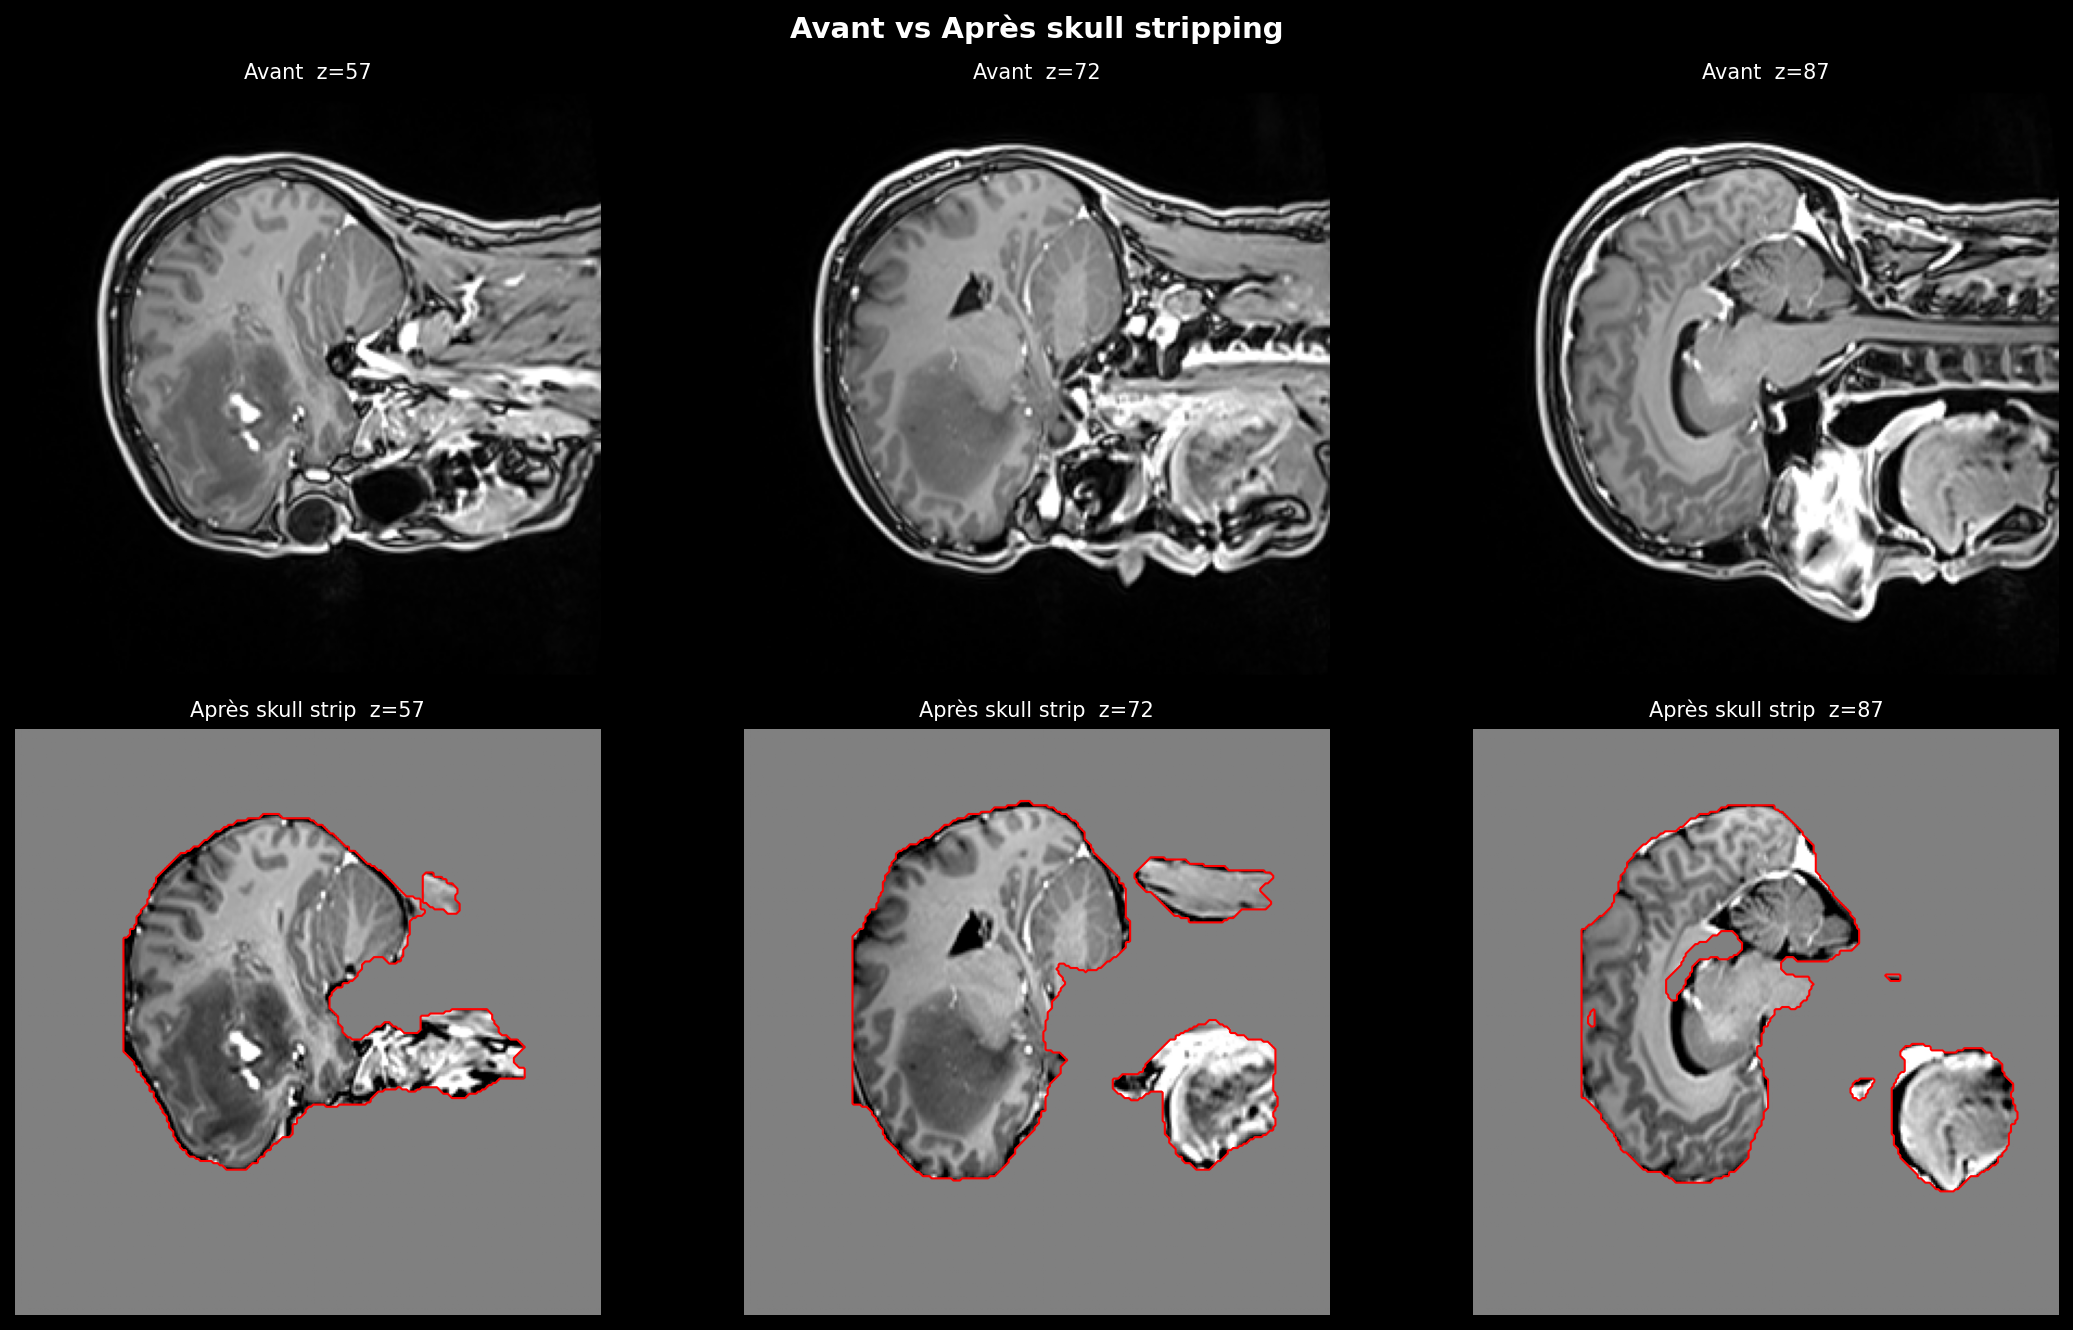

── verification_triplanaire.png ──


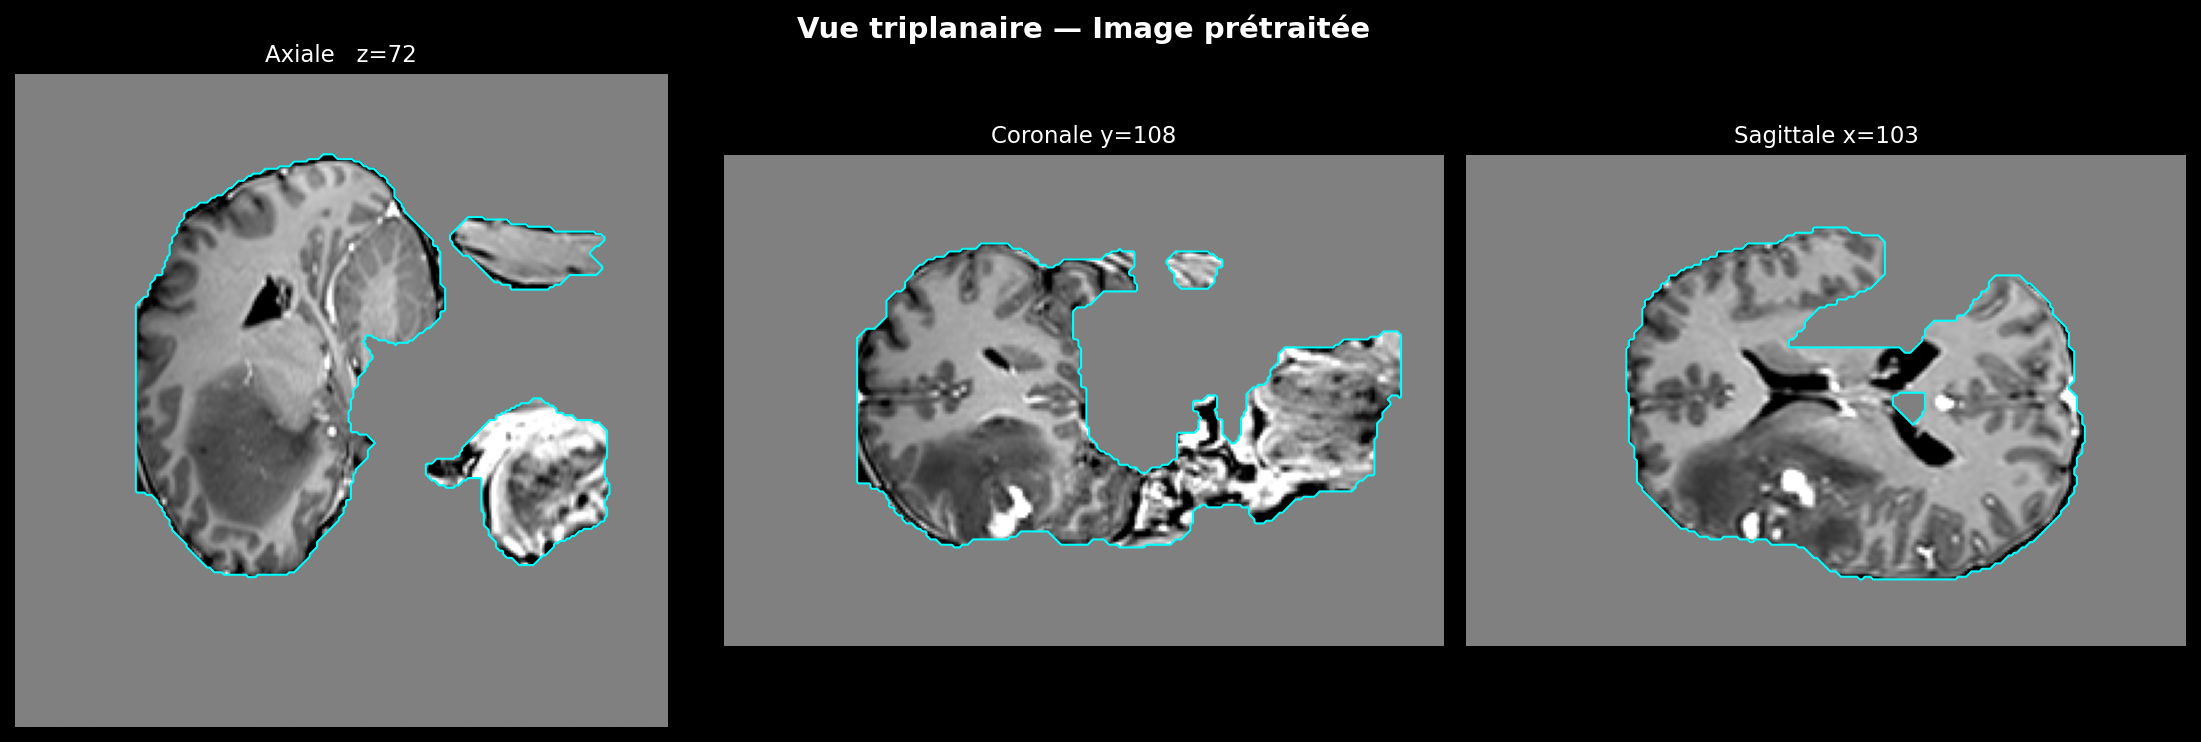

── verification_histogramme.png ──


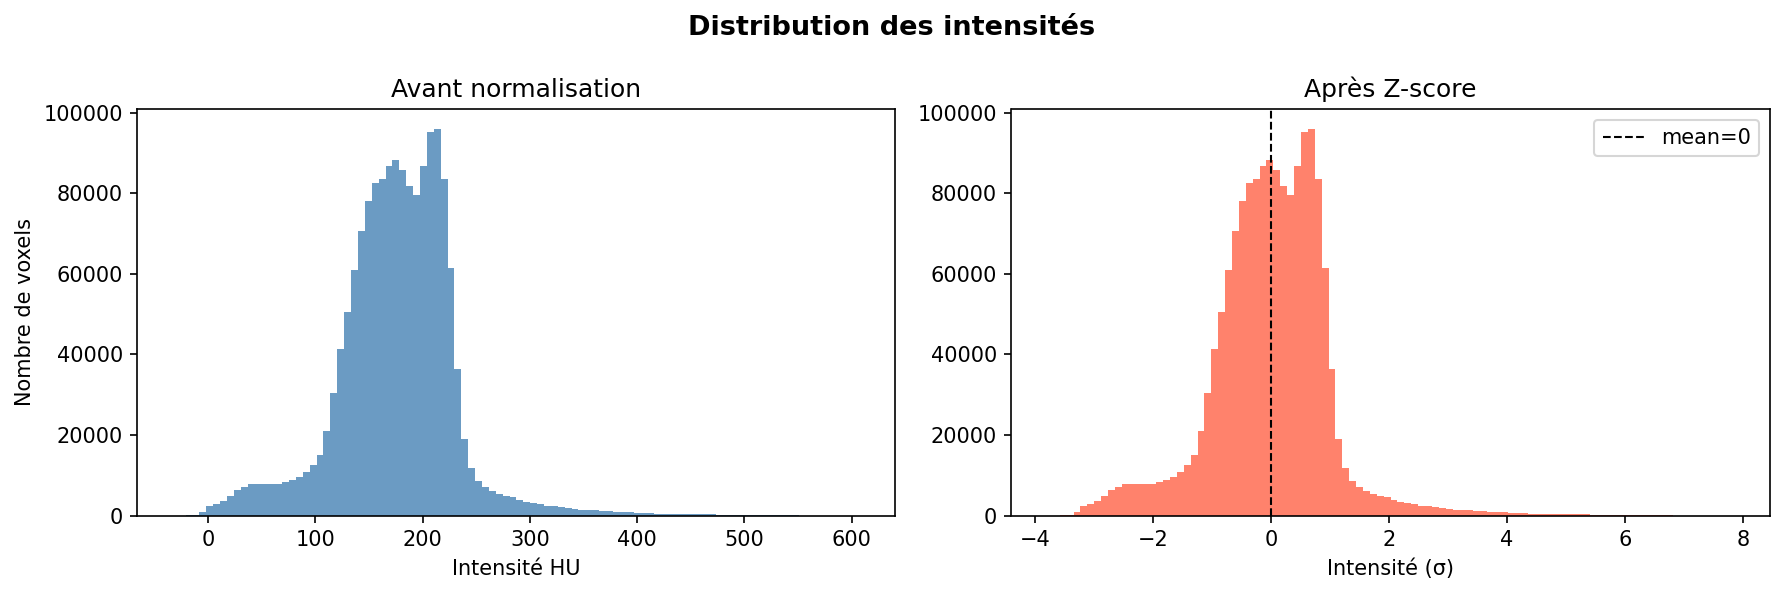

In [ ]:
from IPython.display import Image, display
for fname in ['verification_axiale.png', 'verification_triplanaire.png', 'verification_histogramme.png']:
    fpath = f'{OUTPUT_DIR}/{fname}'
    if os.path.exists(fpath):
        print(f"── {fname} ──")
        display(Image(filename=fpath))

In [ ]:
# ── Sauvegarder le modèle entraîné dans Drive ──────────────────
# Si vous utilisez Keras/TensorFlow :
model.save('/content/drive/MyDrive/DICOM_preprocessed/unet_model.keras')

# Si vous utilisez PyTorch :
# import torch
# torch.save(model.state_dict(), '/content/drive/MyDrive/DICOM_preprocessed/unet_model.pth')

print("Modèle sauvegardé dans Drive")

Modèle sauvegardé dans Drive


In [ ]:
# ── Recharger le modèle à chaque démarrage de l'API ───────────
MODEL_PATH = '/content/drive/MyDrive/DICOM_preprocessed/unet_model.keras'

# Keras :
from tensorflow.keras.models import load_model
model = load_model(MODEL_PATH, custom_objects={'combined_loss': combined_loss, 'dice_loss': dice_loss})

# PyTorch :
# model = UNet()  # votre classe UNet
# model.load_state_dict(torch.load(MODEL_PATH))
# model.eval()

print(f"Modèle chargé : {MODEL_PATH}")

Modèle chargé : /content/drive/MyDrive/DICOM_preprocessed/unet_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 40 variables whereas the saved optimizer has 78 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELLULE 3 — Correction axe + skull strip                       ║
# ╚══════════════════════════════════════════════════════════════════╝

import ants, antspynet
import numpy as np
from scipy import ndimage
import os

OUTPUT_DIR = '/content/drive/MyDrive/DICOM_preprocessed'

print("="*55)
print("PIPELINE CORRIGÉ — permutation d'axes")
print("="*55)

# ── 1. Chargement ──────────────────────────────────────────────
print("\n[1/6] Chargement...")
# Fix: Use volume_np and spacing from previous cells instead of t1_path
t1 = ants.from_numpy(
    volume_np,
    spacing=list(spacing),
    origin=[0.0, 0.0, 0.0],
    direction=np.eye(3).tolist()
)
print(f"      Shape original  : {t1.shape}")
print(f"      Spacing         : {t1.spacing}")

# ── 2. Réorientation RAS ───────────────────────────────────────
print("\n[2/6] Réorientation RAS...")
t1_ras = ants.reorient_image2(t1, orientation='RAS')
print(f"      Shape après RAS : {t1_ras.shape}")
print(f"      Spacing RAS     : {t1_ras.spacing}")

# ── 3. Détection de l'axe sagittal et permutation ─────────────
print("\n[3/6] Détection orientation et permutation axes...")

shape   = t1_ras.shape
spacing = t1_ras.spacing
sizes   = [shape[i] * spacing[i] for i in range(3)]
print(f"      Tailles physiques (mm) : X={sizes[0]:.0f}  Y={sizes[1]:.0f}  Z={sizes[2]:.0f}")

# Dans une T1 sagittale en RAS :
# X = petit (gauche-droite, ~180mm)
# Y = grand  (antérieur-postérieur, ~240mm)
# Z = grand  (supérieur-inférieur, ~270mm)
# → l'axe Z est déjà correct SEULEMENT si shape[2] est grand
# Vérifier que Z est bien l'axe supérieur-inférieur (le plus grand en mm)

dominant = int(np.argmax(sizes))
print(f"      Axe dominant (le plus long) : {'XYZ'[dominant]}")

# Convertir en numpy pour permuter si nécessaire
arr = t1_ras.numpy()
sp  = list(t1_ras.spacing)

if dominant == 0:
    # X est le plus long → c'est l'axe SI → permuter X↔Z
    print("      Permutation X↔Z (axe sagittal détecté sur X)")
    arr = np.transpose(arr, (2, 1, 0))
    sp  = [sp[2], sp[1], sp[0]]
elif dominant == 1:
    # Y est le plus long → permuter Y↔Z
    print("      Permutation Y↔Z (axe sagittal détecté sur Y)")
    arr = np.transpose(arr, (0, 2, 1))
    sp  = [sp[0], sp[2], sp[1]]
else:
    print("      Z est déjà l'axe dominant → pas de permutation")

print(f"      Shape après permutation : {arr.shape}")
print(f"      Spacing après           : {sp}")

# Reconstruire l'image ANTs
t1_perm = ants.from_numpy(
    arr.astype(np.float32),
    spacing=sp,
    origin=[0.0, 0.0, 0.0],
    direction=np.eye(3).tolist()
)

# ── 4. Resample 1×1×1 mm ──────────────────────────────────────
print("\n[4/6] Resample 1×1×1 mm...")
t1_res = ants.resample_image(t1_perm, (1,1,1), use_voxels=False, interp_type=4)
print(f"      Shape après resample : {t1_res.shape}")

# ── 5. Correction N4 ──────────────────────────────────────────
print("\n[5/6] Correction N4...")
t1_n4 = ants.n4_bias_field_correction(
    t1_res,
    shrink_factor=2,
    convergence={'iters': [50,50,50,50], 'tol': 1e-7}
)
print("      N4 terminé")

# ── 6. Skull stripping + nettoyage composant connexe ──────────
print("\n[6/6] Skull stripping...")
brain_prob = antspynet.brain_extraction(t1_n4, modality='t1', verbose=False)
brain_mask_raw = ants.threshold_image(brain_prob, 0.5, 1.0, 1, 0)

# Garder uniquement le PLUS GRAND composant connexe
mask_np = brain_mask_raw.numpy().astype(np.uint8)
labeled, n = ndimage.label(mask_np)
print(f"      Composants connexes détectés : {n}")

if n > 1:
    sizes_cc = np.bincount(labeled.flatten())
    sizes_cc[0] = 0
    largest_label = int(np.argmax(sizes_cc))
    mask_clean = (labeled == largest_label).astype(np.uint8)
    print(f"      Plus grand composant gardé : {mask_clean.sum()} voxels")
else:
    mask_clean = mask_np

# Remplissage des trous + légère dilatation
mask_filled  = ndimage.binary_fill_holes(mask_clean).astype(np.uint8)
mask_dilated = ndimage.binary_dilation(mask_filled, iterations=2).astype(np.uint8)
mask_final   = ndimage.binary_fill_holes(mask_dilated).astype(np.uint8)

brain_mask = t1_n4.new_image_like(mask_final.astype(np.float32))
mask_np    = mask_final.astype(bool)
t1_brain   = ants.mask_image(t1_n4, brain_mask)

pct = 100.0 * mask_np.sum() / np.prod(mask_np.shape)
print(f"      Volume cerveau : {pct:.1f}%")
if 5 < pct < 55:
    print("      ✓ Skull stripping plausible")
else:
    print("      ⚠ Vérifier visuellement")

# ── Normalisation Z-score ──────────────────────────────────────
t1_np      = t1_brain.numpy().astype(np.float32)
brain_vals = t1_np[mask_np]
t1_norm    = np.zeros_like(t1_np)
t1_norm[mask_np] = (brain_vals - brain_vals.mean()) / (brain_vals.std() + 1e-6)
print(f"      mean≈{t1_norm[mask_np].mean():.4f}  std≈{t1_norm[mask_np].std():.4f}")

# ── Sauvegarde ─────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'clinical_t1_preprocessed.nii.gz')
ants.image_write(t1_brain.new_image_like(t1_norm), out_path)
print(f"\n✓ Sauvegardé : {out_path}")

PIPELINE CORRIGÉ — permutation d'axes

[1/6] Chargement...
      Shape original  : (256, 256, 160)
      Spacing         : (1.05469, 1.05469, 1.15)

[2/6] Réorientation RAS...
      Shape après RAS : (256, 256, 160)
      Spacing RAS     : (1.05469, 1.05469, 1.15)

[3/6] Détection orientation et permutation axes...
      Tailles physiques (mm) : X=270  Y=270  Z=184
      Axe dominant (le plus long) : X
      Permutation X↔Z (axe sagittal détecté sur X)
      Shape après permutation : (160, 256, 256)
      Spacing après           : [1.15, 1.05469, 1.05469]

[4/6] Resample 1×1×1 mm...
      Shape après resample : (184, 270, 270)

[5/6] Correction N4...
      N4 terminé

[6/6] Skull stripping...


      Composants connexes détectés : 13
      Plus grand composant gardé : 834259 voxels
      Volume cerveau : 7.2%
      ✓ Skull stripping plausible
      mean≈-0.0000  std≈1.0000

✓ Sauvegardé : /content/drive/MyDrive/DICOM_preprocessed/clinical_t1_preprocessed.nii.gz


Centre de masse : x=93  y=161  z=121
Shape volume    : (184, 270, 270)

── verification_axiale.png ──


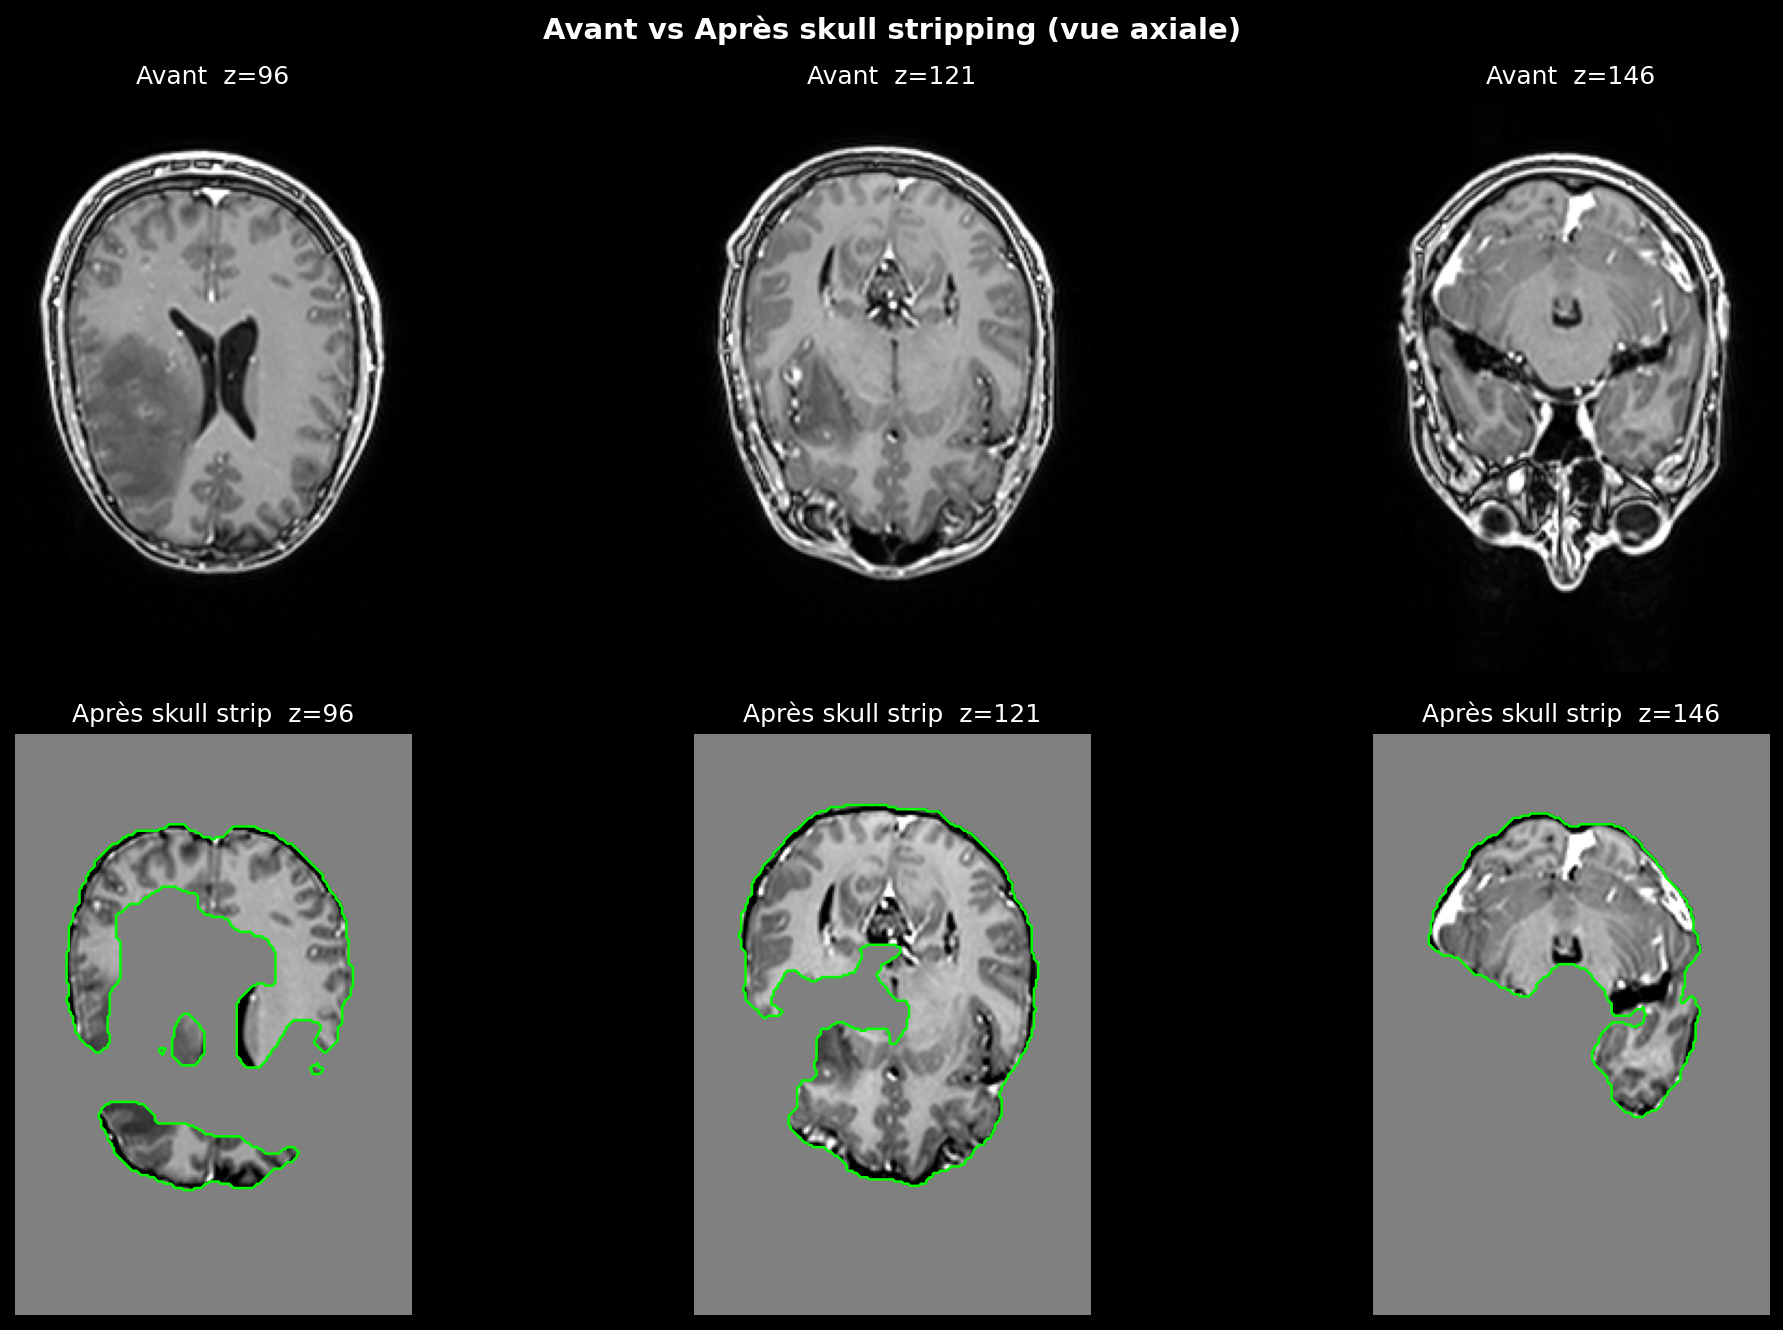


── verification_triplanaire.png ──


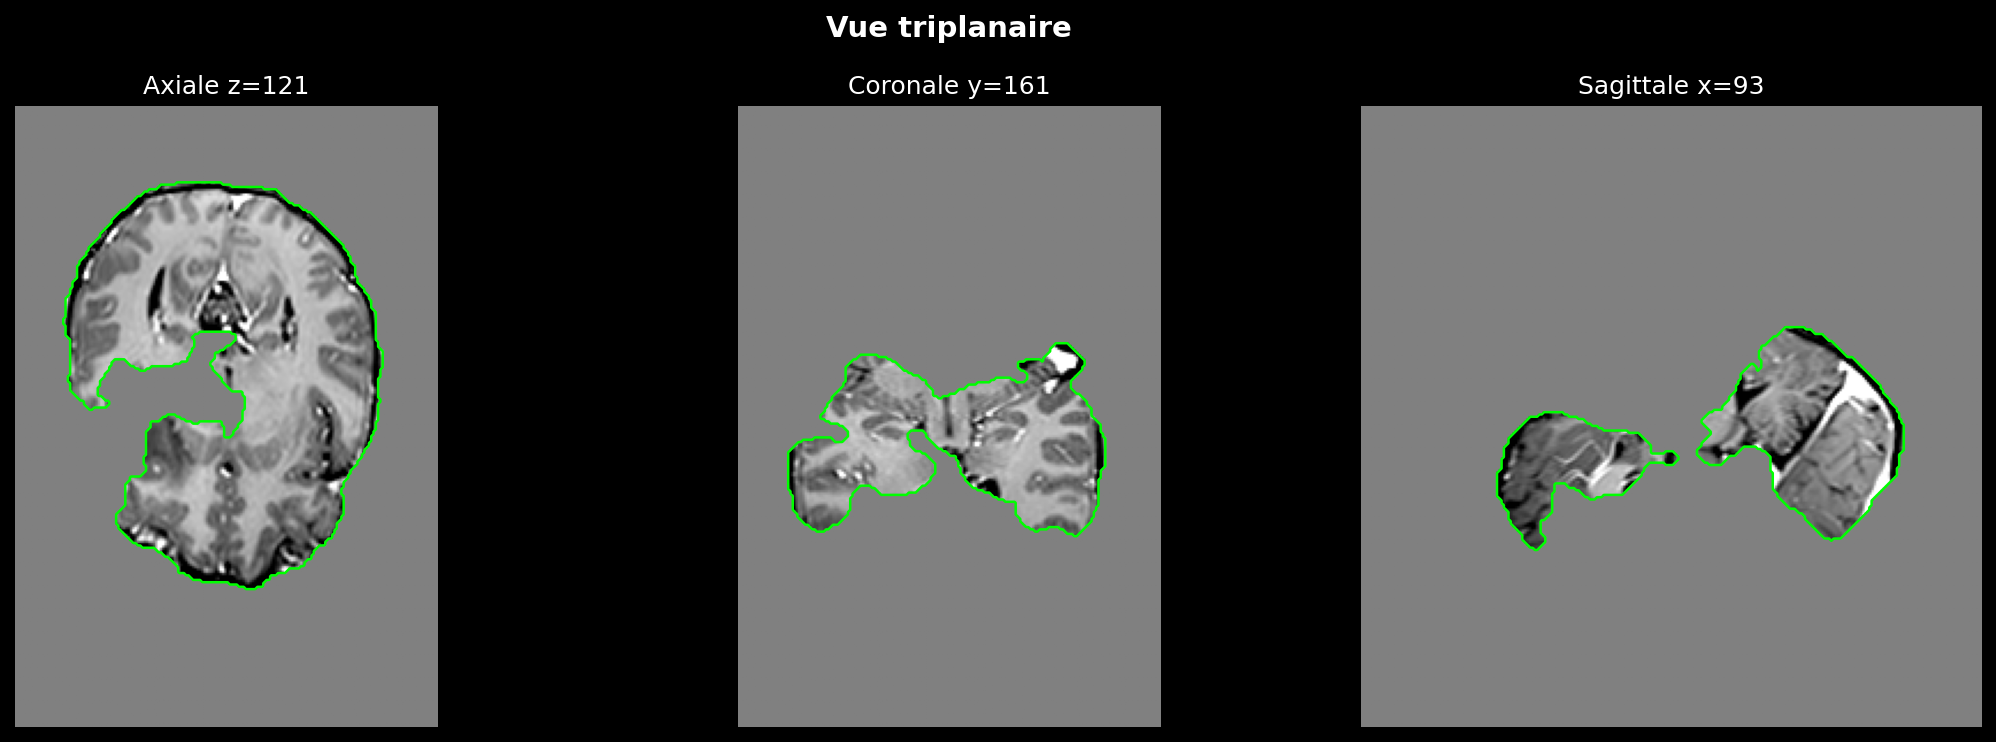


✓ Si les coupes 'Avant' ressemblent à une vue du dessus du crâne → orientation correcte
✓ Si c'est encore une vue de profil → copiez les valeurs shape/spacing et envoyez-les moi


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Vérification (coupes axiales = vue du dessus)      ║
# ╚══════════════════════════════════════════════════════════════════╝

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

# Centre de masse du masque → coupes représentatives
cm = ndimage.center_of_mass(mask_np.astype(float))
x_cm, y_cm, z_cm = int(cm[0]), int(cm[1]), int(cm[2])
print(f"Centre de masse : x={x_cm}  y={y_cm}  z={z_cm}")
print(f"Shape volume    : {t1_norm.shape}")

# Vérification rapide : la coupe z_cm doit ressembler à une vue axiale du cerveau
t1_raw_np = t1_n4.numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('black')
fig.suptitle('Avant vs Après skull stripping (vue axiale)',
             fontsize=14, fontweight='bold', color='white')

for col, z in enumerate([max(0,z_cm-25), z_cm, min(t1_norm.shape[2]-1, z_cm+25)]):
    axes[0,col].imshow(t1_raw_np[:,:,z].T, cmap='gray', origin='lower',
                       vmin=np.percentile(t1_raw_np[t1_raw_np>0],1),
                       vmax=np.percentile(t1_raw_np[t1_raw_np>0],99))
    axes[0,col].set_title(f'Avant  z={z}', color='white')
    axes[0,col].axis('off')
    axes[0,col].set_facecolor('black')

    axes[1,col].imshow(t1_norm[:,:,z].T, cmap='gray', origin='lower', vmin=-2, vmax=2)
    axes[1,col].contour(mask_np[:,:,z].T, levels=[0.5], colors='lime', linewidths=1.2)
    axes[1,col].set_title(f'Après skull strip  z={z}', color='white')
    axes[1,col].axis('off')
    axes[1,col].set_facecolor('black')

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/verification_axiale.png', dpi=150,
            bbox_inches='tight', facecolor='black')
plt.close()

# Vue triplanaire
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.patch.set_facecolor('black')
fig2.suptitle('Vue triplanaire', fontsize=14, fontweight='bold', color='white')

views = [
    (t1_norm[:,:,z_cm].T,  mask_np[:,:,z_cm].T,  f'Axiale z={z_cm}'),
    (t1_norm[:,y_cm,:].T,  mask_np[:,y_cm,:].T,  f'Coronale y={y_cm}'),
    (t1_norm[x_cm,:,:].T,  mask_np[x_cm,:,:].T,  f'Sagittale x={x_cm}'),
]
for col, (img, msk, title) in enumerate(views):
    axes2[col].imshow(img, cmap='gray', origin='lower', vmin=-2, vmax=2)
    axes2[col].contour(msk, levels=[0.5], colors='lime', linewidths=1.2)
    axes2[col].set_title(title, color='white')
    axes2[col].axis('off')
    axes2[col].set_facecolor('black')

plt.tight_layout()
fig2.savefig(f'{OUTPUT_DIR}/verification_triplanaire.png', dpi=150,
             bbox_inches='tight', facecolor='black')
plt.close()

# Affichage
for fname in ['verification_axiale.png', 'verification_triplanaire.png']:
    print(f"\n── {fname} ──")
    display(IPImage(filename=f'{OUTPUT_DIR}/{fname}'))

print("\n✓ Si les coupes 'Avant' ressemblent à une vue du dessus du crâne → orientation correcte")
print("✓ Si c'est encore une vue de profil → copiez les valeurs shape/spacing et envoyez-les moi")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELLULE 3 FINALE — Crop + skull strip robuste                  ║
# ╚══════════════════════════════════════════════════════════════════╝

import ants, antspynet
import numpy as np
from scipy import ndimage
import os

OUTPUT_DIR = '/content/drive/MyDrive/DICOM_preprocessed'

print("="*55)
print("PIPELINE FINAL — crop + skull strip")
print("="*55)

# ── 1. Chargement ──────────────────────────────────────────────
print("\n[1/7] Chargement...")
t1 = ants.from_numpy(
    volume_np,
    spacing=list(spacing),
    origin=[0.0, 0.0, 0.0],
    direction=np.eye(3).tolist()
)
print(f"      Shape : {t1.shape}  Spacing : {t1.spacing}")

# ── 2. RAS ─────────────────────────────────────────────────────
print("\n[2/7] Réorientation RAS...")
t1_ras = ants.reorient_image2(t1, orientation='RAS')

# ── 3. Permutation axes (sagittal → axial) ────────────────────
print("\n[3/7] Permutation axes...")
shape   = t1_ras.shape
spacing = t1_ras.spacing
sizes   = [shape[i] * spacing[i] for i in range(3)]
dominant = int(np.argmax(sizes))
arr = t1_ras.numpy()
sp  = list(spacing)

if dominant == 0:
    arr = np.transpose(arr, (2, 1, 0)); sp = [sp[2], sp[1], sp[0]]
elif dominant == 1:
    arr = np.transpose(arr, (0, 2, 1)); sp = [sp[0], sp[2], sp[1]]

print(f"      Shape après permutation : {arr.shape}  Spacing : {sp}")

t1_perm = ants.from_numpy(arr.astype(np.float32), spacing=sp,
                           origin=[0.,0.,0.], direction=np.eye(3).tolist())

# ── 4. Resample 1×1×1 mm ──────────────────────────────────────
print("\n[4/7] Resample 1×1×1 mm...")
t1_res = ants.resample_image(t1_perm, (1,1,1), use_voxels=False, interp_type=4)
print(f"      Shape : {t1_res.shape}")

# ── 5. Crop automatique — garder uniquement le cerveau ─────────
print("\n[5/7] Crop autour du cerveau...")

def crop_brain_region(image):
    """
    Supprime le cou et la face par un crop en Z (axe supérieur-inférieur).
    Le cerveau occupe typiquement les 60% supérieurs du volume tête entière.
    On utilise Otsu pour détecter la tête puis on garde le haut.
    """
    arr = image.numpy()
    sp  = image.spacing

    # Seuil Otsu simple pour détecter la tête (tout ce qui n'est pas fond)
    from skimage.filters import threshold_otsu
    thresh = threshold_otsu(arr[arr > 0])
    head_mask = arr > (thresh * 0.3)  # seuil bas pour capturer tout le tissu

    # Trouver les bornes Z de la tête
    z_profile = head_mask.sum(axis=(0,1))
    z_nonzero = np.where(z_profile > z_profile.max() * 0.05)[0]
    z_min, z_max = int(z_nonzero[0]), int(z_nonzero[-1])
    z_total = z_max - z_min

    # Garder les 75% supérieurs (cerveau) — couper le bas (cou/menton)
    z_cut = z_min + int(z_total * 0.25)
    print(f"      Z total tête : {z_min}→{z_max}  ({z_total} coupes)")
    print(f"      Coupure cou  : z < {z_cut}  (garde {z_max - z_cut} coupes)")

    arr_crop = arr[:, :, z_cut:z_max+1]
    img_crop = ants.from_numpy(arr_crop.astype(np.float32),
                                spacing=list(sp),
                                origin=[0.,0.,0.],
                                direction=np.eye(3).tolist())
    return img_crop, z_cut

t1_crop, z_offset = crop_brain_region(t1_res)
print(f"      Shape après crop : {t1_crop.shape}")

# ── 6. N4 sur l'image croppée ──────────────────────────────────
print("\n[6/7] Correction N4...")
t1_n4 = ants.n4_bias_field_correction(
    t1_crop, shrink_factor=2,
    convergence={'iters': [50,50,50,50], 'tol': 1e-7}
)
print("      N4 terminé")

# ── 7. Skull stripping + nettoyage ────────────────────────────
print("\n[7/7] Skull stripping...")
brain_prob     = antspynet.brain_extraction(t1_n4, modality='t1', verbose=False)
brain_mask_raw = ants.threshold_image(brain_prob, 0.5, 1.0, 1, 0)
mask_np        = brain_mask_raw.numpy().astype(np.uint8)

# Garder uniquement le plus grand composant connexe
labeled, n = ndimage.label(mask_np)
print(f"      Composants connexes : {n}")
if n > 1:
    cc_sizes      = np.bincount(labeled.flatten()); cc_sizes[0] = 0
    mask_np       = (labeled == int(np.argmax(cc_sizes))).astype(np.uint8)

# Fill holes + dilation légère
mask_np = ndimage.binary_fill_holes(mask_np).astype(np.uint8)
mask_np = ndimage.binary_dilation(mask_np, iterations=2).astype(np.uint8)
mask_np = ndimage.binary_fill_holes(mask_np).astype(np.uint8)

brain_mask = t1_n4.new_image_like(mask_np.astype(np.float32))
mask_bool  = mask_np.astype(bool)
t1_brain   = ants.mask_image(t1_n4, brain_mask)

pct = 100.0 * mask_bool.sum() / np.prod(mask_bool.shape)
print(f"      Volume cerveau : {pct:.1f}%  ", end="")
print("✓" if 5 < pct < 55 else "⚠ vérifier")

# ── Normalisation Z-score ──────────────────────────────────────
t1_np      = t1_brain.numpy().astype(np.float32)
brain_vals = t1_np[mask_bool]
t1_norm    = np.zeros_like(t1_np)
t1_norm[mask_bool] = (brain_vals - brain_vals.mean()) / (brain_vals.std() + 1e-6)
print(f"      mean≈{t1_norm[mask_bool].mean():.4f}  std≈{t1_norm[mask_bool].std():.4f}")

# ── Sauvegarde ─────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'clinical_t1_preprocessed.nii.gz')
ants.image_write(t1_brain.new_image_like(t1_norm), out_path)
print(f"\n✓ Sauvegardé : {out_path}")

PIPELINE FINAL — crop + skull strip

[1/7] Chargement...
      Shape : (256, 256, 160)  Spacing : (1.05469, 1.05469, 1.15)

[2/7] Réorientation RAS...

[3/7] Permutation axes...
      Shape après permutation : (160, 256, 256)  Spacing : [1.15, 1.05469, 1.05469]

[4/7] Resample 1×1×1 mm...
      Shape : (184, 270, 270)

[5/7] Crop autour du cerveau...
      Z total tête : 30→269  (239 coupes)
      Coupure cou  : z < 89  (garde 180 coupes)
      Shape après crop : (184, 270, 181)

[6/7] Correction N4...
      N4 terminé

[7/7] Skull stripping...
      Composants connexes : 19
      Volume cerveau : 3.7%  ⚠ vérifier
      mean≈-0.0000  std≈1.0000

✓ Sauvegardé : /content/drive/MyDrive/DICOM_preprocessed/clinical_t1_preprocessed.nii.gz



── verification_axiale.png ──


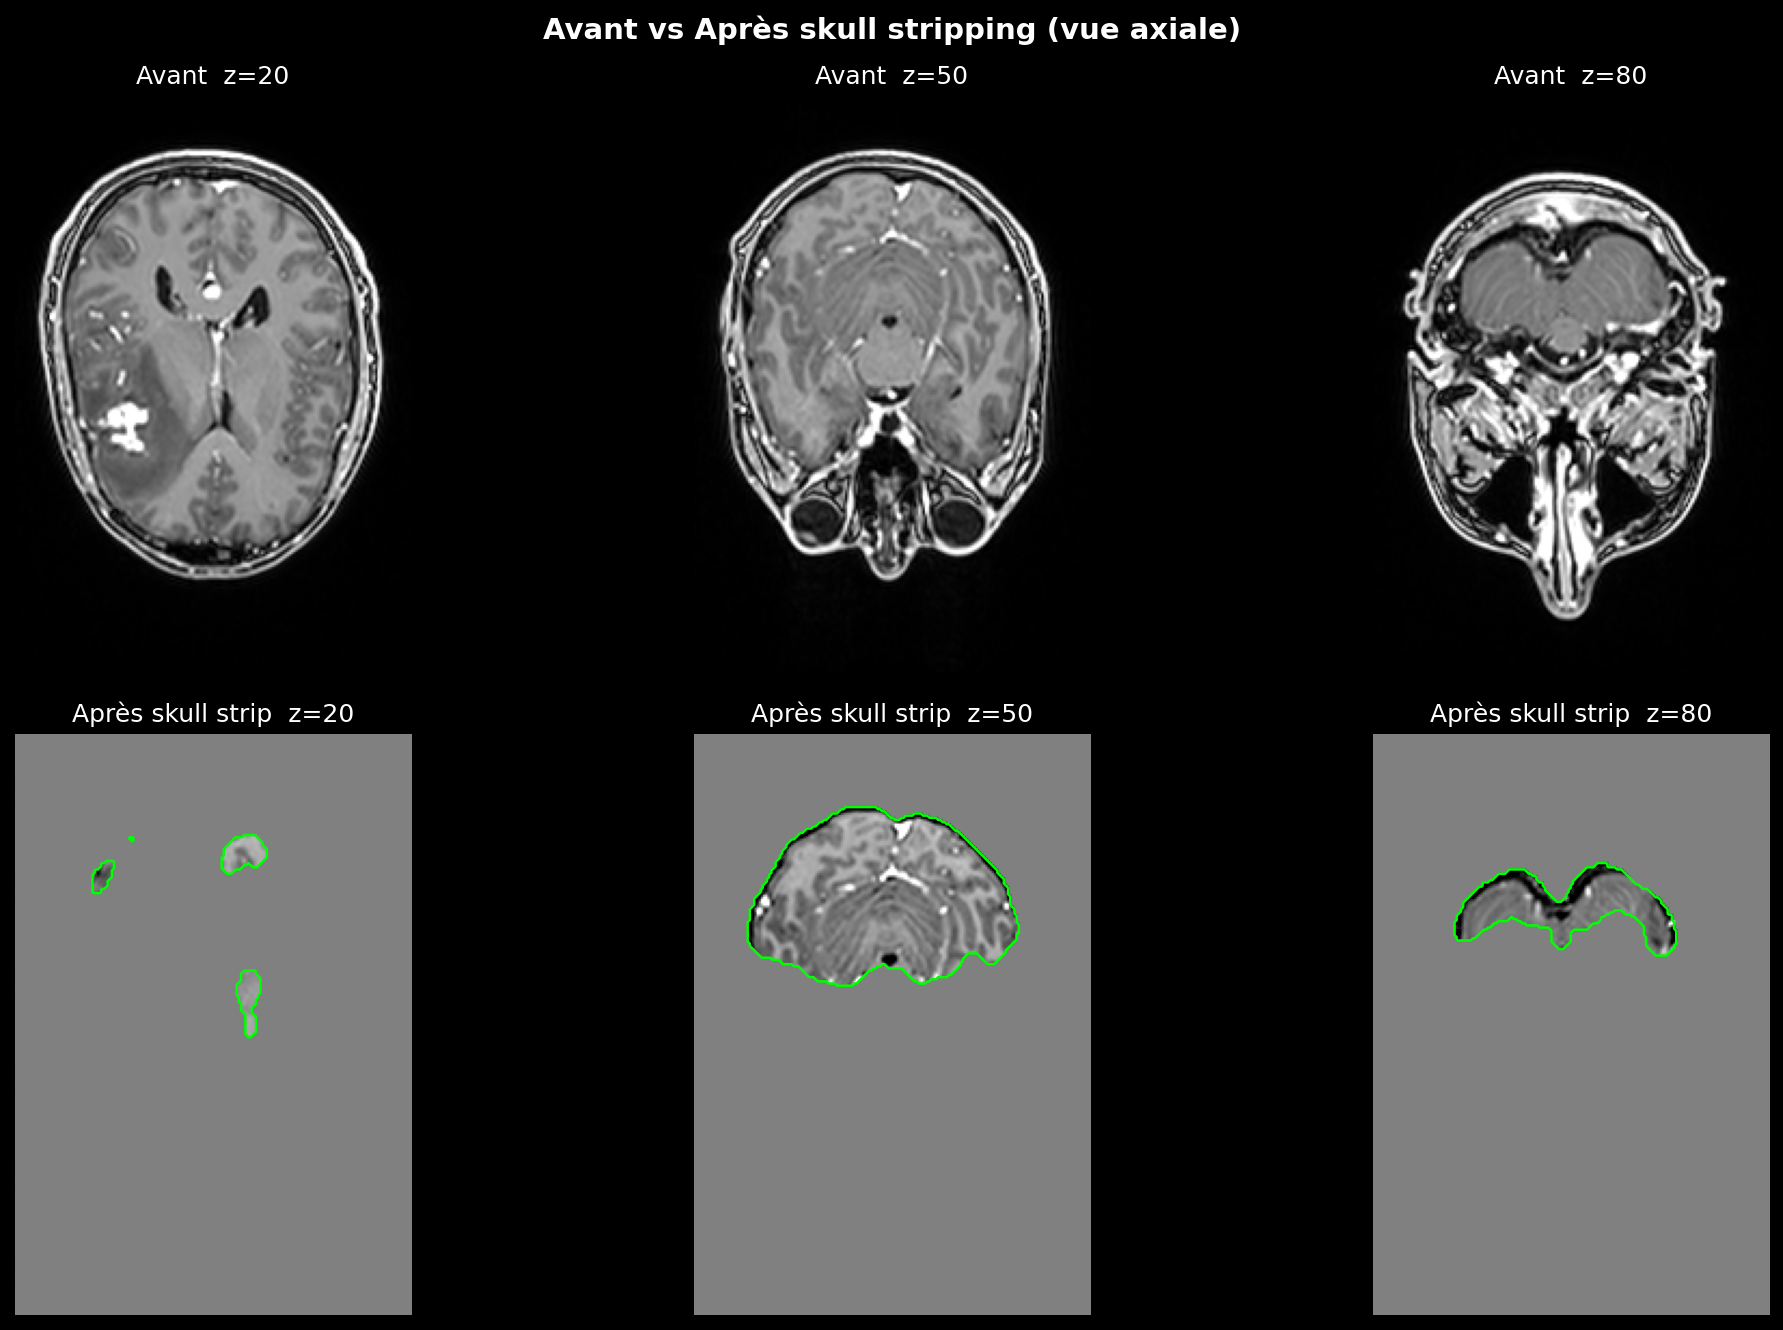


── verification_triplanaire.png ──


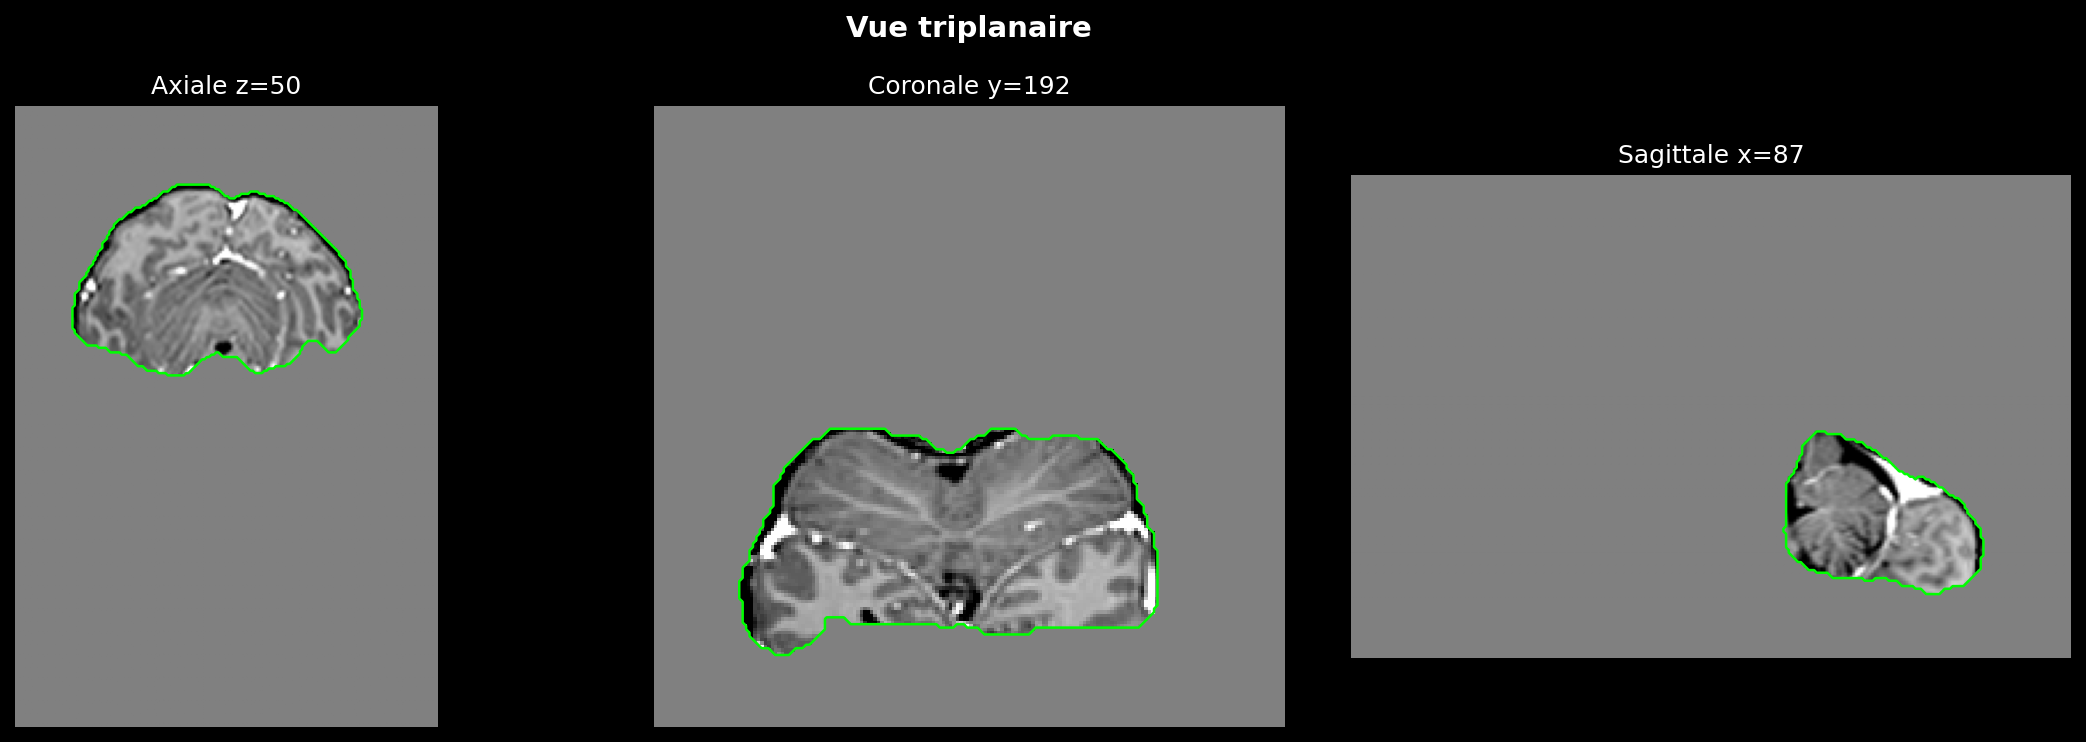


✓ Le contour vert doit entourer UN seul cerveau continu sans fragments
  Si encore fragmenté → envoyez-moi la valeur 'Volume cerveau %' affichée


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Vérification visuelle                              ║
# ╚══════════════════════════════════════════════════════════════════╝

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

cm     = ndimage.center_of_mass(mask_bool.astype(float))
x_cm, y_cm, z_cm = int(cm[0]), int(cm[1]), int(cm[2])
n_z    = t1_norm.shape[2]
t1_raw = t1_n4.numpy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('black')
fig.suptitle('Avant vs Après skull stripping (vue axiale)',
             fontsize=14, fontweight='bold', color='white')

for col, z in enumerate([max(0,z_cm-30), z_cm, min(n_z-1,z_cm+30)]):
    axes[0,col].imshow(t1_raw[:,:,z].T, cmap='gray', origin='lower',
                       vmin=np.percentile(t1_raw[t1_raw>0],1),
                       vmax=np.percentile(t1_raw[t1_raw>0],99))
    axes[0,col].set_title(f'Avant  z={z}', color='white'); axes[0,col].axis('off')
    axes[0,col].set_facecolor('black')

    axes[1,col].imshow(t1_norm[:,:,z].T, cmap='gray', origin='lower', vmin=-2, vmax=2)
    axes[1,col].contour(mask_bool[:,:,z].T, levels=[0.5], colors='lime', linewidths=1.2)
    axes[1,col].set_title(f'Après skull strip  z={z}', color='white'); axes[1,col].axis('off')
    axes[1,col].set_facecolor('black')

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/verification_axiale.png', dpi=150,
            bbox_inches='tight', facecolor='black')
plt.close()

# Vue triplanaire
fig2, axes2 = plt.subplots(1, 3, figsize=(15,5))
fig2.patch.set_facecolor('black')
fig2.suptitle('Vue triplanaire', fontsize=14, fontweight='bold', color='white')

for col, (img, msk, title) in enumerate([
    (t1_norm[:,:,z_cm].T,  mask_bool[:,:,z_cm].T,  f'Axiale z={z_cm}'),
    (t1_norm[:,y_cm,:].T,  mask_bool[:,y_cm,:].T,  f'Coronale y={y_cm}'),
    (t1_norm[x_cm,:,:].T,  mask_bool[x_cm,:,:].T,  f'Sagittale x={x_cm}'),
]):
    axes2[col].imshow(img, cmap='gray', origin='lower', vmin=-2, vmax=2)
    axes2[col].contour(msk, levels=[0.5], colors='lime', linewidths=1.2)
    axes2[col].set_title(title, color='white'); axes2[col].axis('off')
    axes2[col].set_facecolor('black')

plt.tight_layout()
fig2.savefig(f'{OUTPUT_DIR}/verification_triplanaire.png', dpi=150,
             bbox_inches='tight', facecolor='black')
plt.close()

for fname in ['verification_axiale.png', 'verification_triplanaire.png']:
    print(f"\n── {fname} ──")
    display(IPImage(filename=f'{OUTPUT_DIR}/{fname}'))

print("\n✓ Le contour vert doit entourer UN seul cerveau continu sans fragments")
print("  Si encore fragmenté → envoyez-moi la valeur 'Volume cerveau %' affichée")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELLULE 0 — Installation FSL BET (une seule fois)             ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, os

# Installer FSL (contient BET)
print("Installation FSL...")
cmds = [
    "apt-get install -y fsl-core 2>/dev/null | tail -3",
    "ls /usr/lib/fsl/5.0/bet 2>/dev/null || echo 'BET non trouvé'",
]
for cmd in cmds:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(result.stdout.strip() or result.stderr.strip())

# Vérifier le chemin BET
bet_paths = [
    '/usr/lib/fsl/5.0/bet',
    '/usr/local/fsl/bin/bet',
    '/usr/bin/bet',
]
BET_PATH = None
for p in bet_paths:
    if os.path.exists(p):
        BET_PATH = p
        print(f"✓ BET trouvé : {BET_PATH}")
        break

if BET_PATH is None:
    print("BET non trouvé — installation alternative...")
    subprocess.run("pip install -q fslpy", shell=True)
    print("Utilisation de nibabel+scipy comme fallback")

Installation FSL...
Reading package lists...
Building dependency tree...
Reading state information...
BET non trouvé
BET non trouvé — installation alternative...
Utilisation de nibabel+scipy comme fallback


In [ ]:
import ants
import numpy as np
import nibabel as nib
from scipy import ndimage
from skimage import morphology, filters
import subprocess, os, tempfile

OUTPUT_DIR = '/content/drive/MyDrive/DICOM_preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*55)
print("PIPELINE ROBUSTE — FSL BET + fallback Otsu morpho")
print("="*55)

# ── 1. Chargement + permutation axes ──────────────────────────
print("\n[1/5] Chargement + orientation...")
# Fix: Use volume_np and spacing from previous cells instead of t1_path
t1 = ants.from_numpy(
    volume_np,
    spacing=list(spacing),
    origin=[0.0, 0.0, 0.0],
    direction=np.eye(3).tolist()
)
t1_ras = ants.reorient_image2(t1, orientation='RAS')

shape   = t1_ras.shape
spacing = t1_ras.spacing
sizes   = [shape[i]*spacing[i] for i in range(3)]
dominant = int(np.argmax(sizes))
arr = t1_ras.numpy()
sp  = list(spacing)

if dominant == 0:
    arr = np.transpose(arr, (2,1,0)); sp = [sp[2],sp[1],sp[0]]
elif dominant == 1:
    arr = np.transpose(arr, (0,2,1)); sp = [sp[0],sp[2],sp[1]]

t1_perm = ants.from_numpy(arr.astype(np.float32), spacing=sp,
                           origin=[0.,0.,0.], direction=np.eye(3).tolist())

# ── 2. Resample 1×1×1 mm ──────────────────────────────────────
print("\n[2/5] Resample 1×1×1 mm...")
t1_res = ants.resample_image(t1_perm, (1,1,1), use_voxels=False, interp_type=4)
print(f"      Shape : {t1_res.shape}")

# ── 3. Correction N4 ──────────────────────────────────────────
print("\n[3/5] Correction N4...")
t1_n4 = ants.n4_bias_field_correction(
    t1_res,
    shrink_factor=2,
    convergence={'iters':[50,50,50,50], 'tol':1e-7}
)
print("      N4 terminé")

# Sauvegarder en NIfTI temporaire pour BET
tmp_in  = '/tmp/t1_n4.nii.gz'
tmp_out = '/tmp/t1_bet'
ants.image_write(t1_n4, tmp_in)

# ── 4. Skull stripping — 3 méthodes en cascade ────────────────
print("\n[4/5] Skull stripping...")

def method_bet(tmp_in, tmp_out, frac=0.35):
    """FSL BET — méthode standard clinique."""
    bet_path = None
    for p in ['/usr/lib/fsl/5.0/bet','/usr/local/fsl/bin/bet','/usr/bin/bet']:
        if os.path.exists(p):
            bet_path = p
            break
    if bet_path is None:
        return None, "BET non disponible"

    cmd = f"FSLOUTPUTTYPE=NIFTI_GZ {bet_path} {tmp_in} {tmp_out} -f {frac} -g 0 -m"
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    mask_path = tmp_out + '_mask.nii.gz'
    if os.path.exists(mask_path):
        mask_img = nib.load(mask_path)
        return mask_img.get_fdata().astype(np.uint8), f"BET frac={frac}"
    return None, f"BET échoué: {r.stderr[:100]}"

def method_otsu_morpho(t1_n4):
    """
    Fallback robuste : Otsu + morphologie mathématique.
    Fonctionne même sur T1 SE avec tumeur.
    """
    arr = t1_n4.numpy().astype(np.float32)
    n_z = arr.shape[2]

    # Normaliser 0-1
    p1, p99 = np.percentile(arr[arr>0], 1), np.percentile(arr[arr>0], 99)
    arr_norm = np.clip((arr - p1) / (p99 - p1 + 1e-6), 0, 1)

    # Seuil Otsu
    thresh = filters.threshold_otsu(arr_norm[arr_norm > 0.05])
    head_mask = arr_norm > thresh * 0.5

    # Supprimer le bruit
    head_mask = morphology.remove_small_objects(head_mask, min_size=5000)
    head_mask = ndimage.binary_fill_holes(head_mask)

    # Garder uniquement le plus grand objet (tête)
    labeled, n = ndimage.label(head_mask)
    if n > 1:
        sizes_cc = np.bincount(labeled.flatten()); sizes_cc[0] = 0
        head_mask = (labeled == np.argmax(sizes_cc))

    # Érosion agressive pour enlever crâne + peau
    # Le crâne fait ~6-8mm → éroder 8 voxels à 1mm
    brain_mask = ndimage.binary_erosion(head_mask, iterations=8)

    # Supprimer les petits fragments résiduels
    brain_mask = morphology.remove_small_objects(brain_mask.astype(bool), min_size=50000)

    # Re-dilater légèrement pour récupérer les bords corticaux
    brain_mask = ndimage.binary_dilation(brain_mask, iterations=3)
    brain_mask = ndimage.binary_fill_holes(brain_mask)

    # Garder uniquement le plus grand composant = cerveau
    labeled2, n2 = ndimage.label(brain_mask)
    if n2 > 1:
        sizes_cc2 = np.bincount(labeled2.flatten()); sizes_cc2[0] = 0
        brain_mask = (labeled2 == np.argmax(sizes_cc2))

    return brain_mask.astype(np.uint8), "Otsu+morphologie"

def method_watershed(t1_n4):
    """
    Méthode watershed — sépare cerveau du crâne par gradient d'intensité.
    """
    from skimage.segmentation import watershed
    from skimage.feature import peak_local_max

    arr = t1_n4.numpy().astype(np.float32)
    p1, p99 = np.percentile(arr[arr>0],1), np.percentile(arr[arr>0],99)
    arr_norm = np.clip((arr-p1)/(p99-p1+1e-6),0,1)

    # Gradient = bords du crâne
    from skimage.filters import sobel
    # Traiter coupe par coupe pour la mémoire
    brain_mask_3d = np.zeros_like(arr, dtype=bool)

    for z in range(arr_norm.shape[2]):
        sl = arr_norm[:,:,z]
        if sl.max() < 0.1:
            continue
        # Seuil adaptatif par coupe
        t = filters.threshold_otsu(sl[sl>0.05]) if (sl>0.05).sum() > 100 else 0.3
        coupe_mask = sl > t * 0.4
        coupe_mask = ndimage.binary_fill_holes(coupe_mask)
        coupe_mask = ndimage.binary_erosion(coupe_mask, iterations=6)
        coupe_mask = morphology.remove_small_objects(coupe_mask, min_size=2000)
        coupe_mask = ndimage.binary_fill_holes(coupe_mask)
        brain_mask_3d[:,:,z] = coupe_mask

    # Connexité 3D finale
    brain_mask_3d = ndimage.binary_fill_holes(brain_mask_3d)
    labeled, n = ndimage.label(brain_mask_3d)
    if n > 1:
        sizes_cc = np.bincount(labeled.flatten()); sizes_cc[0] = 0
        brain_mask_3d = (labeled == np.argmax(sizes_cc))

    return brain_mask_3d.astype(np.uint8), "Watershed par coupe"

# ── Essayer les méthodes en cascade ───────────────────────────
mask_final = None
method_used = None

for method_name, method_fn in [
    ("FSL BET",          lambda: method_bet(tmp_in, tmp_out, frac=0.35)),
    ("FSL BET relaxé",   lambda: method_bet(tmp_in, tmp_out, frac=0.20)),
    ("Otsu+morphologie", lambda: method_otsu_morpho(t1_n4)),
    ("Watershed",        lambda: method_watershed(t1_n4)),
]:
    print(f"      Essai : {method_name}...", end=" ")
    mask, info = method_fn()

    if mask is None:
        print(f"✗ {info}")
        continue

    pct = 100.0 * mask.sum() / np.prod(mask.shape)
    print(f"→ {pct:.1f}% du volume", end=" ")

    if 5 < pct < 55:
        mask_final  = mask
        method_used = method_name
        print("✓ Accepté")
        break
    else:
        print("✗ Hors plage 5-55%")

if mask_final is None:
    print("\n⚠ Toutes les méthodes ont échoué — utilisation masque complet")
    arr_np    = t1_n4.numpy()
    mask_final = (arr_np > np.percentile(arr_np[arr_np>0], 10)).astype(np.uint8)
    method_used = "Fallback intensité"

print(f"\n      ✓ Méthode retenue : {method_used}")
print(f"      Volume final     : {100*mask_final.sum()/np.prod(mask_final.shape):.1f}%")

# ── 5. Normalisation Z-score + sauvegarde ─────────────────────
print("\n[5/5] Normalisation Z-score...")
mask_bool  = mask_final.astype(bool)
brain_mask = t1_n4.new_image_like(mask_final.astype(np.float32))
t1_brain   = ants.mask_image(t1_n4, brain_mask)

t1_np      = t1_brain.numpy().astype(np.float32)
brain_vals = t1_np[mask_bool]
t1_norm    = np.zeros_like(t1_np)
t1_norm[mask_bool] = (brain_vals - brain_vals.mean()) / (brain_vals.std() + 1e-6)
print(f"      mean≈{t1_norm[mask_bool].mean():.4f}  std≈{t1_norm[mask_bool].std():.4f}")

out_path = os.path.join(OUTPUT_DIR, 'clinical_t1_preprocessed.nii.gz')
ants.image_write(t1_brain.new_image_like(t1_norm), out_path)
print(f"\n✓ Sauvegardé : {out_path}")
print(f"  Méthode skull strip utilisée : {method_used}")

PIPELINE ROBUSTE — FSL BET + fallback Otsu morpho

[1/5] Chargement + orientation...

[2/5] Resample 1×1×1 mm...
      Shape : (184, 270, 270)

[3/5] Correction N4...
      N4 terminé

[4/5] Skull stripping...
      Essai : FSL BET... ✗ BET non disponible
      Essai : FSL BET relaxé... ✗ BET non disponible
      Essai : Otsu+morphologie... → 9.4% du volume ✓ Accepté

      ✓ Méthode retenue : Otsu+morphologie
      Volume final     : 9.4%

[5/5] Normalisation Z-score...
      mean≈0.0000  std≈1.0000

✓ Sauvegardé : /content/drive/MyDrive/DICOM_preprocessed/clinical_t1_preprocessed.nii.gz
  Méthode skull strip utilisée : Otsu+morphologie



── verification_axiale.png ──


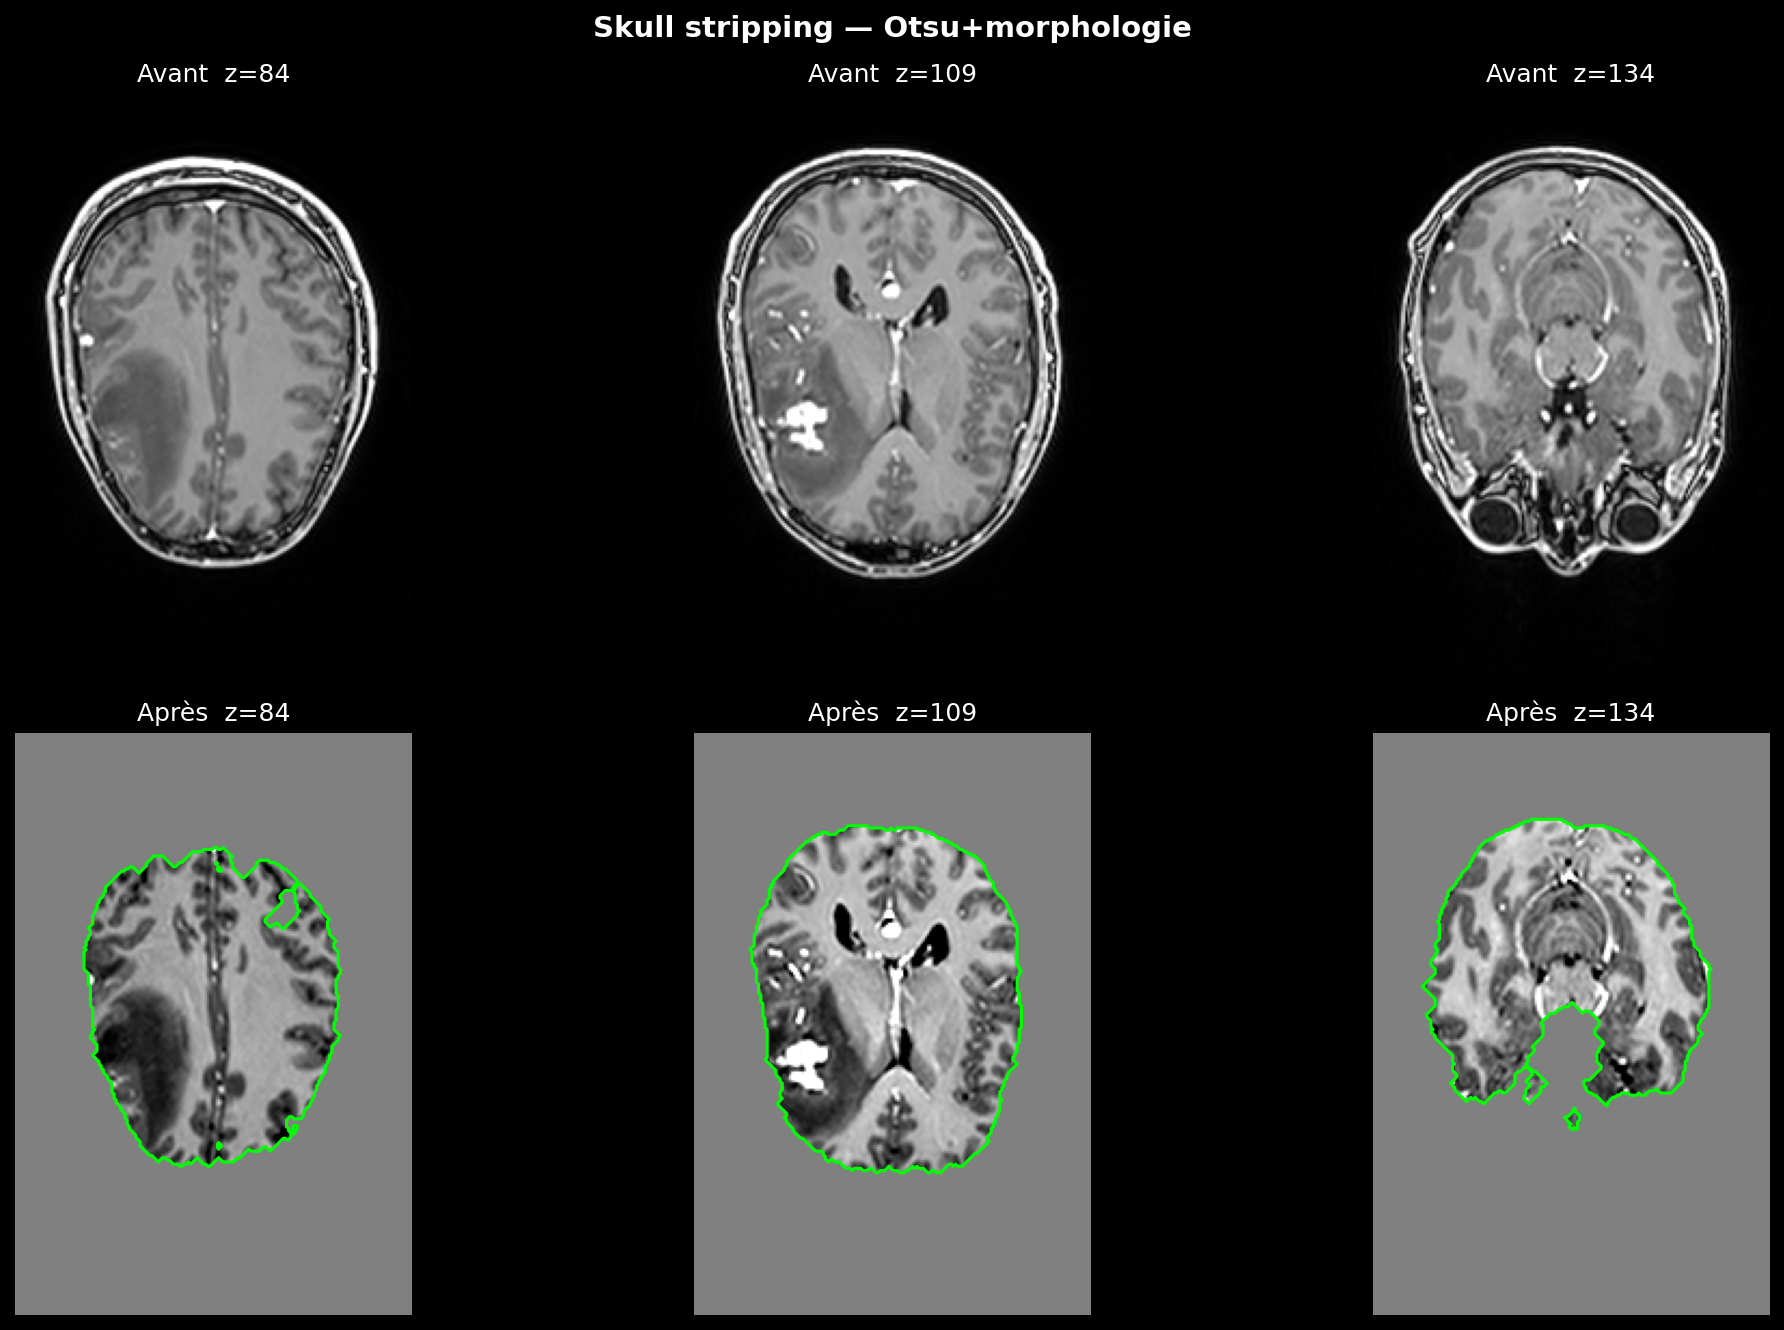


── verification_triplanaire.png ──


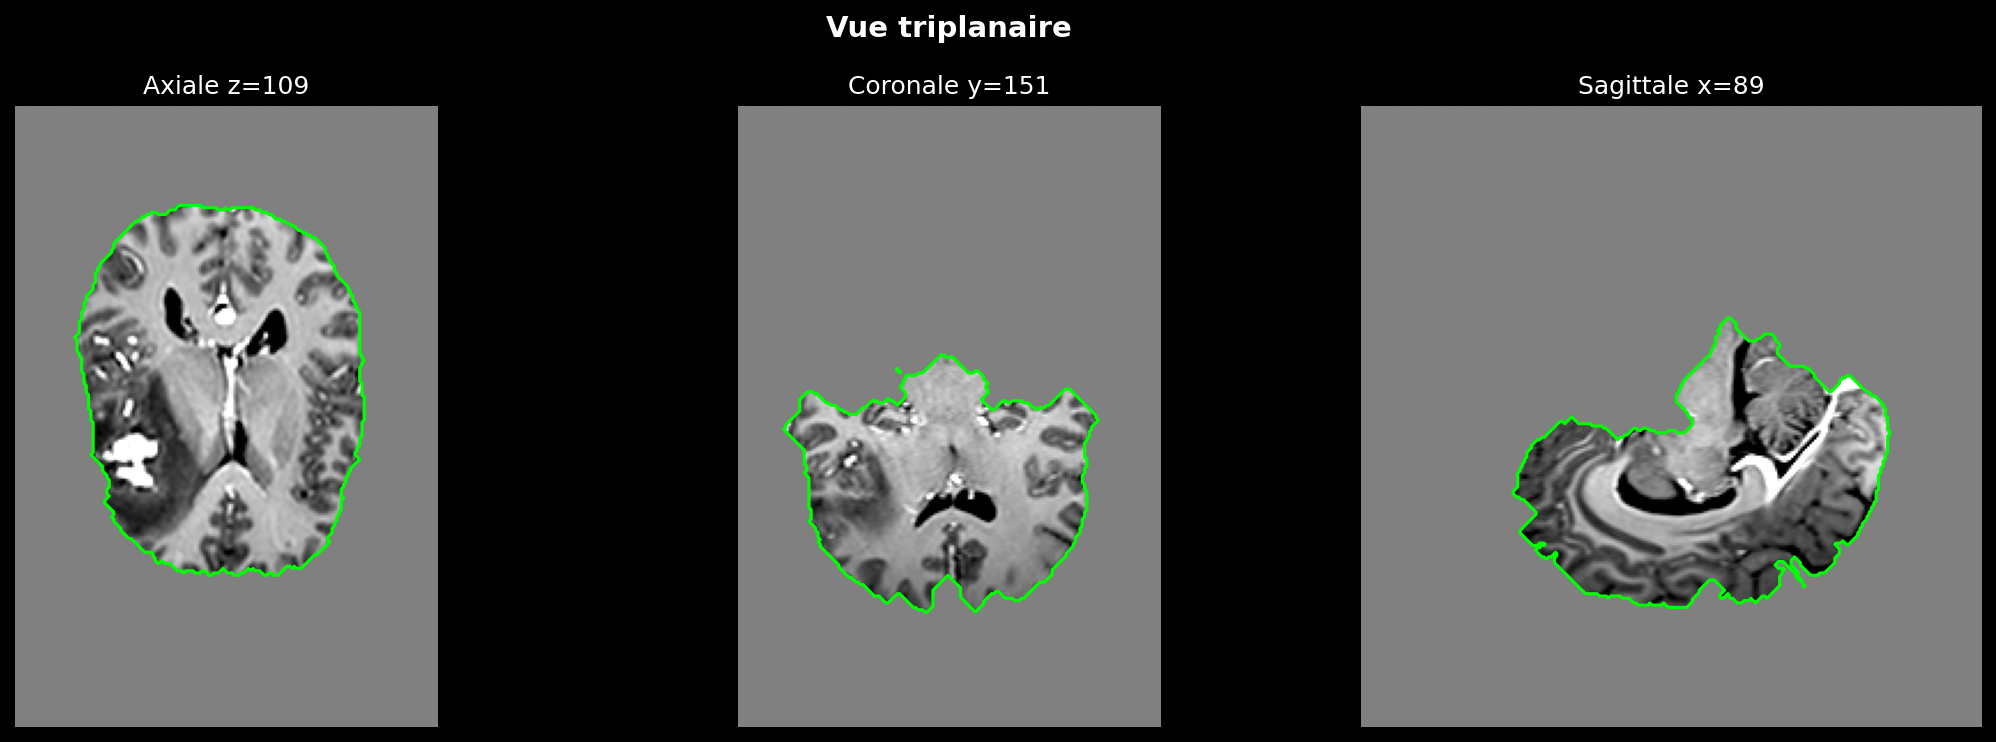


✓ Méthode utilisée : Otsu+morphologie


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELLULE 4 — Vérification visuelle                              ║
# ╚══════════════════════════════════════════════════════════════════╝

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

cm = ndimage.center_of_mass(mask_bool.astype(float))
x_cm, y_cm, z_cm = int(cm[0]), int(cm[1]), int(cm[2])
t1_raw = t1_n4.numpy()
n_z    = t1_norm.shape[2]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('black')
fig.suptitle(f'Skull stripping — {method_used}',
             fontsize=14, fontweight='bold', color='white')

for col, z in enumerate([max(0,z_cm-25), z_cm, min(n_z-1,z_cm+25)]):
    axes[0,col].imshow(t1_raw[:,:,z].T, cmap='gray', origin='lower',
                       vmin=np.percentile(t1_raw[t1_raw>0],1),
                       vmax=np.percentile(t1_raw[t1_raw>0],99))
    axes[0,col].set_title(f'Avant  z={z}', color='white')
    axes[0,col].axis('off'); axes[0,col].set_facecolor('black')

    axes[1,col].imshow(t1_norm[:,:,z].T, cmap='gray', origin='lower', vmin=-2, vmax=2)
    axes[1,col].contour(mask_bool[:,:,z].T, levels=[0.5], colors='lime', linewidths=1.5)
    axes[1,col].set_title(f'Après  z={z}', color='white')
    axes[1,col].axis('off'); axes[1,col].set_facecolor('black')

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/verification_axiale.png', dpi=150,
            bbox_inches='tight', facecolor='black')
plt.close()

fig2, axes2 = plt.subplots(1, 3, figsize=(15,5))
fig2.patch.set_facecolor('black')
fig2.suptitle('Vue triplanaire', fontsize=14, fontweight='bold', color='white')
for col,(img,msk,title) in enumerate([
    (t1_norm[:,:,z_cm].T, mask_bool[:,:,z_cm].T, f'Axiale z={z_cm}'),
    (t1_norm[:,y_cm,:].T, mask_bool[:,y_cm,:].T, f'Coronale y={y_cm}'),
    (t1_norm[x_cm,:,:].T, mask_bool[x_cm,:,:].T, f'Sagittale x={x_cm}'),
]):
    axes2[col].imshow(img, cmap='gray', origin='lower', vmin=-2, vmax=2)
    axes2[col].contour(msk, levels=[0.5], colors='lime', linewidths=1.5)
    axes2[col].set_title(title, color='white')
    axes2[col].axis('off'); axes2[col].set_facecolor('black')

plt.tight_layout()
fig2.savefig(f'{OUTPUT_DIR}/verification_triplanaire.png', dpi=150,
             bbox_inches='tight', facecolor='black')
plt.close()

for fname in ['verification_axiale.png','verification_triplanaire.png']:
    print(f"\n── {fname} ──")
    display(IPImage(filename=f'{OUTPUT_DIR}/{fname}'))

print(f"\n✓ Méthode utilisée : {method_used}")

In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip install surfa

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.5/105.5 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for surfa: filename=surfa-0.6.3-cp312-cp312-linux_x86_64.whl size=1562036 sha256=3747a09920b035726a2e76b838aacf4f08d51e65fb6ce07aca1efbeffb28030f
  Stored in directory: /root/.cache/pip/wheels/f4/78/82/bd1ad64cd3b686d6deed09d6d7da94647a3272a7e8af8d8d1b
Successfully built surfa


In [ ]:
!wget https://surfer.nmr.mgh.harvard.edu/docs/synthstrip/model.pt -O model.pt
!wget https://raw.githubusercontent.com/freesurfer/freesurfer/dev/mri_synthstrip/mri_synthstrip -O mri_synthstrip
!chmod +x mri_synthstrip

--2026-06-10 12:36:35--  https://surfer.nmr.mgh.harvard.edu/docs/synthstrip/model.pt
Resolving surfer.nmr.mgh.harvard.edu (surfer.nmr.mgh.harvard.edu)... 132.183.1.43
Connecting to surfer.nmr.mgh.harvard.edu (surfer.nmr.mgh.harvard.edu)|132.183.1.43|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-06-10 12:36:36 ERROR 404: Not Found.

--2026-06-10 12:36:36--  https://raw.githubusercontent.com/freesurfer/freesurfer/dev/mri_synthstrip/mri_synthstrip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11148 (11K) [text/plain]
Saving to: ‘mri_synthstrip’

mri_synthstrip      100%[===================>]  10.89K  --.-KB/s    in 0s      

2026-06-10 12:36:36 (66.8 MB/s) - ‘mri_synthstrip’ saved [11148/11148]



In [ ]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    !pip install hd-bet --force-reinstall --no-deps --upgrade

  Using cached hd_bet-2.0.1-py3-none-any.whl
  Attempting uninstall: hd-bet
    Found existing installation: HD_BET 2.0.1
    Uninstalling HD_BET-2.0.1:
      Successfully uninstalled HD_BET-2.0.1


In [ ]:
tmp_input = "/tmp/t1_n4.nii.gz"
ants.image_write(t1_n4, tmp_input)

In [ ]:
print(volume_np.shape)
print(spacing)

(256, 256, 160)
(1.05469, 1.05469, 1.15)


In [ ]:
print(volume_np.shape)
print(spacing)
print(t1_ras.shape)
print(t1_ras.spacing)

(256, 256, 160)
(1.05469, 1.05469, 1.15)
(256, 256, 160)
(1.05469, 1.05469, 1.15)


In [ ]:
!pip install antspyx nibabel scipy matplotlib

In [ ]:
!git clone https://github.com/freesurfer/freesurfer.git /content/freesurfer
!wget -O synthstrip_model.pt https://surfer.nmr.mgh.harvard.edu/pub/dist/freesurfer/7.4.1/synthstrip_model.pt

fatal: destination path '/content/freesurfer' already exists and is not an empty directory.
--2026-06-10 13:53:36--  https://surfer.nmr.mgh.harvard.edu/pub/dist/freesurfer/7.3.0/synthstrip_model.pt
Resolving surfer.nmr.mgh.harvard.edu (surfer.nmr.mgh.harvard.edu)... 132.183.1.43
Connecting to surfer.nmr.mgh.harvard.edu (surfer.nmr.mgh.harvard.edu)|132.183.1.43|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-06-10 13:53:36 ERROR 404: Not Found.



In [ ]:
!pip install hd-bet

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [ ]:
print(result.stderr)

/usr/bin/python3: can't find '__main__' module in '/content/freesurfer/mri_synthstrip'



In [ ]:
!python freesurfer/mri_synthstrip -h

/usr/bin/python3: can't find '__main__' module in '/content/freesurfer/mri_synthstrip'


In [ ]:
!python freesurfer/mri_synthstrip \
-i /tmp/t1_n4.nii.gz \
-o /tmp/t1_brain.nii.gz \
-m /tmp/t1_mask.nii.gz

/usr/bin/python3: can't find '__main__' module in '/content/freesurfer/mri_synthstrip'


In [ ]:
!pip install hd-bet

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [ ]:
import HD_BET

print("HD-BET importé correctement")

ModuleNotFoundError: No module named 'hd_bet'

In [ ]:
!pip install matplotlib-venn
!apt-get -qq install -y libfluidsynth1
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot
!pip install cartopy
import cartopy

E: Package 'libfluidsynth1' has no installation candidate


In [ ]:
!pip show hd-bet
!which hd-bet

Name: HD_BET
Version: 2.0.1
Summary: Tool for brain extraction
Home-page: https://github.com/MIC-DKFZ/hd-bet
Author: 
Author-email: Fabian Isensee <f.isensee@dkfz.de>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: nnunetv2, numpy, scikit-image, SimpleITK, torch
Required-by: 
/usr/local/bin/hd-bet


In [ ]:
from HD_BET.run import run_hd_bet
print("HD-BET OK")

ModuleNotFoundError: No module named 'hd_bet'

In [ ]:
!hd-bet -h


########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

usage: hd-bet [-h] -i INPUT [-o OUTPUT] [-device DEVICE] [--disable_tta]
              [--save_bet_mask] [--no_bet_image] [--verbose]

options:
  -h, --help            show this help message and exit
  -i INPUT, --input INPUT
                        input. Can be either a single file name or an input
                        folder. If file: must be nifti (.nii.gz) and can only
                        

In [ ]:
import ants
import nibabel as nib
import numpy as np
import os
from HD_BET.run import run_hd_bet

OUTPUT_DIR = "/content/drive/MyDrive/DICOM_preprocessed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*60)
print("PREPROCESSING CLINIQUE AVEC HD-BET")
print("="*60)

# =====================================================
# 1. Création image ANTs
# =====================================================

t1 = ants.from_numpy(
    volume_np.astype(np.float32),
    spacing=list(spacing),
    origin=[0,0,0],
    direction=np.eye(3).tolist()
)

# =====================================================
# 2. Orientation RAS
# =====================================================

print("\n[1/6] Orientation RAS")

t1_ras = ants.reorient_image2(
    t1,
    orientation='RAS'
)

# =====================================================
# 3. N4 Bias Correction
# =====================================================

print("\n[2/6] N4 Bias Correction")

t1_n4 = ants.n4_bias_field_correction(
    t1_ras,
    shrink_factor=2,
    convergence={
        'iters':[50,50,50,50],
        'tol':1e-7
    }
)

# =====================================================
# 4. Sauvegarde temporaire
# =====================================================

tmp_input = "/tmp/t1_n4.nii.gz"

ants.image_write(
    t1_n4,
    tmp_input
)

# =====================================================
# 5. HD-BET
# =====================================================

print("\n[3/6] HD-BET")

output_folder = "/tmp/hd_bet"

run_hd_bet(
    tmp_input,
    output_folder,
    mode="fast",
    device="cpu"
)

mask_file = "/tmp/hd_bet/t1_n4_bet_mask.nii.gz"
brain_file = "/tmp/hd_bet/t1_n4_bet.nii.gz"

# =====================================================
# 6. Chargement masque
# =====================================================

mask = nib.load(mask_file).get_fdata()

mask = (mask > 0.5)

brain_fraction = mask.mean()

print(
    f"Fraction cerveau = {brain_fraction:.3f}"
)

if brain_fraction < 0.05:
    raise ValueError(
        "Masque trop petit"
    )

if brain_fraction > 0.40:
    raise ValueError(
        "Masque trop grand"
    )

# =====================================================
# 7. Chargement cerveau extrait
# =====================================================

brain_np = nib.load(
    brain_file
).get_fdata().astype(np.float32)

# =====================================================
# 8. Resampling 1mm
# =====================================================

print("\n[4/6] Resampling")

brain_img = ants.from_numpy(
    brain_np,
    spacing=t1_ras.spacing,
    origin=t1_ras.origin,
    direction=t1_ras.direction
)

brain_res = ants.resample_image(
    brain_img,
    (1,1,1),
    use_voxels=False,
    interp_type=4
)

brain_np = brain_res.numpy()

# =====================================================
# 9. Z-score
# =====================================================

print("\n[5/6] Z-score")

mask_res = brain_np > 0

vals = brain_np[mask_res]

brain_np[mask_res] = (
    vals - vals.mean()
) / (
    vals.std() + 1e-8
)

print(
    f"mean={brain_np[mask_res].mean():.4f}"
)

print(
    f"std={brain_np[mask_res].std():.4f}"
)

# =====================================================
# 10. Sauvegarde
# =====================================================

final_img = brain_res.new_image_like(
    brain_np
)

out_path = os.path.join(
    OUTPUT_DIR,
    "clinical_t1_preprocessed.nii.gz"
)

ants.image_write(
    final_img,
    out_path
)

print("\n[6/6] Sauvegarde")

print(out_path)

ModuleNotFoundError: No module named 'hd_bet'